# Подготовка и анализ результатов исследования алгоритмов поиска пути на плоскости с круговыми препятствиями

Дополнение к дипломной работе "Структурные и геометрические параметры среды в алгоритмах поиска пути на плоскости с круговыми препятствиями" студента Павлючика Антона Михайловича.

Ноутбук последовательно проходит путь от загрузки экспериментальных файлов до статистического анализа, визуализаций и модели выбора предпочтительного алгоритма по характеристикам сцены.

## 1. Настройка окружения

Подключаются библиотеки, определяется корень проекта и загружается parser экспериментальных данных.

In [ ]:
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path
from IPython.display import display
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'src').is_dir() and (candidate / 'python').is_dir():
            return candidate
    raise FileNotFoundError("Could not find project root containing 'src' and 'python' directories.")


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / 'src'
NOTEBOOK_DIR = PROJECT_ROOT / 'python'

In [2]:
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from tools import experiment_dataset_parser as experiment_dataset_parser
experiment_dataset_parser = importlib.reload(experiment_dataset_parser)
save_dataset_bundle = experiment_dataset_parser.save_dataset_bundle
build_experiment_dataset = experiment_dataset_parser.build_experiment_dataset
build_analysis_run_dataset = experiment_dataset_parser.build_analysis_run_dataset
load_or_build_experiment_dataset = experiment_dataset_parser.load_or_build_experiment_dataset

## 2. Загрузка экспериментального набора

Данные берутся из финальной серии экспериментов, при наличии актуального кэша используется сохраненная версия датасета.

In [3]:
EXPERIMENTS_DIR = SRC_DIR / 'configs' / 'studies' / 'final_53' / 'experiment_runs'
OUTPUT_DIR = NOTEBOOK_DIR / 'analysis_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATASET_PREFIX = 'final53'
FORCE_REBUILD = False

In [4]:
bundle, bundle_cache_info = load_or_build_experiment_dataset(
    EXPERIMENTS_DIR,
    OUTPUT_DIR,
    prefix=DATASET_PREFIX,
    force_rebuild=FORCE_REBUILD,
)
saved_paths = dict(bundle_cache_info.get('saved_paths', {}))

analysis_run_df = getattr(bundle, 'analysis_run_df', None)
if analysis_run_df is None or analysis_run_df.empty:
    analysis_run_df = build_analysis_run_dataset(bundle.run_df)

summary = dict(getattr(bundle, 'summary', {}))
summary.setdefault('analysis_run_row_count', int(len(analysis_run_df)))
summary.setdefault('executed_run_count', int(bundle.run_df['algorithm_was_executed'].fillna(False).sum()))
summary.setdefault('not_run_count', int((bundle.run_df['algorithm_status'] == 'NotRun').sum()))
summary.setdefault('scene_row_count', int(len(bundle.scene_df)))

42400

In [5]:
summary_df = pd.DataFrame([summary])

cache_status_df = pd.DataFrame([
    {
        'dataset_source': bundle_cache_info.get('mode', ''),
        'cache_available': bool(bundle_cache_info.get('cache_available', False)),
        'cache_is_fresh': bool(bundle_cache_info.get('is_fresh', False)),
        'force_rebuild': FORCE_REBUILD,
        'cache_note': bundle_cache_info.get('reason', ''),
    }
])

display(cache_status_df)
display(summary_df)
display(bundle.file_df.head())

,dataset_source,cache_available,cache_is_fresh,force_rebuild,cache_note
0,rebuilt,True,True,False,


,experiment_file_count,run_row_count,analysis_run_row_count,scene_row_count,theoretical_max_run_rows,actual_run_rows,executed_run_count,not_run_count,generated_scene_count,completed_scene_count,path_found_run_count,failed_run_count,graph_timed_run_count
0,53,212000,212000,42400,212000,212000,211685,315,42337,42337,202284,0,169348


,experiment_file,experiment_path,config_index,experiment_name,config_name,experiment_status,scene_count_declared,actual_scene_rows,generated_scene_count,completed_scene_count,any_path_scene_count,enabled_algorithm_count,theoretical_max_run_rows,actual_run_rows,executed_run_count,not_run_count,path_found_run_count,failed_run_count,graph_timed_run_count
0,01_compact_uniform_micro_open_experiment.json,Q:\Diploma\src\configs\studies\final_53\experi...,1,final53_compact_uniform_micro_open,final53_compact_uniform_micro_open,Completed,800,800,800,800,800,5,4000,4000,4000,0,4000,0,3200
1,02_compact_uniform_micro_balanced_dense_experi...,Q:\Diploma\src\configs\studies\final_53\experi...,2,final53_compact_uniform_micro_balanced_dense,final53_compact_uniform_micro_balanced_dense,Completed,800,800,800,800,800,5,4000,4000,4000,0,4000,0,3200
2,03_compact_uniform_dense_wide_radii_experiment...,Q:\Diploma\src\configs\studies\final_53\experi...,3,final53_compact_uniform_dense_wide_radii,final53_compact_uniform_dense_wide_radii,Completed,800,800,800,800,800,5,4000,4000,4000,0,4000,0,3200
3,04_compact_mixed_scale_patchy_large_experiment...,Q:\Diploma\src\configs\studies\final_53\experi...,4,final53_compact_mixed_scale_patchy_large,final53_compact_mixed_scale_patchy_large,Completed,800,800,800,800,800,5,4000,4000,4000,0,4000,0,3200
4,05_medium_large_disks_sparse_plus_experiment.json,Q:\Diploma\src\configs\studies\final_53\experi...,5,final53_medium_large_disks_sparse_plus,final53_medium_large_disks_sparse_plus,Completed,800,800,800,800,800,5,4000,4000,4000,0,4000,0,3200


Данные экспериментов загружены. Далее фиксируются объем выборки, источник данных и назначение основных промежуточных таблиц.

In [6]:
print('Строк-слотов алгоритмов:', bundle.summary['analysis_run_row_count'])
print('Выполненных запусков:', bundle.summary['executed_run_count'])
print('NotRun-слотов:', bundle.summary['not_run_count'])
print('Строк сцен:', bundle.summary['scene_row_count'])

print('Источник набора:', bundle_cache_info.get('mode', ''))
if bundle_cache_info.get('reason'):
    print('Комментарий к кэшу:', bundle_cache_info['reason'])

Строк-слотов алгоритмов: 212000
Выполненных запусков: 211685
NotRun-слотов: 315
Строк сцен: 42400
Источник набора: rebuilt


    Эта сводка нужна как первичная проверка того, что финальный набор данных собран корректно. На этом этапе важно убедиться, что число сцен, число выполненных запусков и объем run-level таблицы согласуются между собой и не указывают на потери данных при загрузке.
    


### Карта промежуточных таблиц

Эта таблица фиксирует назначение основных датасетов, чтобы дальше было понятно, на каком уровне агрегации выполняется анализ.

In [7]:
dataset_map_df = pd.DataFrame([
    {
        'dataset': 'raw_experiment_json',
        'granularity': '1 file = 1 конфиг + все сцены и все запуски внутри',
        'location': str(EXPERIMENTS_DIR),
        'purpose': 'источник истины: полная геометрия scene_data, препятствия, runs',
    },
    {
        'dataset': 'bundle.run_df',
        'granularity': '1 row = 1 запуск алгоритма на 1 сцене',
        'location': saved_paths.get('runs', ''),
        'purpose': 'сырой run-level extract из experiment json',
    },
    {
        'dataset': 'analysis_run_df',
        'granularity': '1 row = 1 запуск алгоритма на 1 сцене',
        'location': saved_paths.get('runs_analysis', ''),
        'purpose': 'основной run-level датасет для анализа алгоритмов',
    },
    {
        'dataset': 'bundle.scene_df',
        'granularity': '1 row = 1 сцена',
        'location': saved_paths.get('scenes', ''),
        'purpose': 'scene-level summary и метрики сцены без дублирования по алгоритмам',
    },
    {
        'dataset': 'bundle.file_df',
        'granularity': '1 row = 1 experiment file / config',
        'location': saved_paths.get('files', ''),
        'purpose': 'агрегаты по конфигам и контроль полноты эксперимента',
    },
    {
        'dataset': 'analysis_compact_df',
        'granularity': '1 row = 1 запуск алгоритма на 1 сцене',
        'location': str(OUTPUT_DIR / f'{DATASET_PREFIX}_runs_compact.parquet'),
        'purpose': 'компактная выборка основных колонок; создается позже в ноутбуке',
    },
    {
        'dataset': 'scene_analysis_df',
        'granularity': '1 row = 1 успешно сгенерированная сцена',
        'location': str(OUTPUT_DIR / f'{DATASET_PREFIX}_scene_analysis.parquet'),
        'purpose': 'scene-level срез для анализа вариативности и связей метрик среды',
    },
])

In [8]:
with pd.option_context('display.max_columns', None, 'display.width', 2400, 'display.max_colwidth', 160):
    display(dataset_map_df)

saved_paths

,dataset,granularity,location,purpose
0,raw_experiment_json,1 file = 1 конфиг + все сцены и все запуски внутри,Q:\Diploma\src\configs\studies\final_53\experiment_runs,"источник истины: полная геометрия scene_data, препятствия, runs"
1,bundle.run_df,1 row = 1 запуск алгоритма на 1 сцене,Q:\Diploma\python\analysis_outputs\final53_runs.parquet,сырой run-level extract из experiment json
2,analysis_run_df,1 row = 1 запуск алгоритма на 1 сцене,Q:\Diploma\python\analysis_outputs\final53_runs_analysis.parquet,основной run-level датасет для анализа алгоритмов
3,bundle.scene_df,1 row = 1 сцена,Q:\Diploma\python\analysis_outputs\final53_scenes.parquet,scene-level summary и метрики сцены без дублирования по алгоритмам
4,bundle.file_df,1 row = 1 experiment file / config,Q:\Diploma\python\analysis_outputs\final53_files.parquet,агрегаты по конфигам и контроль полноты эксперимента
5,analysis_compact_df,1 row = 1 запуск алгоритма на 1 сцене,Q:\Diploma\python\analysis_outputs\final53_runs_compact.parquet,компактная выборка основных колонок; создается позже в ноутбуке
6,scene_analysis_df,1 row = 1 успешно сгенерированная сцена,Q:\Diploma\python\analysis_outputs\final53_scene_analysis.parquet,scene-level срез для анализа вариативности и связей метрик среды


{'runs': 'Q:\\Diploma\\python\\analysis_outputs\\final53_runs.parquet',
 'runs_analysis': 'Q:\\Diploma\\python\\analysis_outputs\\final53_runs_analysis.parquet',
 'scenes': 'Q:\\Diploma\\python\\analysis_outputs\\final53_scenes.parquet',
 'files': 'Q:\\Diploma\\python\\analysis_outputs\\final53_files.parquet',
 'summary': 'Q:\\Diploma\\python\\analysis_outputs\\final53_summary.json'}

### Мастер-представление запусков

Формируется рабочий срез run-level данных: одна строка соответствует запуску конкретного алгоритма на конкретной сцене.

In [9]:
HEAD_COLUMNS = [
    'config_index',
    'config_name',
    'scene_id',
    'scene_index',
    'scene_seed',
    'scene_generation_status',
    'scene_run_status',
    'scene_width',
    'scene_height',
    'scene_obstacle_count',
    'scene_direct_distance',
    'algorithm_id',
    'algorithm_status',
    'algorithm_was_executed',
    'path_found',
    'runtime_ms',
    'path_length',
    'relative_path_length',
    'scene_metric_obstacle_area_ratio',
    'scene_metric_boundary_density',
    'scene_metric_cell_density_cv',
    'scene_metric_radii_cv',
    'scene_metric_clearance',
    'scene_metric_largest_component_ratio',
    'algorithm_params_json',
]

In [10]:
missing_columns = [column for column in HEAD_COLUMNS if column not in analysis_run_df.columns]
if missing_columns:
    raise KeyError(f'Missing columns in analysis_run_df: {missing_columns}')

analysis_view_df = analysis_run_df[HEAD_COLUMNS].copy()
analysis_view_df.shape

(212000, 25)

In [11]:
display(analysis_view_df.head(15))

,config_index,config_name,scene_id,scene_index,scene_seed,scene_generation_status,scene_run_status,scene_width,scene_height,scene_obstacle_count,...,runtime_ms,path_length,relative_path_length,scene_metric_obstacle_area_ratio,scene_metric_boundary_density,scene_metric_cell_density_cv,scene_metric_radii_cv,scene_metric_clearance,scene_metric_largest_component_ratio,algorithm_params_json
0,1,final53_compact_uniform_micro_open,scene_1,1,92501,Generated,Completed,90.0,90.0,46,...,0.6468,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0,"{""allow_diagonal"": true, ""grid_step"": 3.5, ""us..."
1,1,final53_compact_uniform_micro_open,scene_1,1,92501,Generated,Completed,90.0,90.0,46,...,0.5843,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0,"{""allow_diagonal"": true, ""grid_step"": 3.5, ""us..."
2,1,final53_compact_uniform_micro_open,scene_1,1,92501,Generated,Completed,90.0,90.0,46,...,0.0034,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0,"{""enable_path_smoothing"": true, ""goal_sample_r..."
3,1,final53_compact_uniform_micro_open,scene_1,1,92501,Generated,Completed,90.0,90.0,46,...,19.5119,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0,"{""points_per_obstacle"": 16}"
4,1,final53_compact_uniform_micro_open,scene_1,1,92501,Generated,Completed,90.0,90.0,46,...,23.2532,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0,"{""points_per_obstacle"": 16}"
5,1,final53_compact_uniform_micro_open,scene_2,2,92502,Generated,Completed,90.0,90.0,44,...,0.6092,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0,"{""allow_diagonal"": true, ""grid_step"": 3.5, ""us..."
6,1,final53_compact_uniform_micro_open,scene_2,2,92502,Generated,Completed,90.0,90.0,44,...,0.6856,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0,"{""allow_diagonal"": true, ""grid_step"": 3.5, ""us..."
7,1,final53_compact_uniform_micro_open,scene_2,2,92502,Generated,Completed,90.0,90.0,44,...,0.0031,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0,"{""enable_path_smoothing"": true, ""goal_sample_r..."
8,1,final53_compact_uniform_micro_open,scene_2,2,92502,Generated,Completed,90.0,90.0,44,...,17.7058,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0,"{""points_per_obstacle"": 16}"
9,1,final53_compact_uniform_micro_open,scene_2,2,92502,Generated,Completed,90.0,90.0,44,...,18.0188,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0,"{""points_per_obstacle"": 16}"


    Предпросмотр подтверждает, что одна строка действительно соответствует одному запуску алгоритма на одной сцене. В таком виде данные уже пригодны для последующих агрегаций по алгоритмам, сценам и конфигурациям.
    


Компактная выборка сохраняет только колонки, которые нужны для основного анализа. Это делает дальнейшие таблицы и графики проще для проверки.

## Выборка данных

Ниже формируется отдельный компактный датасет по выбранным колонкам. Он сохраняется в `analysis_outputs` и используется как удобная основа для дальнейшего анализа.

In [12]:
COMPACT_ANALYSIS_COLUMNS = [
    'scene_generation_status',
    'scene_run_status',
    'scene_direct_distance',
    'algorithm_id',
    'algorithm_status',
    'algorithm_was_executed',
    'path_found',
    'runtime_ms',
    'path_length',
    'relative_path_length',
    'scene_metric_obstacle_area_ratio',
    'scene_metric_boundary_density',
    'scene_metric_cell_density_cv',
    'scene_metric_radii_cv',
    'scene_metric_clearance',
    'scene_metric_largest_component_ratio',
]

missing_compact_columns = [
    column for column in COMPACT_ANALYSIS_COLUMNS if column not in analysis_run_df.columns
]
if missing_compact_columns:
    raise KeyError(f'Missing columns in analysis_run_df: {missing_compact_columns}')

In [13]:
analysis_compact_df = analysis_run_df[COMPACT_ANALYSIS_COLUMNS].copy()
compact_output_path = OUTPUT_DIR / f'{DATASET_PREFIX}_runs_compact.parquet'
analysis_compact_df.to_parquet(compact_output_path, index=False)

print('Compact dataset rows:', len(analysis_compact_df))
print('Compact dataset columns:', len(analysis_compact_df.columns))
print(f'Saved to: {compact_output_path}')

analysis_compact_df.shape

Compact dataset rows: 212000
Compact dataset columns: 16
Saved to: Q:\Diploma\python\analysis_outputs\final53_runs_compact.parquet


(212000, 16)

In [14]:
with pd.option_context('display.max_columns', None, 'display.width', 2000, 'display.max_colwidth', 200):
    display(analysis_compact_df.head(15))

,scene_generation_status,scene_run_status,scene_direct_distance,algorithm_id,algorithm_status,algorithm_was_executed,path_found,runtime_ms,path_length,relative_path_length,scene_metric_obstacle_area_ratio,scene_metric_boundary_density,scene_metric_cell_density_cv,scene_metric_radii_cv,scene_metric_clearance,scene_metric_largest_component_ratio
0,Generated,Completed,68.126456,grid_astar,Success,True,True,0.6468,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0
1,Generated,Completed,68.126456,grid_dijkstra,Success,True,True,0.5843,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0
2,Generated,Completed,68.126456,rrt,Success,True,True,0.0034,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0
3,Generated,Completed,68.126456,visibility_astar,Success,True,True,19.5119,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0
4,Generated,Completed,68.126456,visibility_dijkstra,Success,True,True,23.2532,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0
5,Generated,Completed,91.411125,grid_astar,Success,True,True,0.6092,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0
6,Generated,Completed,91.411125,grid_dijkstra,Success,True,True,0.6856,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0
7,Generated,Completed,91.411125,rrt,Success,True,True,0.0031,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0
8,Generated,Completed,91.411125,visibility_astar,Success,True,True,17.7058,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0
9,Generated,Completed,91.411125,visibility_dijkstra,Success,True,True,18.0188,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0


    Компактная выборка полезна как рабочая версия датасета для таблиц и быстрых проверок. Она сохраняет содержательно важные признаки и результаты, но избавляет ноутбук от лишнего технического шума.
    


## Интерпретация метрик пути

path_length - абсолютная длина найденного пути в координатах сцены.

relative_path_length - отношение длины найденного пути к прямому расстоянию между стартом и целью: path_length / direct_distance(start, goal).

Значение около 1 соответствует почти прямому маршруту. Чем показатель выше, тем сильнее алгоритм вынужден обходить препятствия.

## Вариативность метрик среды

Для анализа разнообразия сред целесообразно перейти к представлению **одна строка = одна сцена**, чтобы не дублировать метрики по всем алгоритмам. Ниже строится отдельный scene-level срез только для успешно сгенерированных сцен.

Также расчитаем характеристики и распределения метрик сцен, чтобы оценить уровень покрытия различных ситуаций для тестов алгоритмов.

In [15]:
SCENE_METRIC_COLUMNS = [
    'scene_metric_boundary_density',
    'scene_metric_cell_density_cv',
    'scene_metric_clearance',
    'scene_metric_largest_component_ratio',
    'scene_metric_obstacle_area_ratio',
    'scene_metric_radii_cv',
]

SCENE_METRIC_LABELS = {
    'scene_metric_boundary_density': 'boundary density',
    'scene_metric_cell_density_cv': 'cell density CV',
    'scene_metric_clearance': 'clearance',
    'scene_metric_largest_component_ratio': 'largest component ratio',
    'scene_metric_obstacle_area_ratio': 'obstacle area ratio',
    'scene_metric_radii_cv': 'radii CV',
}

SCENE_METRIC_DISPLAY_NAMES = [SCENE_METRIC_LABELS[c] for c in SCENE_METRIC_COLUMNS]

SCENE_ANALYSIS_COLUMNS = [
    'config_index',
    'config_name',
    'scene_id',
    'scene_width',
    'scene_height',
    'scene_area',
    'scene_obstacle_count',
    'scene_direct_distance',
    *SCENE_METRIC_COLUMNS,
]

In [16]:
scene_analysis_df = bundle.scene_df.loc[
    bundle.scene_df['scene_is_generated'].fillna(False),
    SCENE_ANALYSIS_COLUMNS,
].copy()
scene_analysis_df = scene_analysis_df.sort_values(['config_index', 'scene_id']).reset_index(drop=True)

scene_analysis_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_analysis.parquet'
scene_analysis_df.to_parquet(scene_analysis_path, index=False)

variability_summary_df = pd.DataFrame({
    'metric': [SCENE_METRIC_LABELS[c] for c in SCENE_METRIC_COLUMNS],
    'metric_id': SCENE_METRIC_COLUMNS,
    'min': [scene_analysis_df[c].min() for c in SCENE_METRIC_COLUMNS],
    'p05': [scene_analysis_df[c].quantile(0.05) for c in SCENE_METRIC_COLUMNS],
    'median': [scene_analysis_df[c].median() for c in SCENE_METRIC_COLUMNS],
    'p95': [scene_analysis_df[c].quantile(0.95) for c in SCENE_METRIC_COLUMNS],
    'max': [scene_analysis_df[c].max() for c in SCENE_METRIC_COLUMNS],
    'std': [scene_analysis_df[c].std() for c in SCENE_METRIC_COLUMNS],
    'n_unique': [scene_analysis_df[c].nunique() for c in SCENE_METRIC_COLUMNS],
    'share_eq_1': [(scene_analysis_df[c] == 1.0).mean() for c in SCENE_METRIC_COLUMNS],
    'share_lt_0_95': [(scene_analysis_df[c] < 0.95).mean() for c in SCENE_METRIC_COLUMNS],
})

In [17]:
variability_summary_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_metric_variability.csv'
variability_summary_df.to_csv(variability_summary_path, index=False)

print('Scene-level dataset rows:', len(scene_analysis_df))
print('Scene-level dataset saved to:', scene_analysis_path)
print('Variability summary saved to:', variability_summary_path)
print('largest_component_ratio == 1 share:', 
      round((scene_analysis_df['scene_metric_largest_component_ratio'] == 1.0).mean(), 4))
print('largest_component_ratio < 0.95 share:', 
      round((scene_analysis_df['scene_metric_largest_component_ratio'] < 0.95).mean(), 4))

with pd.option_context('display.max_columns', None, 'display.width', 2000):
    display(variability_summary_df)

Scene-level dataset rows: 42337
Scene-level dataset saved to: Q:\Diploma\python\analysis_outputs\final53_scene_analysis.parquet
Variability summary saved to: Q:\Diploma\python\analysis_outputs\final53_scene_metric_variability.csv
largest_component_ratio == 1 share: 0.2806
largest_component_ratio < 0.95 share: 0.0456


,metric,metric_id,min,p05,median,p95,max,std,n_unique,share_eq_1,share_lt_0_95
0,boundary density,scene_metric_boundary_density,2.876100e-03,0.007295,0.037545,0.147262,0.236808,0.043097,42287,0.000000,1.000000
1,cell density CV,scene_metric_cell_density_cv,4.027139e-01,0.567605,1.272352,2.162150,3.151623,0.512483,42337,0.000000,0.316839
2,clearance,scene_metric_clearance,3.413086e-01,0.557702,1.928571,6.684581,12.336596,2.016210,26669,0.000850,0.169757
3,largest component ratio,scene_metric_largest_component_ratio,2.437164e-01,0.956706,0.999770,1.000000,1.000000,0.051734,26518,0.280558,0.045610
4,obstacle area ratio,scene_metric_obstacle_area_ratio,1.490000e-02,0.035800,0.161600,0.482300,0.735200,0.149236,5736,0.000000,1.000000
5,radii CV,scene_metric_radii_cv,6.055762e-16,0.172754,0.313335,0.413840,0.550204,0.074521,41539,0.000000,1.000000


    Сводка по вариативности дает количественное основание для дальнейшего анализа. Если бы разброс по ключевым метрикам оказался слишком мал, различия между алгоритмами было бы трудно интерпретировать содержательно.
    


Построим распределения метрик среды, чтобы проверить разнообразие сцен перед анализом алгоритмов.

Saved: Q:\Diploma\python\analysis_outputs\final53_scene_metric_histograms.png


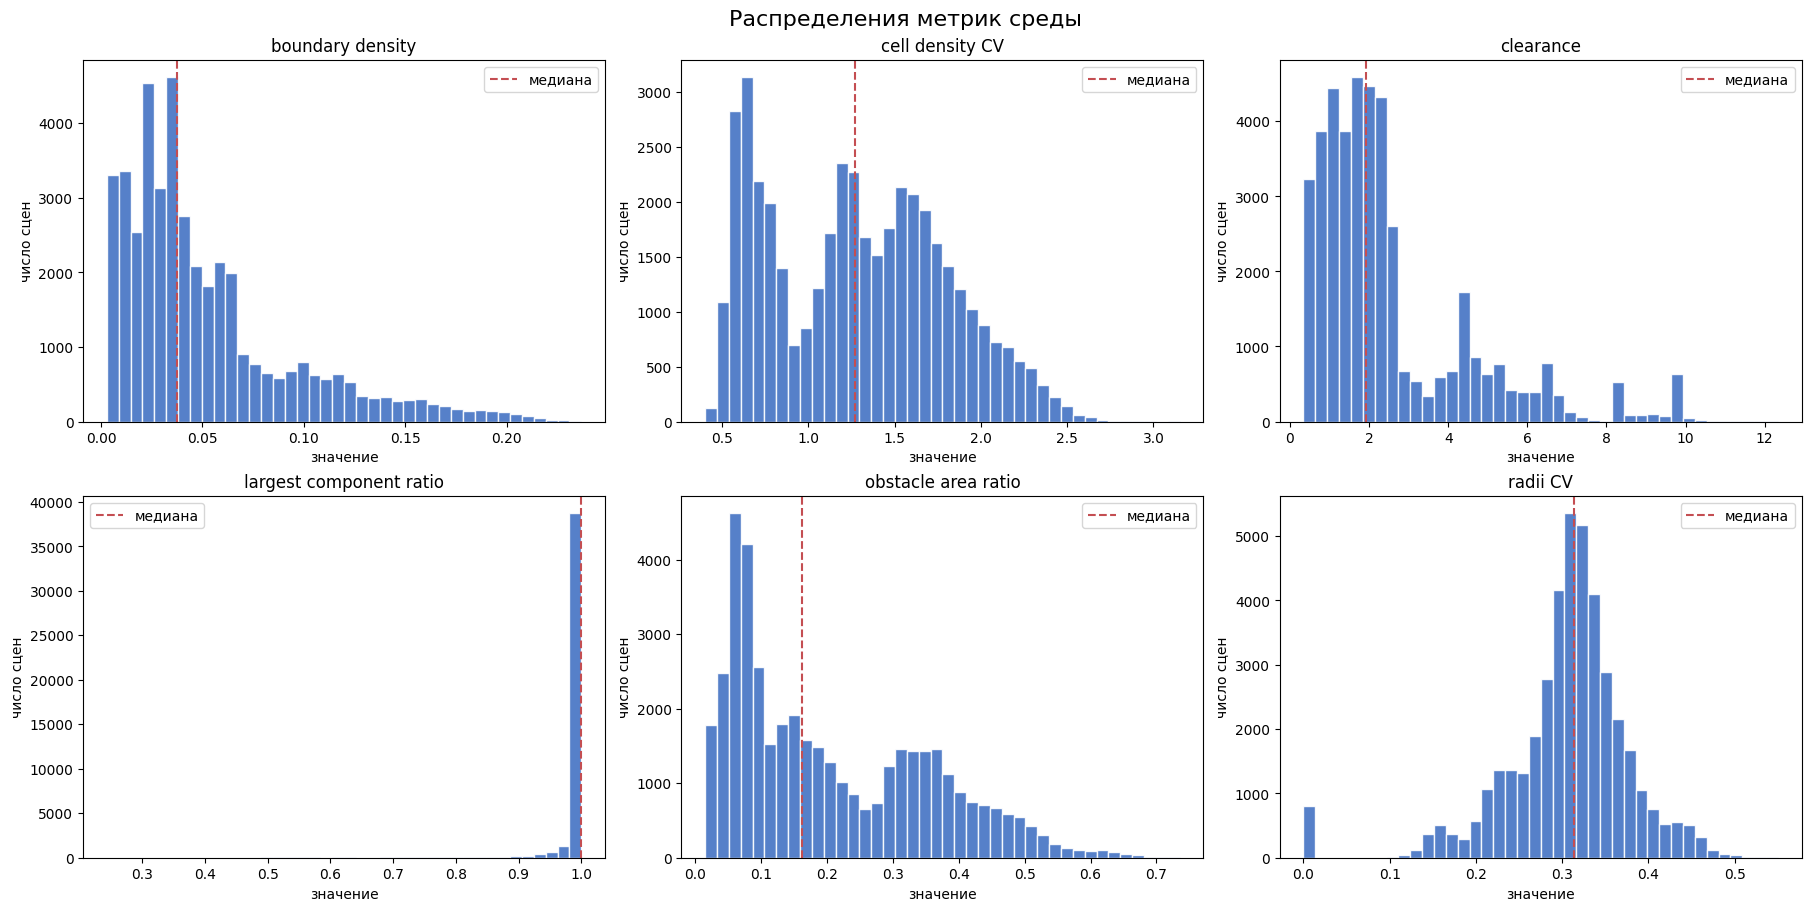

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)
axes = axes.ravel()

for ax, metric in zip(axes, SCENE_METRIC_COLUMNS):
    values = scene_analysis_df[metric]
    ax.hist(values, bins=40, color='#4472c4', edgecolor='white', alpha=0.9)
    ax.axvline(values.median(), color='#c44e52', linestyle='--', linewidth=1.5, label='медиана')
    ax.set_title(SCENE_METRIC_LABELS[metric])
    ax.set_xlabel('значение')
    ax.set_ylabel('число сцен')
    ax.legend(loc='best')

fig.suptitle('Распределения метрик среды', fontsize=16)
metric_hist_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_metric_histograms.png'
fig.savefig(metric_hist_path, dpi=180, bbox_inches='tight')
print('Saved:', metric_hist_path)
plt.show()

Распределения метрик среды в целом выглядят достаточно разнообразными и пригодными для анализа. Они не схлопнулись в константы, а значит сцены действительно различаются по структуре и сложности.

Для boundary_density, cell_density_cv, clearance и obstacle_area_ratio на графиках виден заметный разброс значений, что говорит о наличии в наборе как более простых, так и более сложных конфигураций среды. Это делает метрики содержательно полезными для сопоставления с результатами алгоритмов.

Для largest_component_ratio заметен выраженный пик вблизи 1.0. Это ожидаемо, поскольку значительная часть конфигов всё же ориентирована на проходимые и связные сцены. При этом метрика не вырождается полностью: сохраняется хвост меньших значений, соответствующий более сложным и частично фрагментированным случаям.

Отдельные пики и локальные сгущения на графиках в целом естественны и, вероятно, связаны с тем, что набор состоит из разных семейств конфигов с различной структурой сцен. Иными словами, это отражает не артефакт, а смешение нескольких типов сред в одной экспериментальной базе.

Для radii_cv вариативность выражена слабее, чем у остальных метрик, однако распределение всё равно не сводится к одному значению. В целом полученная картина не идеальна с точки зрения равномерности, но вполне достаточна для дальнейшего содержательного анализа.

## Практически значимые взаимосвязи метрик среды

Для основной части главы удобно показать не все возможные комбинации графиков, а компактный набор визуализаций, которые отвечают на три вопроса:
- действительно ли сцены различаются между собой;
- не сводятся ли метрики к одной и той же оси сложности;
- какие зависимости между показателями среды являются наиболее сильными и содержательно интерпретируемыми.

Ниже сначала рассматриваются несколько репрезентативных пар метрик, а затем анализируется общая корреляционная структура набора.

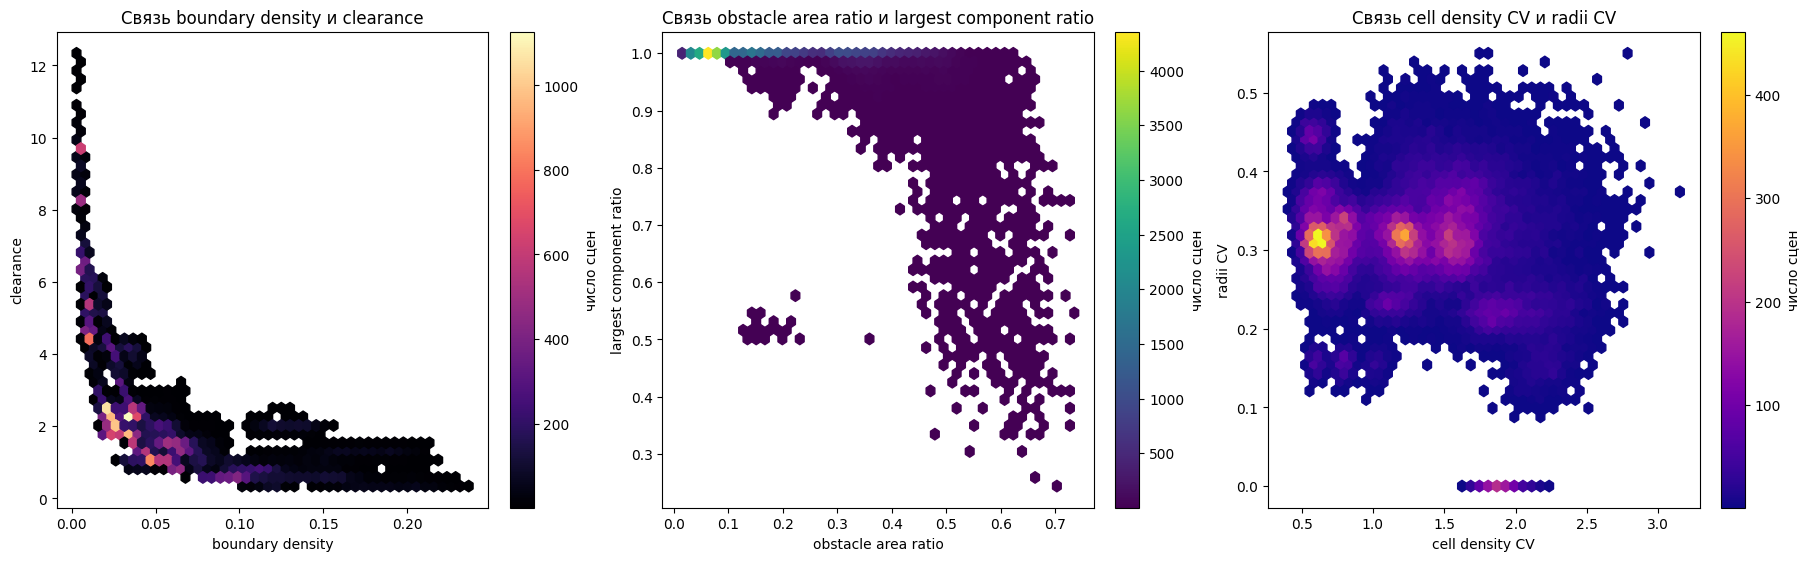

In [19]:
REPRESENTATIVE_PAIR_SPECS = [
    {
        'x': 'scene_metric_boundary_density',
        'y': 'scene_metric_clearance',
        'title': 'Связь boundary density и clearance',
        'cmap': 'magma',
    },
    {
        'x': 'scene_metric_obstacle_area_ratio',
        'y': 'scene_metric_largest_component_ratio',
        'title': 'Связь obstacle area ratio и largest component ratio',
        'cmap': 'viridis',
    },
    {
        'x': 'scene_metric_cell_density_cv',
        'y': 'scene_metric_radii_cv',
        'title': 'Связь cell density CV и radii CV',
        'cmap': 'plasma',
    },
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)

for ax, spec in zip(axes, REPRESENTATIVE_PAIR_SPECS):
    hb = ax.hexbin(
        scene_analysis_df[spec['x']],
        scene_analysis_df[spec['y']],
        gridsize=45,
        cmap=spec['cmap'],
        mincnt=1,
    )
    ax.set_title(spec['title'])
    ax.set_xlabel(SCENE_METRIC_LABELS[spec['x']])
    ax.set_ylabel(SCENE_METRIC_LABELS[spec['y']])
    fig.colorbar(hb, ax=ax, label='число сцен')

In [20]:
fig.suptitle('Репрезентативные попарные связи метрик среды', fontsize=16)
metric_relation_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_metric_relationships.png'
fig.savefig(metric_relation_path, dpi=180, bbox_inches='tight')
print('Saved:', metric_relation_path)
plt.show()

Saved: Q:\Diploma\python\analysis_outputs\final53_scene_metric_relationships.png


Репрезентативные `hexbin`-графики показывают, что наиболее сильные зависимости в наборе метрик являются содержательно интерпретируемыми. Рост `boundary density` сопровождается уменьшением `clearance`, а увеличение `obstacle area ratio` связано со снижением `largest component ratio`, то есть с ухудшением связности свободного пространства.

При этом пара `cell density CV` и `radii CV` демонстрирует существенно более размытое облако значений. Это важно для дипломной интерпретации: часть метрик действительно связана между собой, но набор не схлопывается в одну доминирующую ось сложности.

Для relative_path_length более высокие значения означают менее качественный путь. Поэтому положительные значения на правой heatmap отражают ухудшение качества при переходе к более сложным сценам.

Saved: Q:\Diploma\python\analysis_outputs\final53_config_metric_heatmap.png


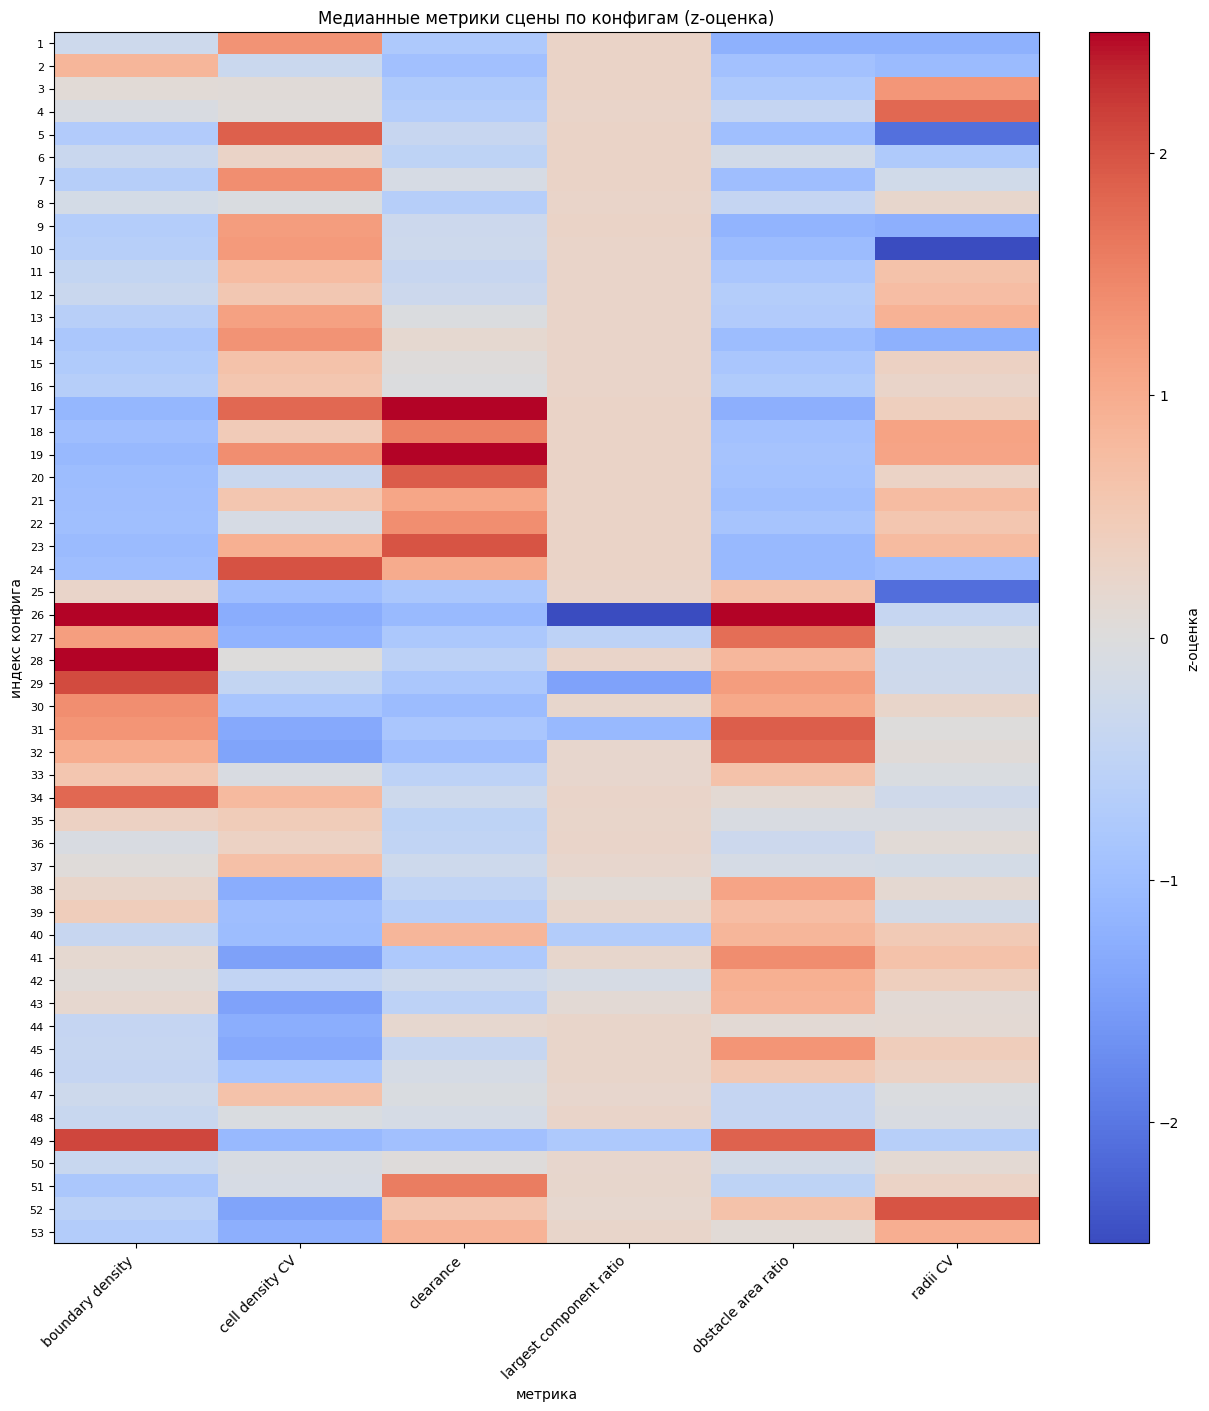

In [21]:
config_metric_median_df = scene_analysis_df.groupby('config_index')[SCENE_METRIC_COLUMNS].median()
config_metric_scaled_df = (
    config_metric_median_df - config_metric_median_df.mean(axis=0)
) / config_metric_median_df.std(axis=0, ddof=0).replace(0.0, 1.0)

fig, ax = plt.subplots(figsize=(12, 14), constrained_layout=True)
image = ax.imshow(config_metric_scaled_df.values, aspect='auto', cmap='coolwarm', vmin=-2.5, vmax=2.5)
ax.set_title('Медианные метрики сцены по конфигам (z-оценка)')
ax.set_xlabel('метрика')
ax.set_ylabel('индекс конфига')
ax.set_xticks(range(len(SCENE_METRIC_COLUMNS)))
ax.set_xticklabels(SCENE_METRIC_DISPLAY_NAMES, rotation=45, ha='right')
ax.set_yticks(range(len(config_metric_scaled_df.index)))
ax.set_yticklabels(config_metric_scaled_df.index.astype(str), fontsize=8)
fig.colorbar(image, ax=ax, label='z-оценка')
config_heatmap_path = OUTPUT_DIR / f'{DATASET_PREFIX}_config_metric_heatmap.png'
fig.savefig(config_heatmap_path, dpi=180, bbox_inches='tight')
print('Saved:', config_heatmap_path)
plt.show()

Конфиги реально различаются между собой, а не повторяют один и тот же сценарий с небольшим шумом. Это важно: поведение алгоритмов оценивается на гетерогенной экспериментальной базе.

## Корреляции метрик среды

Ниже вычисляются попарные корреляции между scene-метриками. Для основной интерпретации используется коэффициент `Spearman`, поскольку он устойчивее отражает монотонные, но не обязательно линейные зависимости.

Коэффициент `Pearson` также сохраняется в отдельный файл и может использоваться как дополнительная проверка линейных связей, однако для основной главы важнее ранжирование пар по `|Spearman|`.

In [22]:
pearson_corr_df = scene_analysis_df[SCENE_METRIC_COLUMNS].corr(method='pearson')
spearman_corr_df = scene_analysis_df[SCENE_METRIC_COLUMNS].corr(method='spearman')

def classify_correlation_strength(abs_value: float) -> str:
    if abs_value >= 0.7:
        return 'strong'
    if abs_value >= 0.5:
        return 'moderate'
    if abs_value >= 0.3:
        return 'weak-to-moderate'
    return 'weak'

correlation_pairs = []
for index, metric_a in enumerate(SCENE_METRIC_COLUMNS):
    for metric_b in SCENE_METRIC_COLUMNS[index + 1:]:
        pearson_value = pearson_corr_df.loc[metric_a, metric_b]
        spearman_value = spearman_corr_df.loc[metric_a, metric_b]
        abs_pearson = abs(pearson_value)
        abs_spearman = abs(spearman_value)
        correlation_pairs.append({
            'metric_a': metric_a,
            'metric_a_label': SCENE_METRIC_LABELS[metric_a],
            'metric_b': metric_b,
            'metric_b_label': SCENE_METRIC_LABELS[metric_b],
            'pair_label': f"{SCENE_METRIC_LABELS[metric_a]} - {SCENE_METRIC_LABELS[metric_b]}",
            'pearson': pearson_value,
            'spearman': spearman_value,
            'abs_pearson': abs_pearson,
            'abs_spearman': abs_spearman,
            'strength_category': classify_correlation_strength(abs_spearman),
        })

correlation_pairs_df = pd.DataFrame(correlation_pairs).sort_values(
    ['abs_spearman', 'abs_pearson'], ascending=False
).reset_index(drop=True)

correlation_strength_summary_df = (
    correlation_pairs_df.groupby('strength_category')
    .agg(
        pair_count=('strength_category', 'size'),
        share_of_pairs=('strength_category', lambda s: len(s) / len(correlation_pairs_df)),
        max_abs_spearman=('abs_spearman', 'max'),
        min_abs_spearman=('abs_spearman', 'min'),
    )
    .reindex(['strong', 'moderate', 'weak-to-moderate', 'weak'])
    .reset_index()
)

top_spearman_pairs_df = correlation_pairs_df[
    ['metric_a_label', 'metric_b_label', 'spearman', 'abs_spearman', 'strength_category']
].head(10).copy()

pearson_corr_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_metric_pearson_corr.csv'
spearman_corr_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_metric_spearman_corr.csv'
correlation_pairs_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_metric_correlation_pairs.csv'
strength_summary_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_metric_correlation_strength_summary.csv'
top_pairs_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_metric_top_spearman_pairs.csv'

pearson_corr_df.to_csv(pearson_corr_path)
spearman_corr_df.to_csv(spearman_corr_path)
correlation_pairs_df.to_csv(correlation_pairs_path, index=False)
correlation_strength_summary_df.to_csv(strength_summary_path, index=False)
top_spearman_pairs_df.to_csv(top_pairs_path, index=False)

print('Saved:', pearson_corr_path)
print('Saved:', spearman_corr_path)
print('Saved:', correlation_pairs_path)
print('Saved:', strength_summary_path)
print('Saved:', top_pairs_path)

with pd.option_context('display.max_columns', None, 'display.width', 2000):
    display(correlation_strength_summary_df)
    display(top_spearman_pairs_df)

Saved: Q:\Diploma\python\analysis_outputs\final53_scene_metric_pearson_corr.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_scene_metric_spearman_corr.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_scene_metric_correlation_pairs.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_scene_metric_correlation_strength_summary.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_scene_metric_top_spearman_pairs.csv


,strength_category,pair_count,share_of_pairs,max_abs_spearman,min_abs_spearman
0,strong,4,0.266667,0.871264,0.764198
1,moderate,4,0.266667,0.693079,0.546790
2,weak-to-moderate,3,0.200000,0.435132,0.330116
3,weak,4,0.266667,0.254472,0.005636


,metric_a_label,metric_b_label,spearman,abs_spearman,strength_category
0,boundary density,clearance,-0.871264,0.871264,strong
1,cell density CV,obstacle area ratio,-0.843637,0.843637,strong
2,largest component ratio,obstacle area ratio,-0.819817,0.819817,strong
3,boundary density,obstacle area ratio,0.764198,0.764198,strong
4,cell density CV,largest component ratio,0.693079,0.693079,moderate
5,boundary density,largest component ratio,-0.596861,0.596861,moderate
6,clearance,obstacle area ratio,-0.571394,0.571394,moderate
7,boundary density,cell density CV,-0.546790,0.546790,moderate
8,cell density CV,clearance,0.435132,0.435132,weak-to-moderate
9,clearance,largest component ratio,0.368380,0.368380,weak-to-moderate


Saved: Q:\Diploma\python\analysis_outputs\final53_scene_metric_correlation_summary.png


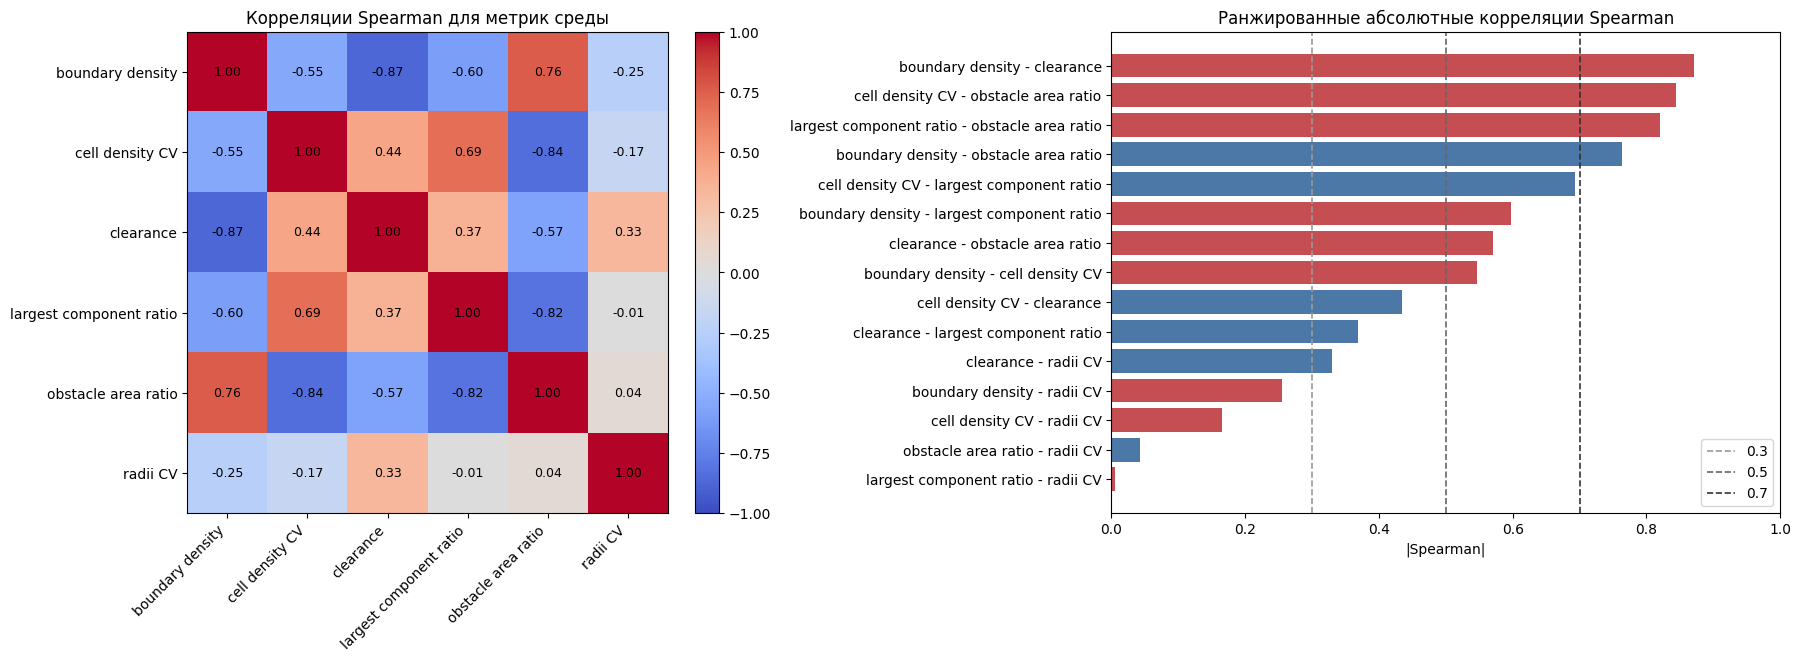

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6.5), constrained_layout=True)

image = axes[0].imshow(spearman_corr_df.values, cmap='coolwarm', vmin=-1.0, vmax=1.0)
axes[0].set_title('Корреляции Spearman для метрик среды')
axes[0].set_xticks(range(len(SCENE_METRIC_COLUMNS)))
axes[0].set_yticks(range(len(SCENE_METRIC_COLUMNS)))
axes[0].set_xticklabels(SCENE_METRIC_DISPLAY_NAMES, rotation=45, ha='right')
axes[0].set_yticklabels(SCENE_METRIC_DISPLAY_NAMES)
for i in range(len(SCENE_METRIC_COLUMNS)):
    for j in range(len(SCENE_METRIC_COLUMNS)):
        axes[0].text(j, i, f'{spearman_corr_df.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9, color='black')
fig.colorbar(image, ax=axes[0], fraction=0.046, pad=0.04)

ranked_pairs_plot_df = correlation_pairs_df.sort_values(['abs_spearman', 'abs_pearson'], ascending=[True, True]).copy()
bar_colors = ['#c44e52' if value < 0 else '#4c78a8' for value in ranked_pairs_plot_df['spearman']]
axes[1].barh(ranked_pairs_plot_df['pair_label'], ranked_pairs_plot_df['abs_spearman'], color=bar_colors)
axes[1].axvline(0.3, color='#999999', linestyle='--', linewidth=1.2, label='0.3')
axes[1].axvline(0.5, color='#666666', linestyle='--', linewidth=1.2, label='0.5')
axes[1].axvline(0.7, color='#333333', linestyle='--', linewidth=1.2, label='0.7')
axes[1].set_title('Ранжированные абсолютные корреляции Spearman')
axes[1].set_xlabel('|Spearman|')
axes[1].set_xlim(0.0, 1.0)
axes[1].legend(loc='lower right')

corr_summary_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_metric_correlation_summary.png'
fig.savefig(corr_summary_path, dpi=180, bbox_inches='tight')
print('Saved:', corr_summary_path)
plt.show()

Корреляционный анализ показывает, что набор метрик среды не является ни полностью независимым, ни полностью вырожденным. Наиболее сильные связи сосредоточены в ограниченном числе пар и в целом соответствуют физическому смыслу показателей: рост плотности и покрытия препятствиями сопровождается уменьшением `clearance` и ухудшением связности свободного пространства.

Одновременно значительная часть пар остаётся в слабой или умеренной зоне по `|Spearman|`. Это означает, что показатели не дублируют друг друга полностью и действительно описывают разные аспекты сцены. Следовательно, использование нескольких метрик одновременно является содержательно оправданным: оно позволяет характеризовать сложность среды многомерно, а не сводить её к одному числу.

In [24]:
strong_pairs_df = correlation_pairs_df.loc[
    correlation_pairs_df['strength_category'] == 'strong',
    ['metric_a_label', 'metric_b_label', 'spearman', 'abs_spearman']
].copy()
moderate_pairs_df = correlation_pairs_df.loc[
    correlation_pairs_df['strength_category'] == 'moderate',
    ['metric_a_label', 'metric_b_label', 'spearman', 'abs_spearman']
].copy()
weak_pairs_df = correlation_pairs_df.loc[
    correlation_pairs_df['strength_category'] == 'weak',
    ['metric_a_label', 'metric_b_label', 'spearman', 'abs_spearman']
].copy().head(5)

print('Correlation strength summary:')
display(correlation_strength_summary_df)

print('Strong pairs (|Spearman| >= 0.7):', len(strong_pairs_df))
display(strong_pairs_df)

print('Moderate pairs (0.5 <= |Spearman| < 0.7):', len(moderate_pairs_df))
display(moderate_pairs_df)

print('Examples of weak pairs (|Spearman| < 0.3):')
display(weak_pairs_df)

Correlation strength summary:


,strength_category,pair_count,share_of_pairs,max_abs_spearman,min_abs_spearman
0,strong,4,0.266667,0.871264,0.764198
1,moderate,4,0.266667,0.693079,0.546790
2,weak-to-moderate,3,0.200000,0.435132,0.330116
3,weak,4,0.266667,0.254472,0.005636


Strong pairs (|Spearman| >= 0.7): 4


,metric_a_label,metric_b_label,spearman,abs_spearman
0,boundary density,clearance,-0.871264,0.871264
1,cell density CV,obstacle area ratio,-0.843637,0.843637
2,largest component ratio,obstacle area ratio,-0.819817,0.819817
3,boundary density,obstacle area ratio,0.764198,0.764198


Moderate pairs (0.5 <= |Spearman| < 0.7): 4


,metric_a_label,metric_b_label,spearman,abs_spearman
4,cell density CV,largest component ratio,0.693079,0.693079
5,boundary density,largest component ratio,-0.596861,0.596861
6,clearance,obstacle area ratio,-0.571394,0.571394
7,boundary density,cell density CV,-0.546790,0.546790


Examples of weak pairs (|Spearman| < 0.3):


,metric_a_label,metric_b_label,spearman,abs_spearman
11,boundary density,radii CV,-0.254472,0.254472
12,cell density CV,radii CV,-0.165206,0.165206
13,obstacle area ratio,radii CV,0.042255,0.042255
14,largest component ratio,radii CV,-0.005636,0.005636


    Эта табличная сводка удобна как краткий реестр сильных, умеренных и слабых связей между метриками среды. В основном тексте обычно достаточно опираться именно на сильные пары и использовать слабые связи как аргумент в пользу многомерного описания сцены.
    


Выделены наиболее связанные пары параметров. Эти зависимости важно учитывать при дальнейшей интерпретации результатов алгоритмов.

## Анализ работы алгоритмов

Для оценки качества работы алгоритмов используются только выполненные запуски (`algorithm_was_executed == True`), а для анализа качества пути — только успешные запуски (`path_found == True`). Строки `NotRun` сохраняются в общем датасете, но не должны влиять на содержательные выводы о работе планировщиков, так как относятся к несгенерированным сценам.

In [25]:
ALL_RUNS_DF = analysis_run_df.copy()
EXECUTED_RUNS_DF = ALL_RUNS_DF.loc[ALL_RUNS_DF['algorithm_was_executed']].copy()
SUCCESS_RUNS_DF = EXECUTED_RUNS_DF.loc[EXECUTED_RUNS_DF['path_found']].copy()

ALGORITHM_ORDER = sorted(ALL_RUNS_DF['algorithm_id'].dropna().unique())
ALGORITHM_COLORS = {
    'grid_astar': '#4c78a8',
    'grid_dijkstra': '#72b7b2',
    'rrt': '#f58518',
    'visibility_astar': '#e45756',
    'visibility_dijkstra': '#54a24b',
}
ALGORITHM_LABELS = {
    'grid_astar': 'Grid A*',
    'grid_dijkstra': 'Grid Dijkstra',
    'rrt': 'RRT',
    'visibility_astar': 'Visibility A*',
    'visibility_dijkstra': 'Visibility Dijkstra',
}
STATUS_ORDER = ['Success', 'NoPath', 'NotRun', 'Failed']
SHORT_METRIC_LABELS = {
    'scene_metric_obstacle_area_ratio': 'obstacle_area_ratio',
    'scene_metric_boundary_density': 'boundary_density',
    'scene_metric_clearance': 'clearance',
    'scene_metric_largest_component_ratio': 'largest_component_ratio',
    'scene_metric_cell_density_cv': 'cell_density_cv',
    'scene_metric_radii_cv': 'radii_cv',
    'scene_width': 'scene_width',
    'scene_height': 'scene_height',
    'scene_obstacle_count': 'scene_obstacle_count',
    'scene_direct_distance': 'scene_direct_distance',
}

In [26]:
status_counts_df = ALL_RUNS_DF.groupby(['algorithm_id', 'algorithm_status']).size().unstack(fill_value=0)
status_counts_df = status_counts_df.reindex(index=ALGORITHM_ORDER, columns=STATUS_ORDER, fill_value=0)

algorithm_overview_df = pd.DataFrame(index=ALGORITHM_ORDER)
algorithm_overview_df['total_slots'] = ALL_RUNS_DF.groupby('algorithm_id').size().reindex(ALGORITHM_ORDER)
algorithm_overview_df = algorithm_overview_df.join(status_counts_df)
algorithm_overview_df['executed_runs'] = algorithm_overview_df[['Success', 'NoPath', 'Failed']].sum(axis=1)
algorithm_overview_df['success_rate_executed'] = algorithm_overview_df['Success'] / algorithm_overview_df['executed_runs']
algorithm_overview_df['no_path_rate_executed'] = algorithm_overview_df['NoPath'] / algorithm_overview_df['executed_runs']
algorithm_overview_df['median_runtime_all_ms'] = EXECUTED_RUNS_DF.groupby('algorithm_id')['runtime_ms'].median().reindex(ALGORITHM_ORDER)
algorithm_overview_df['median_runtime_success_ms'] = SUCCESS_RUNS_DF.groupby('algorithm_id')['runtime_ms'].median().reindex(ALGORITHM_ORDER)
algorithm_overview_df['p90_runtime_success_ms'] = SUCCESS_RUNS_DF.groupby('algorithm_id')['runtime_ms'].quantile(0.9).reindex(ALGORITHM_ORDER)
algorithm_overview_df['mean_runtime_all_ms'] = EXECUTED_RUNS_DF.groupby('algorithm_id')['runtime_ms'].mean().reindex(ALGORITHM_ORDER)
algorithm_overview_df['median_path_length'] = SUCCESS_RUNS_DF.groupby('algorithm_id')['path_length'].median().reindex(ALGORITHM_ORDER)
algorithm_overview_df['median_relative_path_length'] = SUCCESS_RUNS_DF.groupby('algorithm_id')['relative_path_length'].median().reindex(ALGORITHM_ORDER)
algorithm_overview_df['p90_relative_path_length'] = SUCCESS_RUNS_DF.groupby('algorithm_id')['relative_path_length'].quantile(0.9).reindex(ALGORITHM_ORDER)
algorithm_overview_df = algorithm_overview_df.sort_values(['success_rate_executed', 'median_runtime_success_ms'], ascending=[False, True])

In [27]:
config_success_df = EXECUTED_RUNS_DF.groupby(['config_index', 'algorithm_id']).agg(
    success_rate=('path_found', 'mean'),
    executed_runs=('algorithm_id', 'size'),
).reset_index()

config_runtime_df = SUCCESS_RUNS_DF.groupby(['config_index', 'algorithm_id']).agg(
    median_runtime_success_ms=('runtime_ms', 'median'),
    success_count=('algorithm_id', 'size'),
).reset_index()

config_quality_df = SUCCESS_RUNS_DF.groupby(['config_index', 'algorithm_id']).agg(
    median_relative_path_length=('relative_path_length', 'median'),
    median_path_length=('path_length', 'median'),
).reset_index()

config_runtime_winners_df = config_runtime_df.loc[config_runtime_df.groupby('config_index')['median_runtime_success_ms'].idxmin()].copy()
config_quality_winners_df = config_quality_df.loc[config_quality_df.groupby('config_index')['median_relative_path_length'].idxmin()].copy()

algorithm_overview_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_overview.csv'
config_success_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_config_success.csv'
config_runtime_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_config_runtime.csv'
config_quality_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_config_quality.csv'
algorithm_overview_df.reset_index(names='algorithm_id').to_csv(algorithm_overview_path, index=False)
config_success_df.to_csv(config_success_path, index=False)
config_runtime_df.to_csv(config_runtime_path, index=False)
config_quality_df.to_csv(config_quality_path, index=False)

with pd.option_context('display.max_columns', None, 'display.width', 2400):
    display(algorithm_overview_df.reset_index(names='algorithm_id'))

print('Saved:', algorithm_overview_path)
print('Saved:', config_success_path)
print('Saved:', config_runtime_path)
print('Saved:', config_quality_path)

,algorithm_id,total_slots,Success,NoPath,NotRun,Failed,executed_runs,success_rate_executed,no_path_rate_executed,median_runtime_all_ms,median_runtime_success_ms,p90_runtime_success_ms,mean_runtime_all_ms,median_path_length,median_relative_path_length,p90_relative_path_length
0,visibility_astar,42400,41216,1121,63,0,42337,0.973522,0.026478,18.7110,19.25015,819.46475,201.809839,327.316685,1.007930,1.133661
1,visibility_dijkstra,42400,41216,1121,63,0,42337,0.973522,0.026478,19.1881,19.74150,821.00650,202.733151,327.316685,1.007930,1.133661
2,grid_astar,42400,40309,2028,63,0,42337,0.952099,0.047901,4.3107,4.65610,63.60178,18.073822,356.113246,1.068425,1.232814
3,grid_dijkstra,42400,40309,2028,63,0,42337,0.952099,0.047901,4.5296,4.90030,76.52616,20.137008,356.113246,1.068425,1.232814
4,rrt,42400,39234,3103,63,0,42337,0.926707,0.073293,5.6814,4.71875,55.42076,31.850785,332.697240,1.062514,1.298626


Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_overview.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_config_success.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_config_runtime.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_config_quality.csv


In [28]:
best_success_algorithm = algorithm_overview_df['success_rate_executed'].idxmax()
fastest_success_algorithm = algorithm_overview_df['median_runtime_success_ms'].idxmin()
best_quality_algorithm = algorithm_overview_df['median_relative_path_length'].idxmin()
weakest_success_algorithm = algorithm_overview_df['success_rate_executed'].idxmin()

print(f"Лучшая успешность: {best_success_algorithm} ({algorithm_overview_df.loc[best_success_algorithm, 'success_rate_executed']:.2%})")
print(f"Наименьшая успешность: {weakest_success_algorithm} ({algorithm_overview_df.loc[weakest_success_algorithm, 'success_rate_executed']:.2%})")
print(f"Лучшее медианное время успешного запуска: {fastest_success_algorithm} ({algorithm_overview_df.loc[fastest_success_algorithm, 'median_runtime_success_ms']:.2f} мс)")
print(f"Лучшее медианное качество пути: {best_quality_algorithm} ({algorithm_overview_df.loc[best_quality_algorithm, 'median_relative_path_length']:.4f})")

print('Победители по конфигам по медианному времени успешного запуска:')
print(config_runtime_winners_df['algorithm_id'].value_counts().to_string())

print('Победители по конфигам по медианному качеству пути:')
print(config_quality_winners_df['algorithm_id'].value_counts().to_string())

Лучшая успешность: visibility_astar (97.35%)
Наименьшая успешность: rrt (92.67%)
Лучшее медианное время успешного запуска: grid_astar (4.66 мс)
Лучшее медианное качество пути: visibility_astar (1.0079)
Победители по конфигам по медианному времени успешного запуска:
grid_astar          29
rrt                 21
grid_dijkstra        2
visibility_astar     1
Победители по конфигам по медианному качеству пути:
visibility_astar    53


    Распределение победителей по конфигурациям показывает, что лидер зависит от выбранного критерия. Это важный промежуточный вывод: успешность, скорость и качество пути не совпадают автоматически, поэтому итоговая рекомендация не может опираться только на одну метрику.
    


Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_overview.png


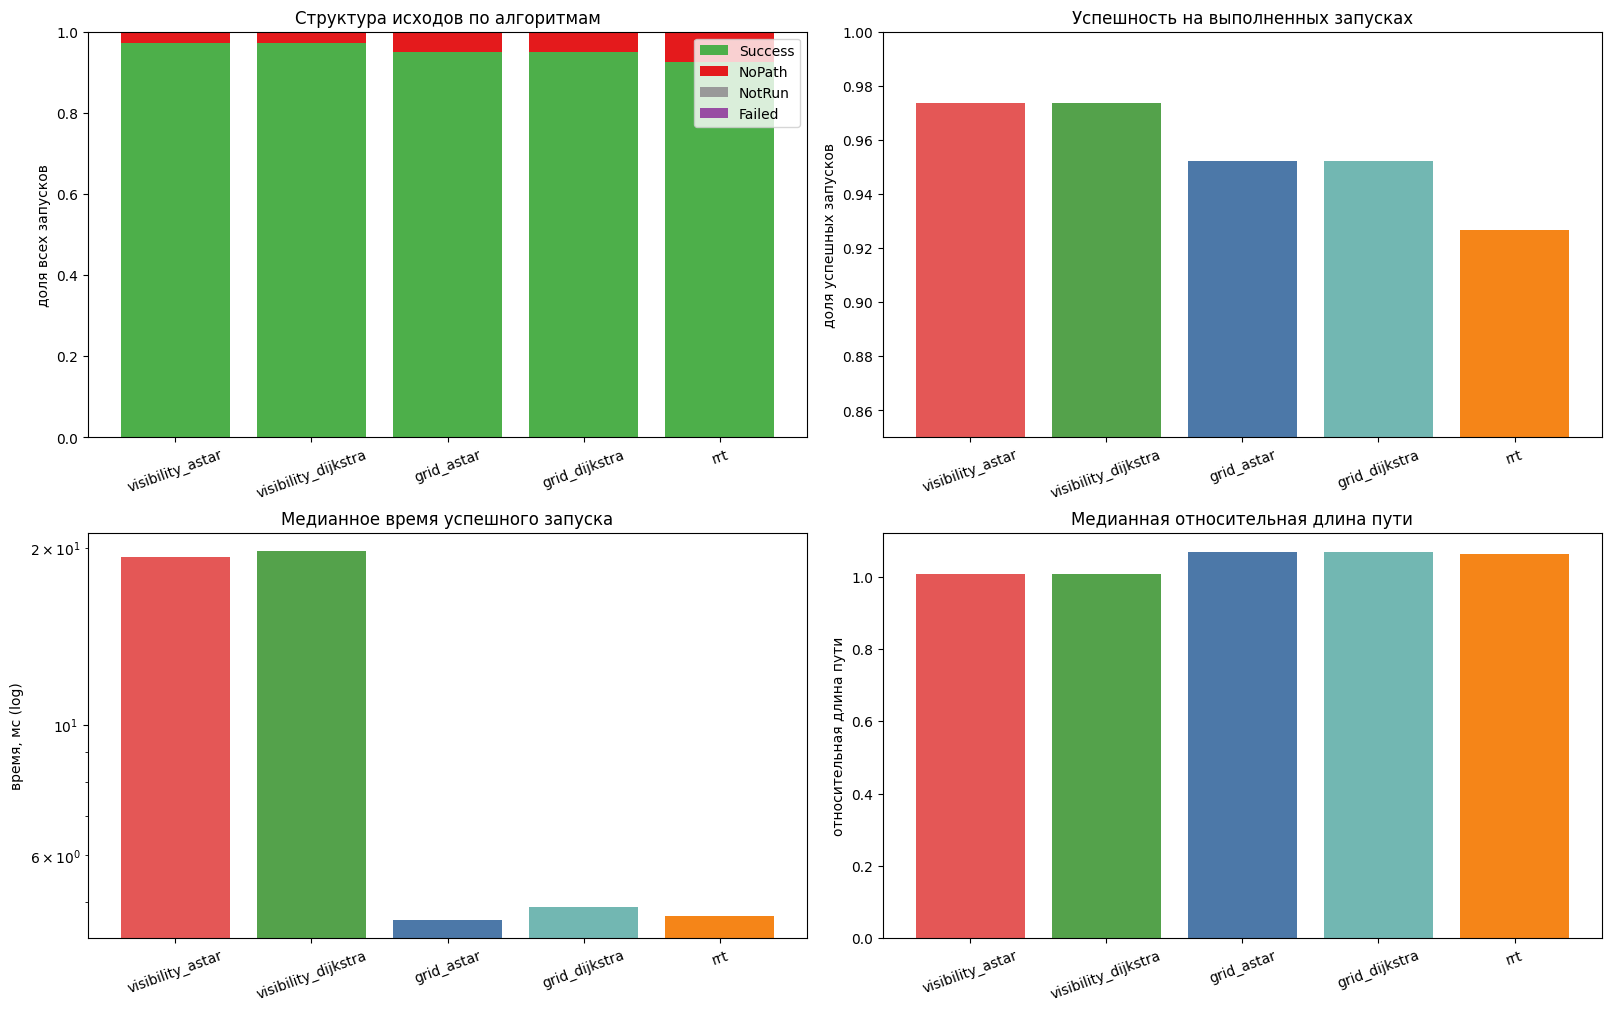

In [29]:
plot_order = algorithm_overview_df.index.tolist()
status_share_df = status_counts_df.loc[plot_order].div(status_counts_df.loc[plot_order].sum(axis=1), axis=0)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

bottom = np.zeros(len(plot_order))
for status, color in [('Success', '#4daf4a'), ('NoPath', '#e41a1c'), ('NotRun', '#999999'), ('Failed', '#984ea3')]:
    values = status_share_df[status].values
    axes[0, 0].bar(plot_order, values, bottom=bottom, color=color, label=status)
    bottom += values
axes[0, 0].set_title('Структура исходов по алгоритмам')
axes[0, 0].set_ylabel('доля всех запусков')
axes[0, 0].legend(loc='upper right')
axes[0, 0].tick_params(axis='x', rotation=20)

success_values = algorithm_overview_df.loc[plot_order, 'success_rate_executed']
axes[0, 1].bar(plot_order, success_values, color=[ALGORITHM_COLORS[a] for a in plot_order])
axes[0, 1].set_title('Успешность на выполненных запусках')
axes[0, 1].set_ylabel('доля успешных запусков')
axes[0, 1].set_ylim(0.85, 1.0)
axes[0, 1].tick_params(axis='x', rotation=20)

runtime_values = algorithm_overview_df.loc[plot_order, 'median_runtime_success_ms']
axes[1, 0].bar(plot_order, runtime_values, color=[ALGORITHM_COLORS[a] for a in plot_order])
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Медианное время успешного запуска')
axes[1, 0].set_ylabel('время, мс (log)')
axes[1, 0].tick_params(axis='x', rotation=20)

quality_values = algorithm_overview_df.loc[plot_order, 'median_relative_path_length']
axes[1, 1].bar(plot_order, quality_values, color=[ALGORITHM_COLORS[a] for a in plot_order])
axes[1, 1].set_title('Медианная относительная длина пути')
axes[1, 1].set_ylabel('относительная длина пути')
axes[1, 1].tick_params(axis='x', rotation=20)

overview_figure_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_overview.png'
fig.savefig(overview_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', overview_figure_path)
plt.show()

На этом уровне уже видна основная картина: visibility-методы лидируют по успешности и качеству, RRT выигрывает по времени, а grid-подходы занимают компромиссную позицию с более высокой вычислительной ценой.

Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_distributions_tradeoff.png


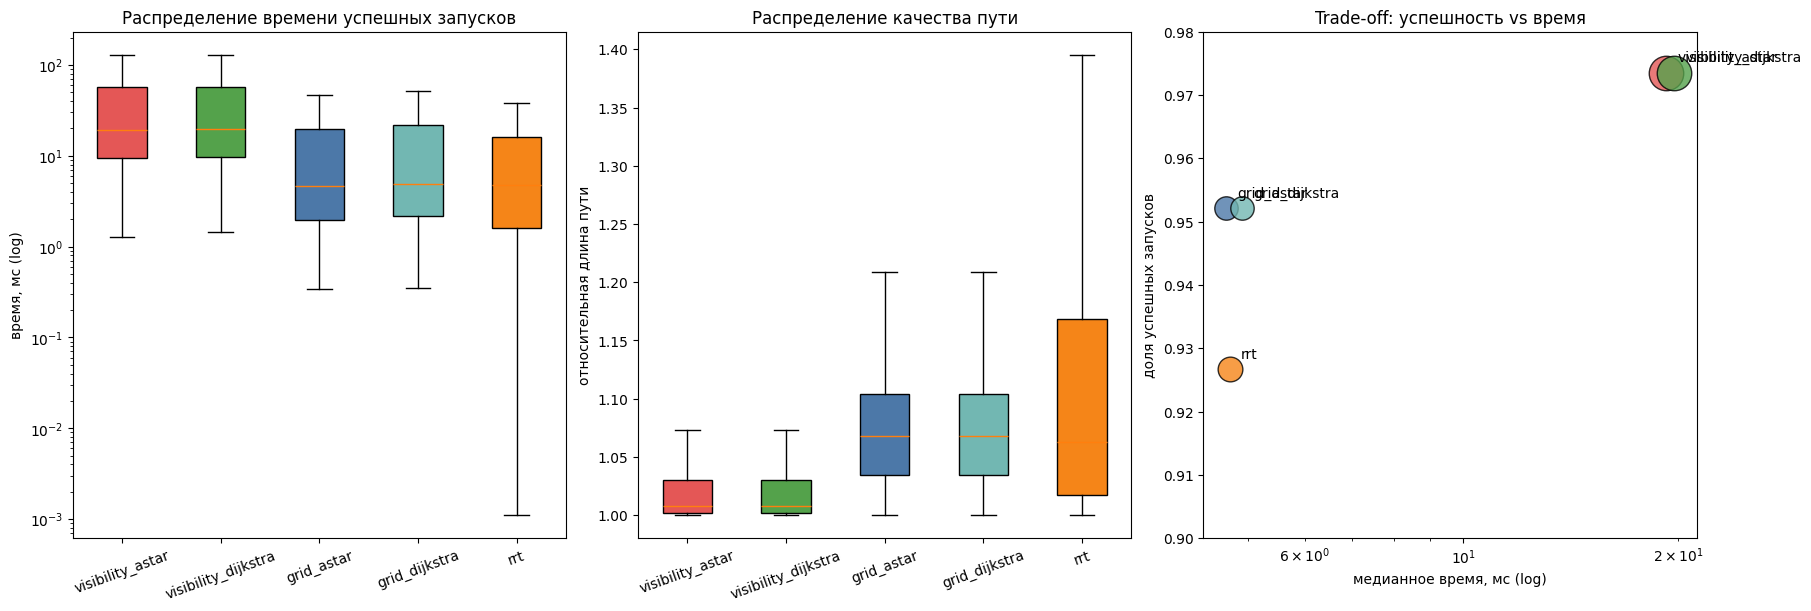

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

runtime_series = [SUCCESS_RUNS_DF.loc[SUCCESS_RUNS_DF['algorithm_id'] == algorithm_id, 'runtime_ms'].values for algorithm_id in plot_order]
runtime_box = axes[0].boxplot(runtime_series, tick_labels=plot_order, showfliers=False, patch_artist=True)
for patch, algorithm_id in zip(runtime_box['boxes'], plot_order):
    patch.set_facecolor(ALGORITHM_COLORS[algorithm_id])
axes[0].set_yscale('log')
axes[0].set_title('Распределение времени успешных запусков')
axes[0].set_ylabel('время, мс (log)')
axes[0].tick_params(axis='x', rotation=20)

quality_series = [SUCCESS_RUNS_DF.loc[SUCCESS_RUNS_DF['algorithm_id'] == algorithm_id, 'relative_path_length'].values for algorithm_id in plot_order]
quality_box = axes[1].boxplot(quality_series, tick_labels=plot_order, showfliers=False, patch_artist=True)
for patch, algorithm_id in zip(quality_box['boxes'], plot_order):
    patch.set_facecolor(ALGORITHM_COLORS[algorithm_id])
axes[1].set_title('Распределение качества пути')
axes[1].set_ylabel('относительная длина пути')
axes[1].tick_params(axis='x', rotation=20)

tradeoff_df = algorithm_overview_df.loc[plot_order].reset_index(names='algorithm_id')
for _, row in tradeoff_df.iterrows():
    marker_size = max(120.0, 5500.0 * (1.12 - min(row['median_relative_path_length'], 1.11)))
    axes[2].scatter(
        row['median_runtime_success_ms'],
        row['success_rate_executed'],
        s=marker_size,
        color=ALGORITHM_COLORS[row['algorithm_id']],
        alpha=0.8,
        edgecolors='black',
    )
    axes[2].annotate(row['algorithm_id'], (row['median_runtime_success_ms'], row['success_rate_executed']), xytext=(8, 8), textcoords='offset points')
axes[2].set_xscale('log')
axes[2].set_title('Trade-off: успешность vs время')
axes[2].set_xlabel('медианное время, мс (log)')
axes[2].set_ylabel('доля успешных запусков')
axes[2].set_ylim(0.9, 0.98)

distribution_figure_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_distributions_tradeoff.png'
fig.savefig(distribution_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', distribution_figure_path)
plt.show()

Медианы не описывают всю картину. Распределения показывают, насколько устойчиво алгоритмы удерживают преимущество по всему массиву сцен, а не только в среднем.

Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_config_heatmaps.png


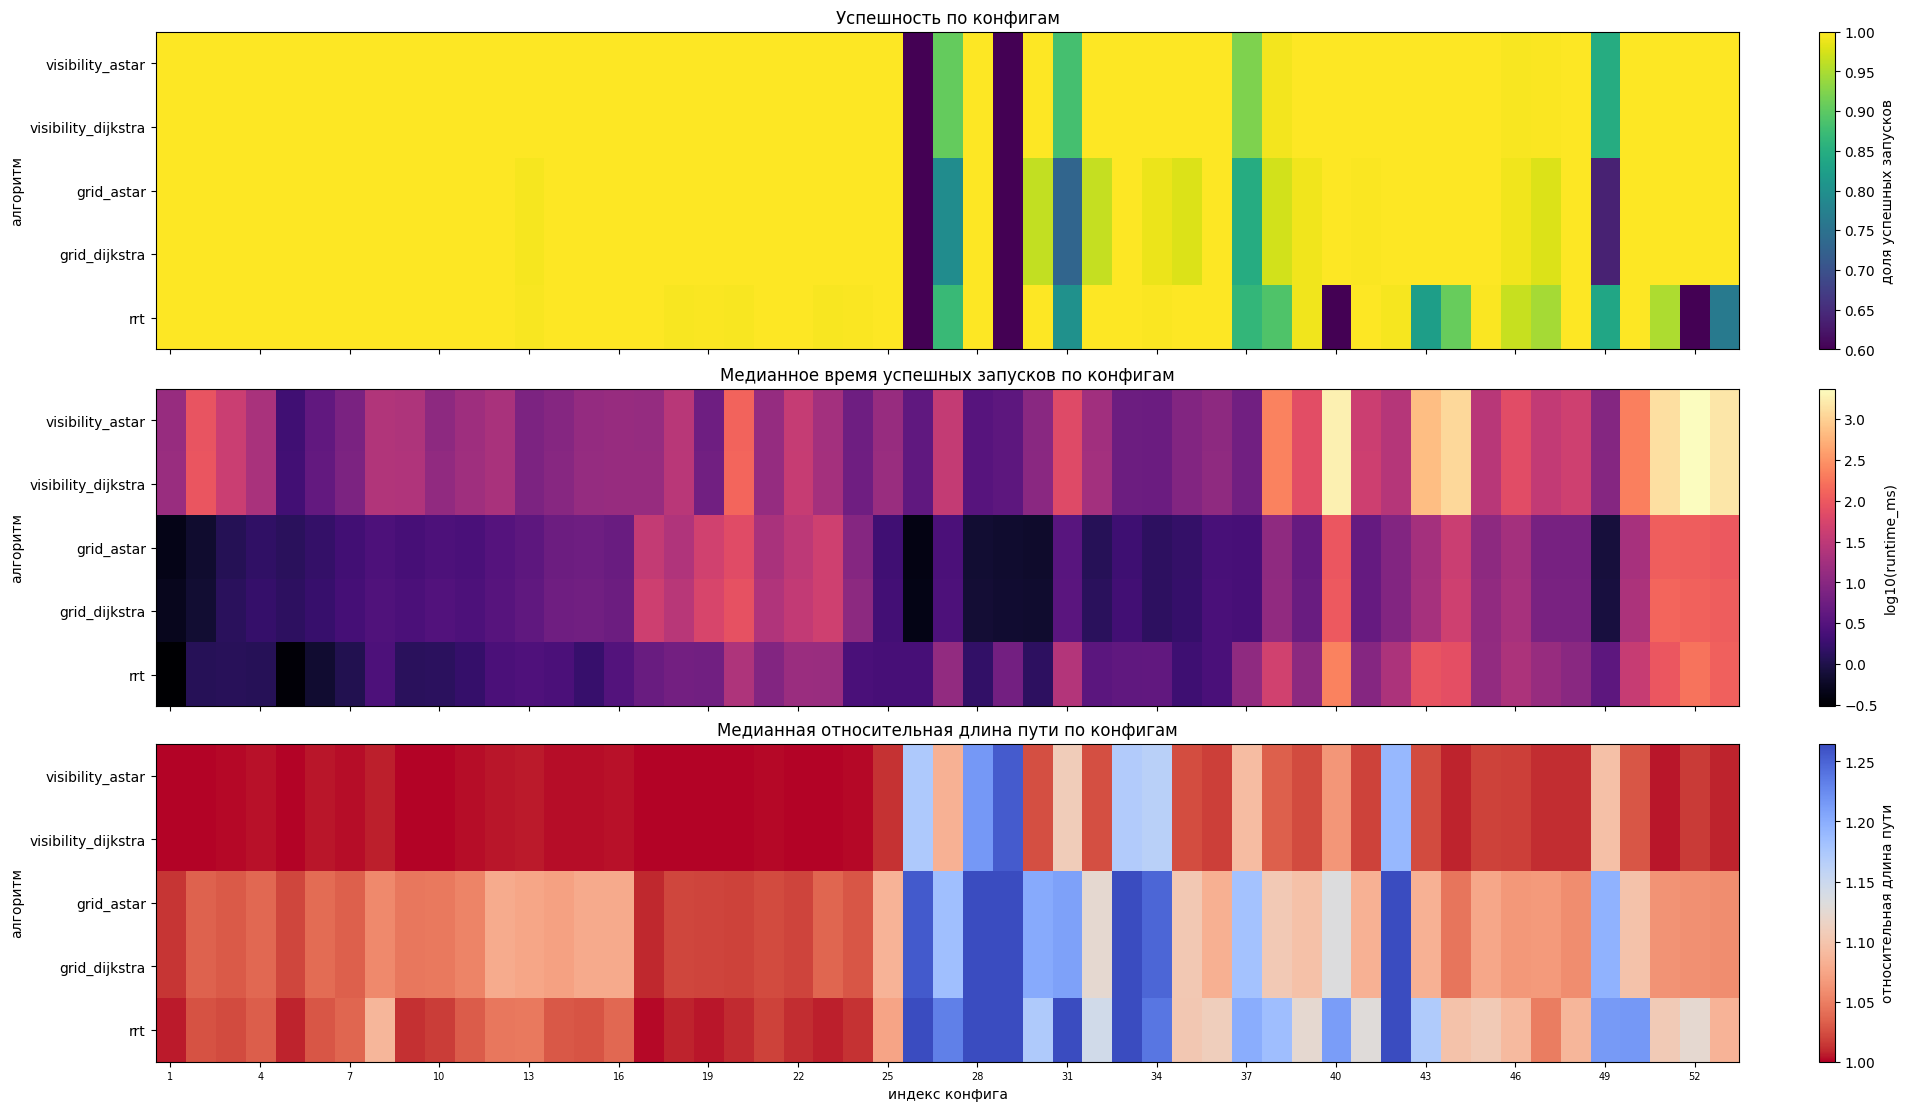

In [31]:
success_heatmap_df = config_success_df.pivot(index='algorithm_id', columns='config_index', values='success_rate').reindex(plot_order)
runtime_heatmap_df = config_runtime_df.pivot(index='algorithm_id', columns='config_index', values='median_runtime_success_ms').reindex(plot_order)
quality_heatmap_df = config_quality_df.pivot(index='algorithm_id', columns='config_index', values='median_relative_path_length').reindex(plot_order)

fig, axes = plt.subplots(3, 1, figsize=(19, 11), constrained_layout=True, sharex=True)
xtick_positions = list(range(0, len(success_heatmap_df.columns), 3))
xtick_labels = success_heatmap_df.columns.astype(int).tolist()[::3]

image = axes[0].imshow(success_heatmap_df.values, aspect='auto', cmap='viridis', vmin=0.6, vmax=1.0)
axes[0].set_title('Успешность по конфигам')
axes[0].set_ylabel('алгоритм')
axes[0].set_yticks(range(len(plot_order)))
axes[0].set_yticklabels(plot_order)
fig.colorbar(image, ax=axes[0], label='доля успешных запусков')

runtime_log_values = np.log10(runtime_heatmap_df.values)
image = axes[1].imshow(runtime_log_values, aspect='auto', cmap='magma')
axes[1].set_title('Медианное время успешных запусков по конфигам')
axes[1].set_ylabel('алгоритм')
axes[1].set_yticks(range(len(plot_order)))
axes[1].set_yticklabels(plot_order)
fig.colorbar(image, ax=axes[1], label='log10(runtime_ms)')

quality_limit = np.nanpercentile(quality_heatmap_df.values, 95)
image = axes[2].imshow(quality_heatmap_df.values, aspect='auto', cmap='coolwarm_r', vmin=1.0, vmax=quality_limit)
axes[2].set_title('Медианная относительная длина пути по конфигам')
axes[2].set_ylabel('алгоритм')
axes[2].set_xlabel('индекс конфига')
axes[2].set_yticks(range(len(plot_order)))
axes[2].set_yticklabels(plot_order)
axes[2].set_xticks(xtick_positions)
axes[2].set_xticklabels(xtick_labels, rotation=0, fontsize=7)
fig.colorbar(image, ax=axes[2], label='относительная длина пути')

config_heatmap_algo_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_config_heatmaps.png'
fig.savefig(config_heatmap_algo_path, dpi=180, bbox_inches='tight')
print('Saved:', config_heatmap_algo_path)
plt.show()

    Далее сравнение переносится на уровень конфигураций. Heatmap-представление показывает не средний результат по всему датасету, а устойчивость преимущества алгоритмов на разных семействах сцен.
    


Различия между алгоритмами зависят от семейства конфигураций. На более тяжелых сценах расслоение между методами становится заметно сильнее.

In [32]:
def build_tie_aware_share_matrix(pivot_df):
    algorithms = list(pivot_df.columns)
    share_matrix = pd.DataFrame(index=algorithms, columns=algorithms, dtype=float)
    support_matrix = pd.DataFrame(index=algorithms, columns=algorithms, dtype=float)
    for algorithm_a in algorithms:
        for algorithm_b in algorithms:
            common = pivot_df[[algorithm_a, algorithm_b]].dropna()
            support_matrix.loc[algorithm_a, algorithm_b] = len(common)
            if len(common) == 0:
                share_matrix.loc[algorithm_a, algorithm_b] = np.nan
            elif algorithm_a == algorithm_b:
                share_matrix.loc[algorithm_a, algorithm_b] = 0.5
            else:
                better_share = (common[algorithm_a] < common[algorithm_b]).mean()
                tie_share = (common[algorithm_a] == common[algorithm_b]).mean()
                share_matrix.loc[algorithm_a, algorithm_b] = better_share + 0.5 * tie_share
    return share_matrix.astype(float), support_matrix.astype(int)

In [33]:
runtime_pivot_df = SUCCESS_RUNS_DF.pivot_table(index=['config_index', 'scene_id'], columns='algorithm_id', values='runtime_ms')
quality_pivot_df = SUCCESS_RUNS_DF.pivot_table(index=['config_index', 'scene_id'], columns='algorithm_id', values='relative_path_length')
runtime_pairwise_df, runtime_support_df = build_tie_aware_share_matrix(runtime_pivot_df)
quality_pairwise_df, quality_support_df = build_tie_aware_share_matrix(quality_pivot_df)

runtime_pairwise_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_runtime_pairwise.csv'
quality_pairwise_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_quality_pairwise.csv'
runtime_pairwise_df.to_csv(runtime_pairwise_path)
quality_pairwise_df.to_csv(quality_pairwise_path)

Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_runtime_pairwise.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_quality_pairwise.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_pairwise_dominance.png


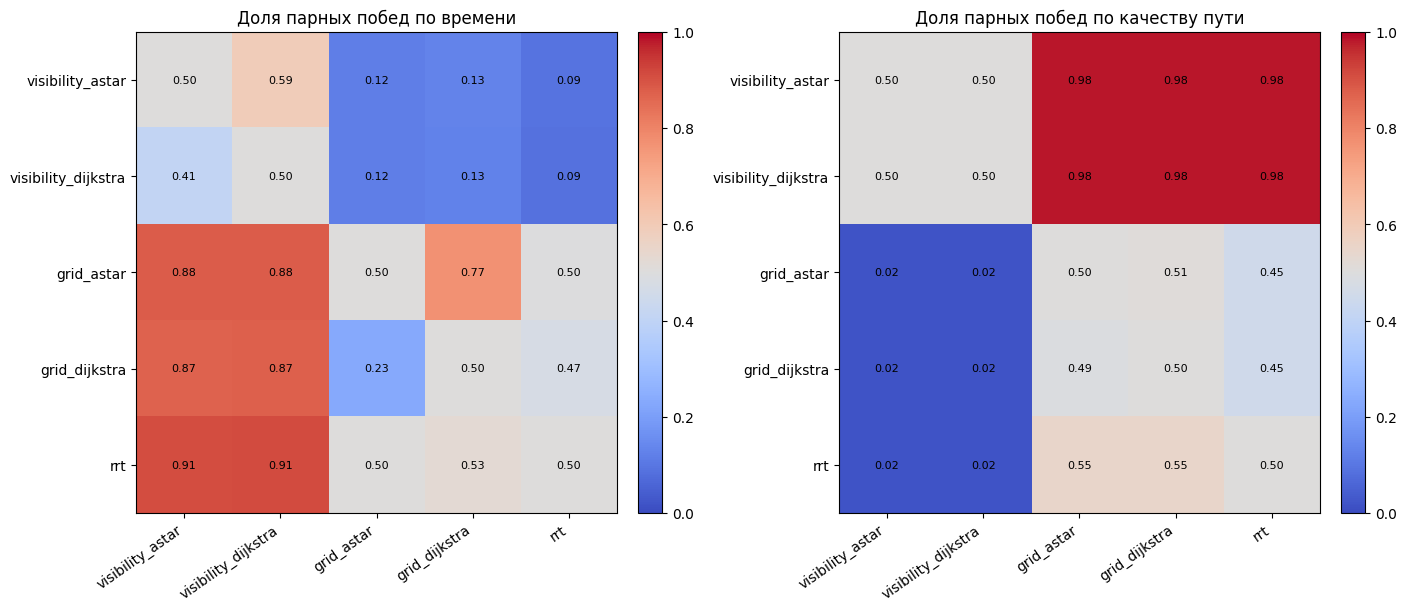

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
for ax, matrix_df, title in [
    (axes[0], runtime_pairwise_df.reindex(index=plot_order, columns=plot_order), 'Доля парных побед по времени'),
    (axes[1], quality_pairwise_df.reindex(index=plot_order, columns=plot_order), 'Доля парных побед по качеству пути'),
]:
    image = ax.imshow(matrix_df.values, cmap='coolwarm', vmin=0.0, vmax=1.0)
    ax.set_title(title)
    ax.set_xticks(range(len(plot_order)))
    ax.set_yticks(range(len(plot_order)))
    ax.set_xticklabels(plot_order, rotation=35, ha='right')
    ax.set_yticklabels(plot_order)
    for i in range(len(plot_order)):
        for j in range(len(plot_order)):
            ax.text(j, i, f'{matrix_df.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

pairwise_figure_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_pairwise_dominance.png'
fig.savefig(pairwise_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', runtime_pairwise_path)
print('Saved:', quality_pairwise_path)
print('Saved:', pairwise_figure_path)
plt.show()

    Парные сравнения по сценам делают trade-off особенно наглядным: один и тот же алгоритм может выигрывать по времени, но уступать по качеству маршрута. Именно из таких наблюдений вытекает необходимость отдельного блока с рекомендательной ML-моделью.
    


## Связь параметров среды с успешностью алгоритмов

Для интерпретации успешности важно разделить два уровня анализа. Сначала оценивается общая доля успешных запусков по алгоритмам, а затем — то, как эта доля меняется при усложнении среды по отдельным scene-метрикам и их сочетаниям.

Ниже используются только выполненные запуски (`algorithm_was_executed == True`), поэтому строки `NotRun` не искажают выводы об устойчивости планировщиков.

### Подготовка метрик успешности

Задаются метрики среды и ранговое представление, которое делает сравнение простых и сложных сцен устойчивее к масштабу признаков.

In [35]:
ALGO_CORRELATION_METRICS = [
    'scene_metric_obstacle_area_ratio',
    'scene_metric_boundary_density',
    'scene_metric_clearance',
    'scene_metric_largest_component_ratio',
    'scene_metric_cell_density_cv',
    'scene_metric_radii_cv',
    'scene_width',
    'scene_height',
    'scene_obstacle_count',
    'scene_direct_distance',
]

SUCCESS_METRICS = SCENE_METRIC_COLUMNS.copy()

In [36]:
def add_quantile_ranks(df, value_column, rank_column, q):
    temp_df = df.copy()
    if temp_df[value_column].nunique(dropna=True) < 2:
        temp_df[rank_column] = pd.Series(pd.NA, index=temp_df.index, dtype='Int64')
        return temp_df, 0
    try:
        quantile_bins = pd.qcut(temp_df[value_column], q=q, duplicates='drop')
    except ValueError:
        temp_df[rank_column] = pd.Series(pd.NA, index=temp_df.index, dtype='Int64')
        return temp_df, 0
    temp_df[rank_column] = pd.Series(quantile_bins.cat.codes + 1, index=temp_df.index, dtype='Int64')
    temp_df.loc[quantile_bins.isna(), rank_column] = pd.NA
    return temp_df, int(temp_df[rank_column].dropna().nunique())

### Корреляции успешности с параметрами среды

Для каждого алгоритма оценивается связь успешности с метриками сцены и готовится матрица для heatmap.

In [37]:
correlation_rows = []
for algorithm_id, algorithm_df in EXECUTED_RUNS_DF.groupby('algorithm_id'):
    for metric in ALGO_CORRELATION_METRICS:
        metric_df = algorithm_df[[metric, 'path_found', 'runtime_ms', 'relative_path_length']].dropna(subset=[metric]).copy()
        success_subset = metric_df[[metric, 'path_found']].dropna()
        runtime_subset = metric_df.loc[metric_df['runtime_ms'] >= 0, [metric, 'runtime_ms']].dropna()
        quality_subset = metric_df.loc[metric_df['path_found'], [metric, 'relative_path_length']].dropna()

        success_corr = success_subset.corr(method='spearman').iloc[0, 1] if len(success_subset) >= 2 else np.nan
        runtime_corr = runtime_subset.corr(method='spearman').iloc[0, 1] if len(runtime_subset) >= 2 else np.nan
        quality_corr = quality_subset.corr(method='spearman').iloc[0, 1] if len(quality_subset) >= 2 else np.nan

        correlation_rows.append({
            'algorithm_id': algorithm_id,
            'metric': metric,
            'success_spearman': success_corr,
            'runtime_spearman': runtime_corr,
            'quality_spearman': quality_corr,
            'success_sample_size': len(success_subset),
            'runtime_sample_size': len(runtime_subset),
            'quality_sample_size': len(quality_subset),
        })

algorithm_metric_correlations_df = pd.DataFrame(correlation_rows)
algorithm_metric_correlations_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_metric_correlations.csv'
algorithm_metric_correlations_df.to_csv(algorithm_metric_correlations_path, index=False)

success_correlation_pairs_df = (
    algorithm_metric_correlations_df.loc[
        algorithm_metric_correlations_df['metric'].isin(SUCCESS_METRICS),
        ['algorithm_id', 'metric', 'success_spearman', 'success_sample_size']
    ]
    .copy()
)
success_corr_heatmap_df = (
    success_correlation_pairs_df
    .pivot(index='algorithm_id', columns='metric', values='success_spearman')
    .reindex(index=plot_order, columns=SUCCESS_METRICS)
)

### Чувствительность успешности к сложности сцены

Сравниваются нижние и верхние квантили метрик среды, чтобы увидеть, где успешность алгоритмов падает сильнее всего.

In [38]:
sensitivity_rows = []
for algorithm_id, algorithm_df in EXECUTED_RUNS_DF.groupby('algorithm_id'):
    for metric in SUCCESS_METRICS:
        metric_df = algorithm_df[[metric, 'path_found']].dropna().copy()
        metric_df, quantile_count = add_quantile_ranks(metric_df, metric, 'metric_quantile_rank', q=4)
        metric_df = metric_df.dropna(subset=['metric_quantile_rank']).copy()
        if metric_df.empty or quantile_count < 2:
            continue
        profile_df = (
            metric_df.groupby('metric_quantile_rank')
            .agg(
                metric_value=(metric, 'median'),
                success_rate=('path_found', 'mean'),
                sample_count=('path_found', 'size'),
            )
            .reset_index()
            .sort_values('metric_value')
            .reset_index(drop=True)
        )
        low_row = profile_df.iloc[0]
        high_row = profile_df.iloc[-1]

        sensitivity_rows.append({
            'algorithm_id': algorithm_id,
            'metric': metric,
            'low_metric_value': low_row['metric_value'],
            'high_metric_value': high_row['metric_value'],
            'low_quantile_success_rate': low_row['success_rate'],
            'high_quantile_success_rate': high_row['success_rate'],
            'low_quantile_sample_count': low_row['sample_count'],
            'high_quantile_sample_count': high_row['sample_count'],
            'delta_success_high_minus_low': high_row['success_rate'] - low_row['success_rate'],
            'abs_delta_success': abs(high_row['success_rate'] - low_row['success_rate']),
            'quantile_count': quantile_count,
        })

success_sensitivity_df = pd.DataFrame(sensitivity_rows)
success_sensitivity_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_success_sensitivity.csv'
success_sensitivity_df.to_csv(success_sensitivity_path, index=False)

success_sensitivity_heatmap_df = (
    success_sensitivity_df
    .pivot(index='algorithm_id', columns='metric', values='delta_success_high_minus_low')
    .reindex(index=plot_order, columns=SUCCESS_METRICS)
)

success_metric_summary_df = (
    success_correlation_pairs_df
    .merge(success_sensitivity_df, on=['algorithm_id', 'metric'], how='left')
    .assign(
        algorithm_label=lambda df: df['algorithm_id'].map(ALGORITHM_LABELS).fillna(df['algorithm_id']),
        metric_label=lambda df: df['metric'].map(SCENE_METRIC_LABELS).fillna(df['metric']),
    )
)
success_metric_summary_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_success_metric_summary.csv'
success_metric_summary_df.to_csv(success_metric_summary_path, index=False)

success_top_links_df = (
    success_metric_summary_df
    .assign(abs_success_spearman=lambda df: df['success_spearman'].abs())
    .sort_values('abs_success_spearman', ascending=False)
    .reset_index(drop=True)
)
success_top_deltas_df = (
    success_metric_summary_df
    .sort_values('abs_delta_success', ascending=False)
    .reset_index(drop=True)
)

overall_success_plot_df = (
    algorithm_overview_df.loc[plot_order, ['success_rate_executed', 'executed_runs']]
    .reset_index(names='algorithm_id')
    .assign(algorithm_label=lambda df: df['algorithm_id'].map(ALGORITHM_LABELS).fillna(df['algorithm_id']))
)
overall_success_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_success_overview.csv'
overall_success_plot_df.to_csv(overall_success_path, index=False)
min_success = max(0.0, float(overall_success_plot_df['success_rate_executed'].min()) - 0.02)
delta_abs_max = np.nanmax(np.abs(success_sensitivity_heatmap_df.values))
delta_abs_max = max(0.02, float(delta_abs_max if np.isfinite(delta_abs_max) else 0.02))

### Сводная визуализация успешности

Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_metric_correlations.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_success_sensitivity.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_success_metric_summary.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_success_overview.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_success_metric_summary.png


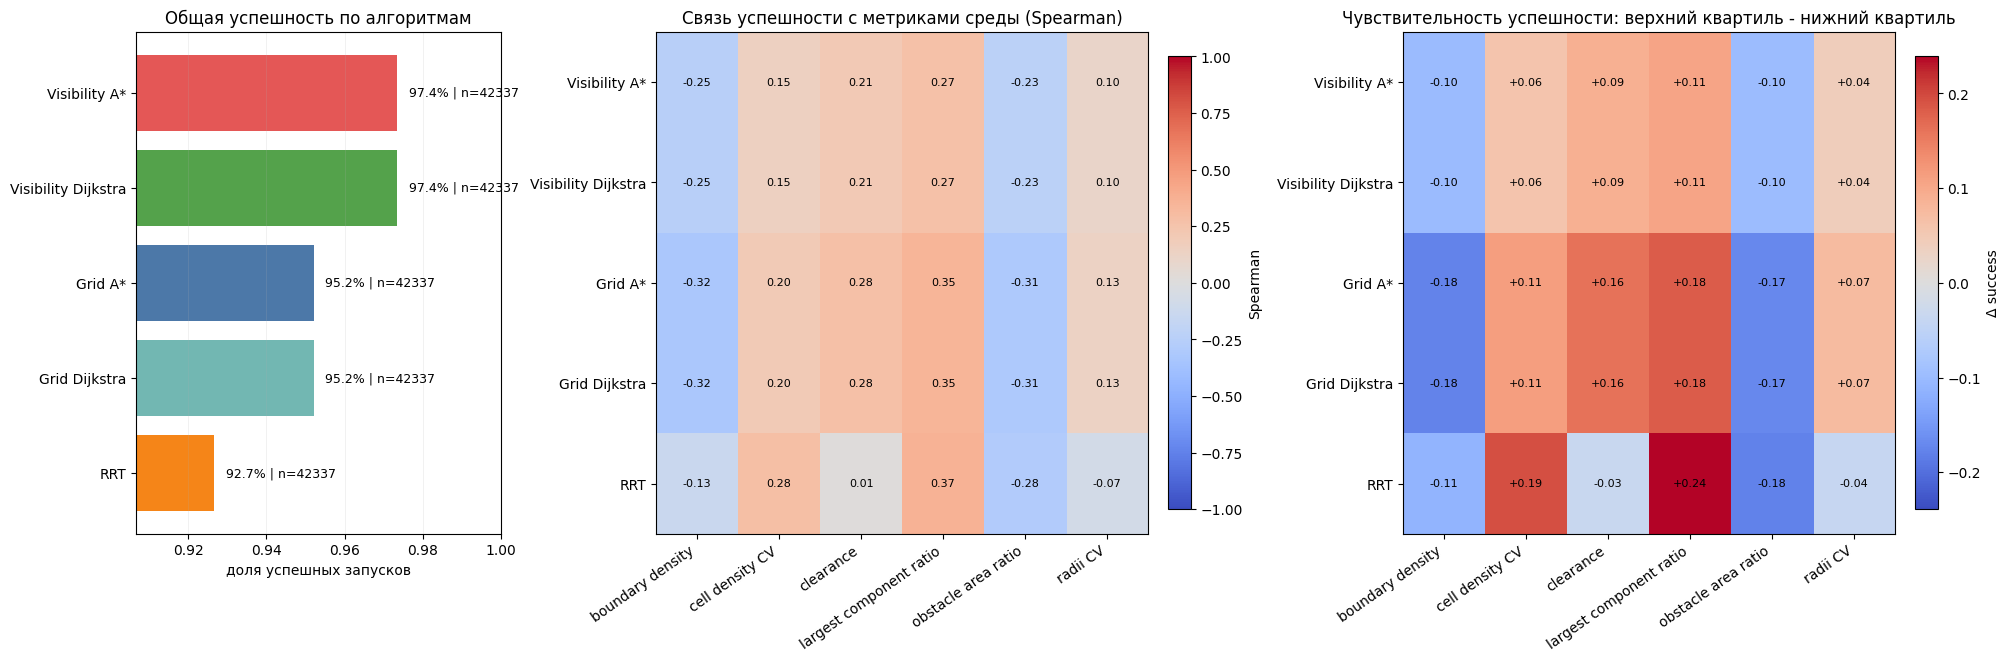

In [39]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6.5),
    constrained_layout=True,
    gridspec_kw={'width_ratios': [1.0, 1.35, 1.35]},
)

y_positions = np.arange(len(overall_success_plot_df))
axes[0].barh(
    y_positions,
    overall_success_plot_df['success_rate_executed'],
    color=[ALGORITHM_COLORS[algorithm_id] for algorithm_id in overall_success_plot_df['algorithm_id']],
)
axes[0].set_yticks(y_positions)
axes[0].set_yticklabels(overall_success_plot_df['algorithm_label'])
axes[0].invert_yaxis()
axes[0].set_xlim(min_success, 1.0)
axes[0].set_xlabel('доля успешных запусков')
axes[0].set_title('Общая успешность по алгоритмам')
axes[0].grid(axis='x', alpha=0.25, linewidth=0.5)
for y_pos, row in enumerate(overall_success_plot_df.itertuples(index=False)):
    axes[0].text(
        min(row.success_rate_executed + 0.003, 0.996),
        y_pos,
        f'{row.success_rate_executed:.1%} | n={int(row.executed_runs)}',
        va='center',
        fontsize=9,
    )

plot_corr_df = success_corr_heatmap_df.rename(index=ALGORITHM_LABELS, columns=SCENE_METRIC_LABELS)
corr_image = axes[1].imshow(plot_corr_df.values, aspect='auto', cmap='coolwarm', vmin=-1.0, vmax=1.0)
axes[1].set_title('Связь успешности с метриками среды (Spearman)')
axes[1].set_yticks(range(len(plot_corr_df.index)))
axes[1].set_yticklabels(plot_corr_df.index)
axes[1].set_xticks(range(len(plot_corr_df.columns)))
axes[1].set_xticklabels(plot_corr_df.columns, rotation=35, ha='right')
for row_index in range(len(plot_corr_df.index)):
    for col_index in range(len(plot_corr_df.columns)):
        value = plot_corr_df.iloc[row_index, col_index]
        if pd.notna(value):
            axes[1].text(col_index, row_index, f'{value:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(corr_image, ax=axes[1], fraction=0.046, pad=0.04, label='Spearman')

plot_delta_df = success_sensitivity_heatmap_df.rename(index=ALGORITHM_LABELS, columns=SCENE_METRIC_LABELS)
delta_image = axes[2].imshow(
    plot_delta_df.values,
    aspect='auto',
    cmap='coolwarm',
    vmin=-delta_abs_max,
    vmax=delta_abs_max,
)
axes[2].set_title('Чувствительность успешности: верхний квартиль - нижний квартиль')
axes[2].set_yticks(range(len(plot_delta_df.index)))
axes[2].set_yticklabels(plot_delta_df.index)
axes[2].set_xticks(range(len(plot_delta_df.columns)))
axes[2].set_xticklabels(plot_delta_df.columns, rotation=35, ha='right')
for row_index in range(len(plot_delta_df.index)):
    for col_index in range(len(plot_delta_df.columns)):
        value = plot_delta_df.iloc[row_index, col_index]
        if pd.notna(value):
            axes[2].text(col_index, row_index, f'{value:+.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(delta_image, ax=axes[2], fraction=0.046, pad=0.04, label='Δ success')

success_summary_figure_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_success_metric_summary.png'
fig.savefig(success_summary_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', algorithm_metric_correlations_path)
print('Saved:', success_sensitivity_path)
print('Saved:', success_metric_summary_path)
print('Saved:', overall_success_path)
print('Saved:', success_summary_figure_path)

### Таблицы ключевых связей успешности

In [40]:
success_top_link_display_df = success_top_links_df[
    [
        'algorithm_label',
        'metric_label',
        'success_spearman',
        'delta_success_high_minus_low',
        'low_quantile_success_rate',
        'high_quantile_success_rate',
    ]
]
success_top_delta_display_df = success_top_deltas_df[
    [
        'algorithm_label',
        'metric_label',
        'delta_success_high_minus_low',
        'success_spearman',
        'low_quantile_success_rate',
        'high_quantile_success_rate',
    ]
]

with pd.option_context('display.max_columns', None, 'display.width', 2200):
    display(success_top_link_display_df.head(12))
    display(success_top_delta_display_df.head(12))

plt.show()

,algorithm_label,metric_label,success_spearman,delta_success_high_minus_low,low_quantile_success_rate,high_quantile_success_rate
0,RRT,largest component ratio,0.365617,0.239112,0.759282,0.998394
1,Grid A*,largest component ratio,0.345807,0.181341,0.817950,0.999291
2,Grid Dijkstra,largest component ratio,0.345807,0.181341,0.817950,0.999291
3,Grid A*,boundary density,-0.322360,-0.176115,0.999906,0.823791
4,Grid Dijkstra,boundary density,-0.322360,-0.176115,0.999906,0.823791
5,Grid Dijkstra,obstacle area ratio,-0.311323,-0.171423,0.999906,0.828482
6,Grid A*,obstacle area ratio,-0.311323,-0.171423,0.999906,0.828482
7,RRT,obstacle area ratio,-0.284669,-0.178230,0.998963,0.820733
8,RRT,cell density CV,0.282766,0.194142,0.801039,0.995181
9,Grid A*,clearance,0.278003,0.161171,0.837600,0.998772


,algorithm_label,metric_label,delta_success_high_minus_low,success_spearman,low_quantile_success_rate,high_quantile_success_rate
0,RRT,largest component ratio,0.239112,0.365617,0.759282,0.998394
1,RRT,cell density CV,0.194142,0.282766,0.801039,0.995181
2,Grid A*,largest component ratio,0.181341,0.345807,0.817950,0.999291
3,Grid Dijkstra,largest component ratio,0.181341,0.345807,0.817950,0.999291
4,RRT,obstacle area ratio,-0.178230,-0.284669,0.998963,0.820733
5,Grid Dijkstra,boundary density,-0.176115,-0.322360,0.999906,0.823791
6,Grid A*,boundary density,-0.176115,-0.322360,0.999906,0.823791
7,Grid A*,obstacle area ratio,-0.171423,-0.311323,0.999906,0.828482
8,Grid Dijkstra,obstacle area ratio,-0.171423,-0.311323,0.999906,0.828482
9,Grid Dijkstra,clearance,0.161171,0.278003,0.837600,0.998772


    Таблица ключевых связей по успешности помогает быстро выделить те метрики среды, при усложнении которых надежность падает сильнее всего. Для основного текста обычно достаточно сослаться на несколько самых устойчивых и интерпретируемых эффектов.
    


Эта панель дает сводку по успешности: общий уровень по алгоритмам, направление связи с метриками среды и чувствительность к переходу от простых сцен к более сложным.

## Связь параметров среды со временем выполнения

Здесь анализируется не вероятность найти путь, а то, насколько сцена замедляет планировщик при выполненном запуске.

### Корреляции времени выполнения с параметрами среды

In [41]:
RUNTIME_METRICS = SUCCESS_METRICS.copy()
runtime_source_df = EXECUTED_RUNS_DF.loc[EXECUTED_RUNS_DF['runtime_ms'] > 0].copy()

runtime_correlation_pairs_df = (
    algorithm_metric_correlations_df.loc[
        algorithm_metric_correlations_df['metric'].isin(RUNTIME_METRICS),
        ['algorithm_id', 'metric', 'runtime_spearman', 'runtime_sample_size']
    ]
    .copy()
)
runtime_corr_heatmap_df = (
    runtime_correlation_pairs_df
    .pivot(index='algorithm_id', columns='metric', values='runtime_spearman')
    .reindex(index=plot_order, columns=RUNTIME_METRICS)
)

### Чувствительность времени выполнения к усложнению сцены

In [42]:
runtime_sensitivity_rows = []
for algorithm_id, algorithm_df in runtime_source_df.groupby('algorithm_id'):
    for metric in RUNTIME_METRICS:
        metric_df = algorithm_df[[metric, 'runtime_ms']].dropna().copy()
        metric_df, quantile_count = add_quantile_ranks(metric_df, metric, 'metric_quantile_rank', q=4)
        metric_df = metric_df.dropna(subset=['metric_quantile_rank']).copy()
        if metric_df.empty or quantile_count < 2:
            continue

        profile_df = (
            metric_df.groupby('metric_quantile_rank')
            .agg(
                metric_value=(metric, 'median'),
                median_runtime_ms=('runtime_ms', 'median'),
                p90_runtime_ms=('runtime_ms', lambda s: s.quantile(0.9)),
                sample_count=('runtime_ms', 'size'),
            )
            .reset_index()
            .sort_values('metric_value')
            .reset_index(drop=True)
        )

        low_row = profile_df.iloc[0]
        high_row = profile_df.iloc[-1]
        runtime_ratio = high_row['median_runtime_ms'] / low_row['median_runtime_ms'] if low_row['median_runtime_ms'] > 0 else np.nan
        log2_runtime_ratio = np.log2(runtime_ratio) if pd.notna(runtime_ratio) and runtime_ratio > 0 else np.nan

        runtime_sensitivity_rows.append({
            'algorithm_id': algorithm_id,
            'metric': metric,
            'low_metric_value': low_row['metric_value'],
            'high_metric_value': high_row['metric_value'],
            'low_quantile_median_runtime_ms': low_row['median_runtime_ms'],
            'high_quantile_median_runtime_ms': high_row['median_runtime_ms'],
            'low_quantile_p90_runtime_ms': low_row['p90_runtime_ms'],
            'high_quantile_p90_runtime_ms': high_row['p90_runtime_ms'],
            'low_quantile_sample_count': low_row['sample_count'],
            'high_quantile_sample_count': high_row['sample_count'],
            'runtime_ratio_high_to_low': runtime_ratio,
            'log2_runtime_ratio_high_to_low': log2_runtime_ratio,
            'quantile_count': quantile_count,
        })

runtime_sensitivity_df = pd.DataFrame(runtime_sensitivity_rows)
runtime_sensitivity_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_runtime_sensitivity.csv'
runtime_sensitivity_df.to_csv(runtime_sensitivity_path, index=False)

runtime_ratio_heatmap_df = (
    runtime_sensitivity_df
    .pivot(index='algorithm_id', columns='metric', values='log2_runtime_ratio_high_to_low')
    .reindex(index=plot_order, columns=RUNTIME_METRICS)
)

runtime_metric_summary_df = (
    runtime_correlation_pairs_df
    .merge(runtime_sensitivity_df, on=['algorithm_id', 'metric'], how='left')
    .assign(
        algorithm_label=lambda df: df['algorithm_id'].map(ALGORITHM_LABELS).fillna(df['algorithm_id']),
        metric_label=lambda df: df['metric'].map(SCENE_METRIC_LABELS).fillna(df['metric']),
    )
)
runtime_metric_summary_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_runtime_metric_summary.csv'
runtime_metric_summary_df.to_csv(runtime_metric_summary_path, index=False)

runtime_top_links_df = (
    runtime_metric_summary_df
    .assign(abs_runtime_spearman=lambda df: df['runtime_spearman'].abs())
    .sort_values('abs_runtime_spearman', ascending=False)
    .reset_index(drop=True)
)
runtime_top_ratios_df = (
    runtime_metric_summary_df
    .assign(abs_log2_runtime_ratio=lambda df: df['log2_runtime_ratio_high_to_low'].abs())
    .sort_values('abs_log2_runtime_ratio', ascending=False)
    .reset_index(drop=True)
)

runtime_ratio_abs_max = np.nanmax(np.abs(runtime_ratio_heatmap_df.values))
runtime_ratio_abs_max = max(0.1, float(runtime_ratio_abs_max if np.isfinite(runtime_ratio_abs_max) else 0.1))

### Сводная визуализация времени выполнения

Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_runtime_sensitivity.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_runtime_metric_summary.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_runtime_metric_summary.png


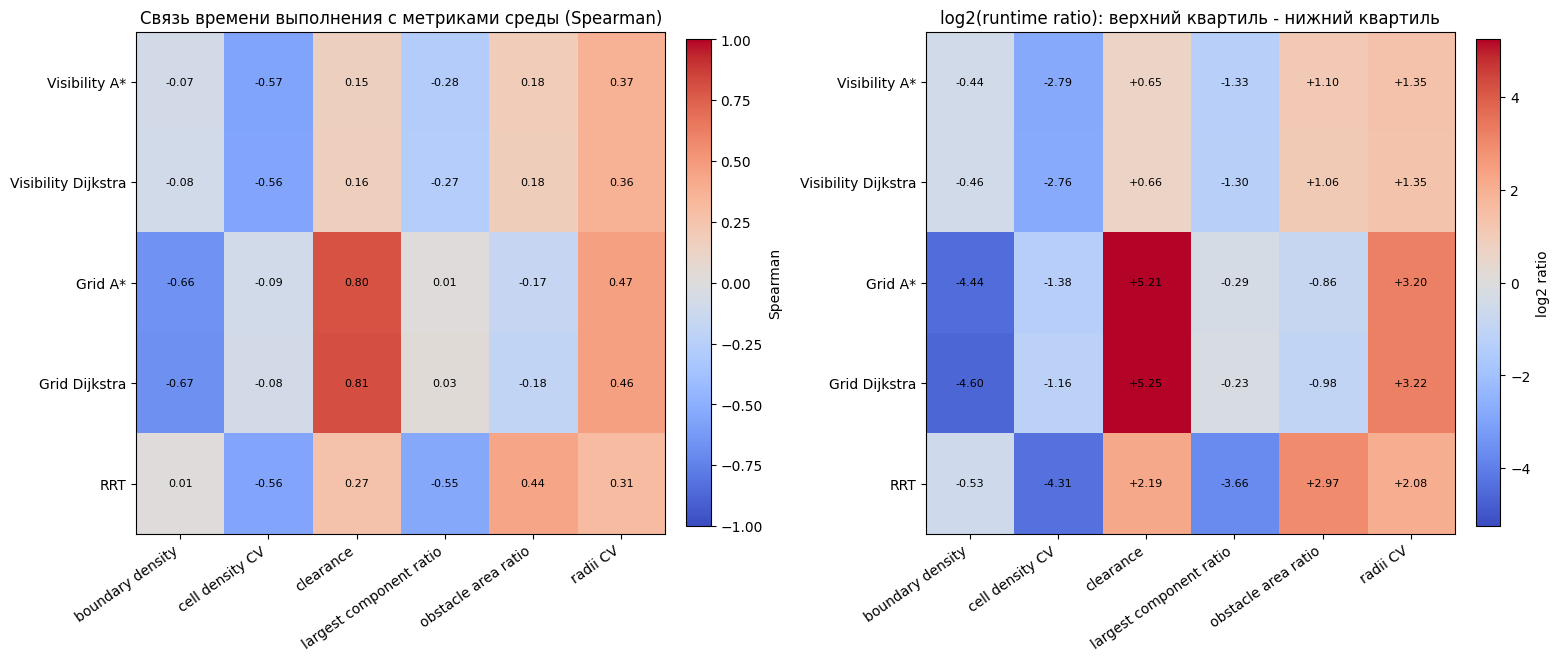

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 6.5), constrained_layout=True)

plot_runtime_corr_df = runtime_corr_heatmap_df.rename(index=ALGORITHM_LABELS, columns=SCENE_METRIC_LABELS)
runtime_corr_image = axes[0].imshow(plot_runtime_corr_df.values, aspect='auto', cmap='coolwarm', vmin=-1.0, vmax=1.0)
axes[0].set_title('Связь времени выполнения с метриками среды (Spearman)')
axes[0].set_yticks(range(len(plot_runtime_corr_df.index)))
axes[0].set_yticklabels(plot_runtime_corr_df.index)
axes[0].set_xticks(range(len(plot_runtime_corr_df.columns)))
axes[0].set_xticklabels(plot_runtime_corr_df.columns, rotation=35, ha='right')
for row_index in range(len(plot_runtime_corr_df.index)):
    for col_index in range(len(plot_runtime_corr_df.columns)):
        value = plot_runtime_corr_df.iloc[row_index, col_index]
        if pd.notna(value):
            axes[0].text(col_index, row_index, f'{value:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(runtime_corr_image, ax=axes[0], fraction=0.046, pad=0.04, label='Spearman')

plot_runtime_ratio_df = runtime_ratio_heatmap_df.rename(index=ALGORITHM_LABELS, columns=SCENE_METRIC_LABELS)
runtime_ratio_image = axes[1].imshow(
    plot_runtime_ratio_df.values,
    aspect='auto',
    cmap='coolwarm',
    vmin=-runtime_ratio_abs_max,
    vmax=runtime_ratio_abs_max,
)
axes[1].set_title('log2(runtime ratio): верхний квартиль - нижний квартиль')
axes[1].set_yticks(range(len(plot_runtime_ratio_df.index)))
axes[1].set_yticklabels(plot_runtime_ratio_df.index)
axes[1].set_xticks(range(len(plot_runtime_ratio_df.columns)))
axes[1].set_xticklabels(plot_runtime_ratio_df.columns, rotation=35, ha='right')
for row_index in range(len(plot_runtime_ratio_df.index)):
    for col_index in range(len(plot_runtime_ratio_df.columns)):
        value = plot_runtime_ratio_df.iloc[row_index, col_index]
        if pd.notna(value):
            axes[1].text(col_index, row_index, f'{value:+.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(runtime_ratio_image, ax=axes[1], fraction=0.046, pad=0.04, label='log2 ratio')

runtime_summary_figure_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_runtime_metric_summary.png'
fig.savefig(runtime_summary_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', runtime_sensitivity_path)
print('Saved:', runtime_metric_summary_path)
print('Saved:', runtime_summary_figure_path)

### Таблицы ключевых связей времени выполнения

In [44]:
runtime_top_link_display_df = runtime_top_links_df[
    [
        'algorithm_label',
        'metric_label',
        'runtime_spearman',
        'runtime_ratio_high_to_low',
        'low_quantile_median_runtime_ms',
        'high_quantile_median_runtime_ms',
    ]
]
runtime_top_ratio_display_df = runtime_top_ratios_df[
    [
        'algorithm_label',
        'metric_label',
        'runtime_ratio_high_to_low',
        'log2_runtime_ratio_high_to_low',
        'runtime_spearman',
        'low_quantile_median_runtime_ms',
        'high_quantile_median_runtime_ms',
    ]
]

with pd.option_context('display.max_columns', None, 'display.width', 2200):
    display(runtime_top_link_display_df.head(12))
    display(runtime_top_ratio_display_df.head(12))

plt.show()

,algorithm_label,metric_label,runtime_spearman,runtime_ratio_high_to_low,low_quantile_median_runtime_ms,high_quantile_median_runtime_ms
0,Grid Dijkstra,clearance,0.806777,37.997860,1.28500,48.82725
1,Grid A*,clearance,0.802840,37.015615,1.19760,44.32990
2,Grid Dijkstra,boundary density,-0.674199,0.041248,32.80910,1.35330
3,Grid A*,boundary density,-0.662095,0.046165,28.95940,1.33690
4,Visibility A*,cell density CV,-0.565013,0.144758,66.47220,9.62240
5,Visibility Dijkstra,cell density CV,-0.560113,0.148051,67.34330,9.97025
6,RRT,cell density CV,-0.558307,0.050344,34.35940,1.72980
7,RRT,largest component ratio,-0.545504,0.079025,27.75390,2.19325
8,Grid A*,radii CV,0.465614,9.181953,1.95710,17.97000
9,Grid Dijkstra,radii CV,0.463711,9.291316,2.09000,19.41885


,algorithm_label,metric_label,runtime_ratio_high_to_low,log2_runtime_ratio_high_to_low,runtime_spearman,low_quantile_median_runtime_ms,high_quantile_median_runtime_ms
0,Grid Dijkstra,clearance,37.997860,5.247846,0.806777,1.28500,48.82725
1,Grid A*,clearance,37.015615,5.210062,0.802840,1.19760,44.32990
2,Grid Dijkstra,boundary density,0.041248,-4.599542,-0.674199,32.80910,1.35330
3,Grid A*,boundary density,0.046165,-4.437068,-0.662095,28.95940,1.33690
4,RRT,cell density CV,0.050344,-4.312028,-0.558307,34.35940,1.72980
5,RRT,largest component ratio,0.079025,-3.661548,-0.545504,27.75390,2.19325
6,Grid Dijkstra,radii CV,9.291316,3.215883,0.463711,2.09000,19.41885
7,Grid A*,radii CV,9.181953,3.198801,0.465614,1.95710,17.97000
8,RRT,obstacle area ratio,7.825880,2.968253,0.436088,1.77895,13.92185
9,Visibility A*,cell density CV,0.144758,-2.788282,-0.565013,66.47220,9.62240


    Для времени выполнения особенно важна не только корреляция, но и разница между нижними и верхними квантилями. Именно эта комбинация показывает, где усложнение сцены приводит к practically meaningful замедлению.
    


### Профили успешности по квантилям метрик

Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_success_profiles.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_success_profiles.png


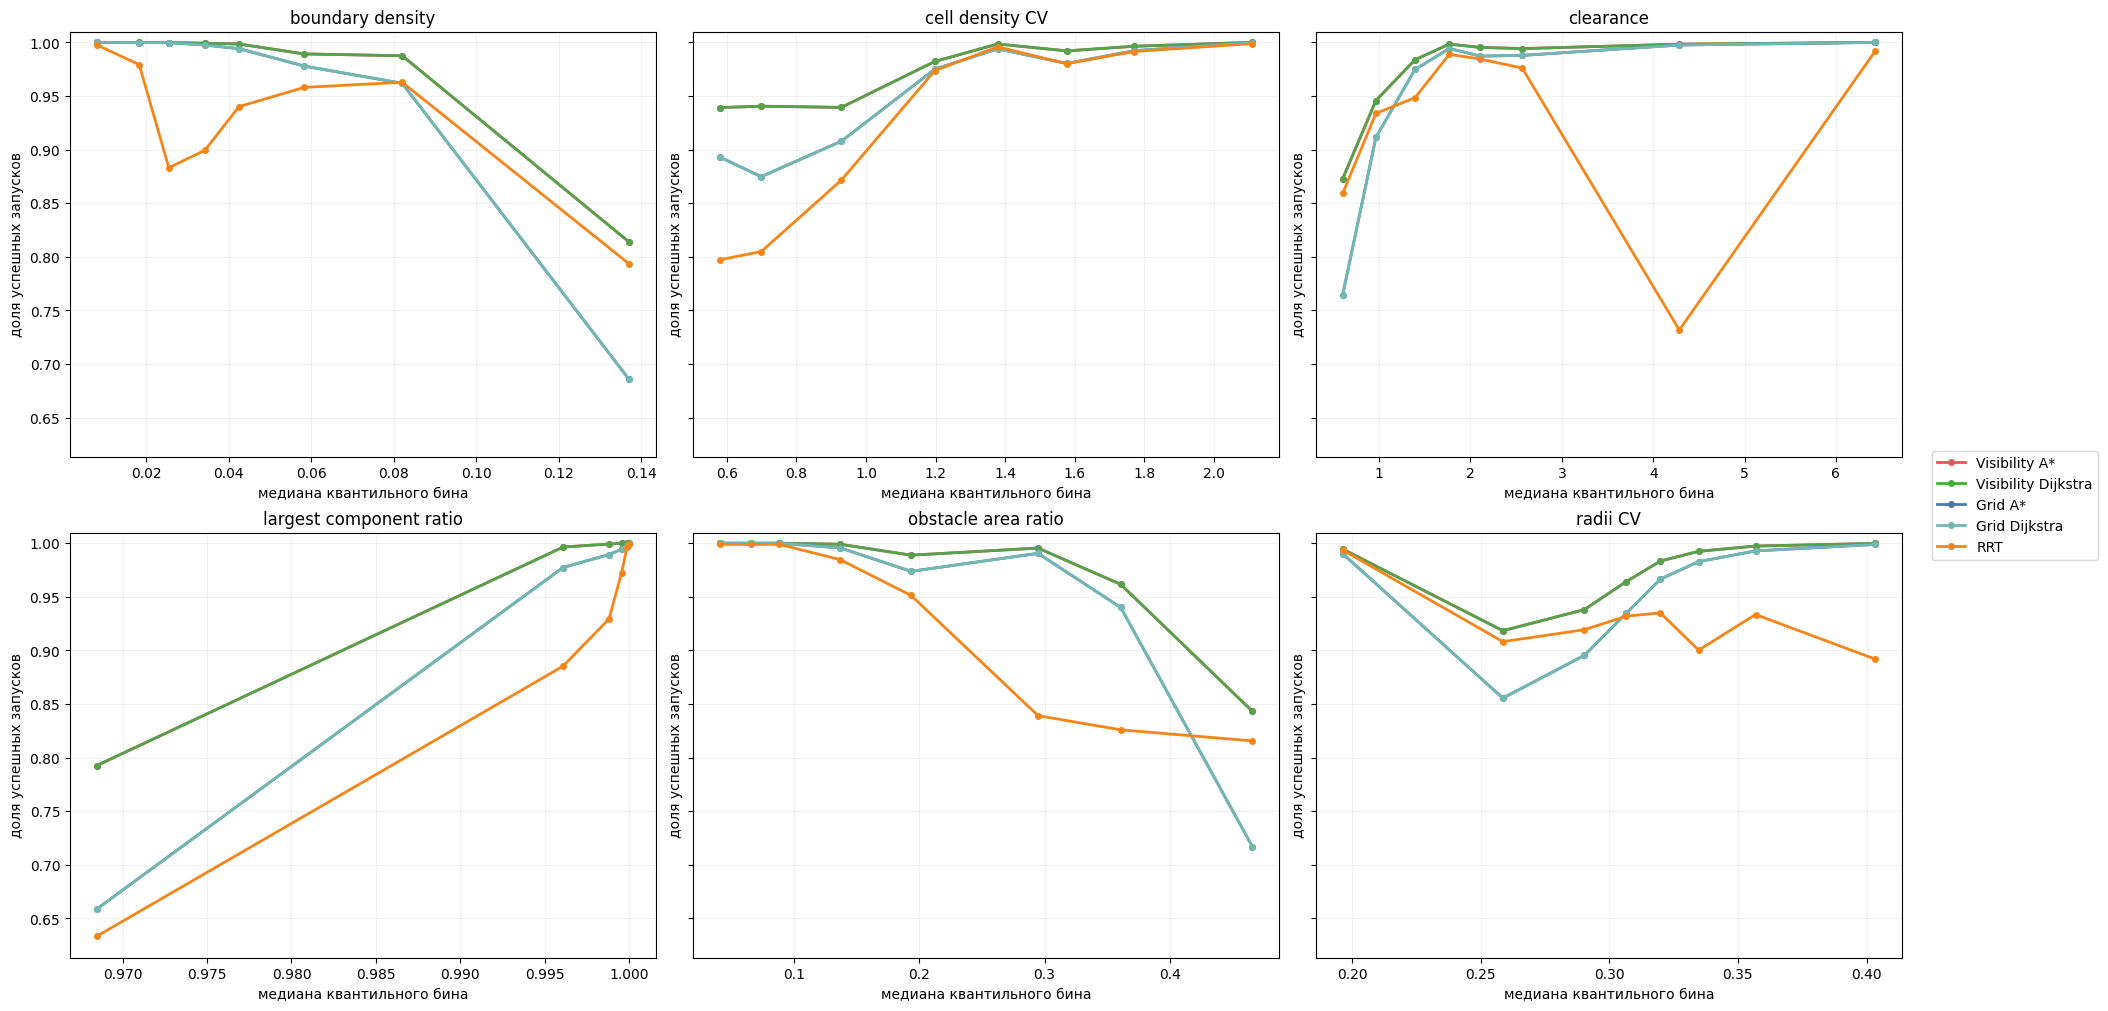

In [45]:
SUCCESS_PROFILE_METRICS = SUCCESS_METRICS.copy()
PROFILE_QUANTILES = 8

profile_frames = []
for metric in SUCCESS_PROFILE_METRICS:
    success_temp_df = EXECUTED_RUNS_DF[[metric, 'algorithm_id', 'path_found']].dropna().copy()
    success_temp_df, metric_bin_count = add_quantile_ranks(success_temp_df, metric, 'metric_bin_rank', q=PROFILE_QUANTILES)
    success_temp_df = success_temp_df.dropna(subset=['metric_bin_rank']).copy()
    if success_temp_df.empty or metric_bin_count < 2:
        continue
    success_profile_df = (
        success_temp_df.groupby(['algorithm_id', 'metric_bin_rank'])
        .agg(
            metric_value=(metric, 'median'),
            success_rate=('path_found', 'mean'),
            sample_count=('path_found', 'size'),
        )
        .reset_index()
        .sort_values(['algorithm_id', 'metric_value'])
        .reset_index(drop=True)
    )
    success_profile_df['metric'] = metric
    success_profile_df['metric_label'] = SCENE_METRIC_LABELS[metric]
    profile_frames.append(success_profile_df)

algorithm_profiles_df = pd.concat(profile_frames, ignore_index=True)
algorithm_profiles_df['algorithm_label'] = algorithm_profiles_df['algorithm_id'].map(ALGORITHM_LABELS).fillna(algorithm_profiles_df['algorithm_id'])
algorithm_profiles_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_success_profiles.csv'
algorithm_profiles_df.to_csv(algorithm_profiles_path, index=False)

success_profile_floor = max(0.6, float(algorithm_profiles_df['success_rate'].min()) - 0.02)

fig, axes = plt.subplots(2, 3, figsize=(19, 10), constrained_layout=True, sharey=True)
for ax, metric in zip(axes.ravel(), SUCCESS_PROFILE_METRICS):
    metric_df = algorithm_profiles_df.loc[algorithm_profiles_df['metric'] == metric].copy()
    for algorithm_id in plot_order:
        line_df = metric_df.loc[metric_df['algorithm_id'] == algorithm_id].sort_values('metric_value')
        ax.plot(
            line_df['metric_value'],
            line_df['success_rate'],
            marker='o',
            linewidth=2,
            markersize=4,
            label=ALGORITHM_LABELS.get(algorithm_id, algorithm_id),
            color=ALGORITHM_COLORS[algorithm_id],
        )
    ax.set_title(SCENE_METRIC_LABELS[metric])
    ax.set_xlabel('медиана квантильного бина')
    ax.set_ylabel('доля успешных запусков')
    ax.set_ylim(success_profile_floor, 1.01)
    ax.grid(alpha=0.25, linewidth=0.5)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5))
profile_figure_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_success_profiles.png'
fig.savefig(profile_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', algorithm_profiles_path)
print('Saved:', profile_figure_path)
plt.show()

### Двумерные зоны риска по успешности

In [46]:
PAIR_PLOT_SPECS = [
    {
        'x': 'scene_metric_boundary_density',
        'y': 'scene_metric_clearance',
    },
    {
        'x': 'scene_metric_obstacle_area_ratio',
        'y': 'scene_metric_largest_component_ratio',
    },
]
PAIR_HEATMAP_ALGORITHMS = [best_success_algorithm, weakest_success_algorithm]
MIN_PAIR_SUPPORT = 40

pair_frames = []
pair_axis_label_map = {}
for spec in PAIR_PLOT_SPECS:
    pair_source_df = EXECUTED_RUNS_DF[['algorithm_id', spec['x'], spec['y'], 'path_found']].dropna().copy()
    pair_source_df, x_bin_count = add_quantile_ranks(pair_source_df, spec['x'], 'x_bin_rank', q=8)
    pair_source_df, y_bin_count = add_quantile_ranks(pair_source_df, spec['y'], 'y_bin_rank', q=8)
    pair_source_df = pair_source_df.dropna(subset=['x_bin_rank', 'y_bin_rank']).copy()
    if pair_source_df.empty or min(x_bin_count, y_bin_count) < 2:
        continue

    pair_title = f"{SCENE_METRIC_LABELS[spec['x']]} × {SCENE_METRIC_LABELS[spec['y']]}"

    pair_axis_label_map[(spec['x'], spec['y'])] = {
        'x': pair_source_df.groupby('x_bin_rank')[spec['x']].median().sort_index(),
        'y': pair_source_df.groupby('y_bin_rank')[spec['y']].median().sort_index(),
    }

    pair_profile_df = (
        pair_source_df.groupby(['algorithm_id', 'x_bin_rank', 'y_bin_rank'])
        .agg(
            x_value=(spec['x'], 'median'),
            y_value=(spec['y'], 'median'),
            success_rate=('path_found', 'mean'),
            sample_count=('path_found', 'size'),
        )
        .reset_index()
    )
    pair_profile_df['x_metric'] = spec['x']
    pair_profile_df['y_metric'] = spec['y']
    pair_profile_df['pair_title'] = pair_title
    pair_profile_df['algorithm_label'] = pair_profile_df['algorithm_id'].map(ALGORITHM_LABELS).fillna(pair_profile_df['algorithm_id'])
    pair_frames.append(pair_profile_df)

pair_success_df = pd.concat(pair_frames, ignore_index=True)
pair_success_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_success_pairs.csv'
pair_success_df.to_csv(pair_success_path, index=False)

supported_pair_df = pair_success_df.loc[pair_success_df['sample_count'] >= MIN_PAIR_SUPPORT].copy()
pair_success_floor = max(0.6, float(supported_pair_df['success_rate'].min()) - 0.03) if not supported_pair_df.empty else 0.6
pair_low_success_cells_df = (
    supported_pair_df
    .assign(
        x_metric_label=lambda df: df['x_metric'].map(SCENE_METRIC_LABELS).fillna(df['x_metric']),
        y_metric_label=lambda df: df['y_metric'].map(SCENE_METRIC_LABELS).fillna(df['y_metric']),
    )
    .sort_values(['success_rate', 'sample_count'], ascending=[True, False])
    .reset_index(drop=True)
)
pair_low_success_cells_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_success_pair_low_cells.csv'
pair_low_success_cells_df.to_csv(pair_low_success_cells_path, index=False)

### Heatmap успешности по парам метрик

Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_success_pairs.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_success_pair_low_cells.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_success_pair_heatmaps.png


,algorithm_label,pair_title,success_rate,sample_count,x_value,y_value
0,RRT,boundary density × clearance,0.061776,259,0.039638,4.015899
1,RRT,boundary density × clearance,0.362534,742,0.032698,3.926940
2,Grid A*,obstacle area ratio × largest component ratio,0.512272,2852,0.496750,0.944086
3,Grid Dijkstra,obstacle area ratio × largest component ratio,0.512272,2852,0.496750,0.944086
4,Grid A*,boundary density × clearance,0.541284,763,0.121948,0.928571
5,Grid Dijkstra,boundary density × clearance,0.541284,763,0.121948,0.928571
6,RRT,obstacle area ratio × largest component ratio,0.561644,584,0.311650,0.983609
7,RRT,boundary density × clearance,0.566011,1424,0.026211,3.840862
8,RRT,obstacle area ratio × largest component ratio,0.569251,1509,0.361700,0.976390
9,Grid A*,boundary density × clearance,0.587345,2908,0.135191,0.553611


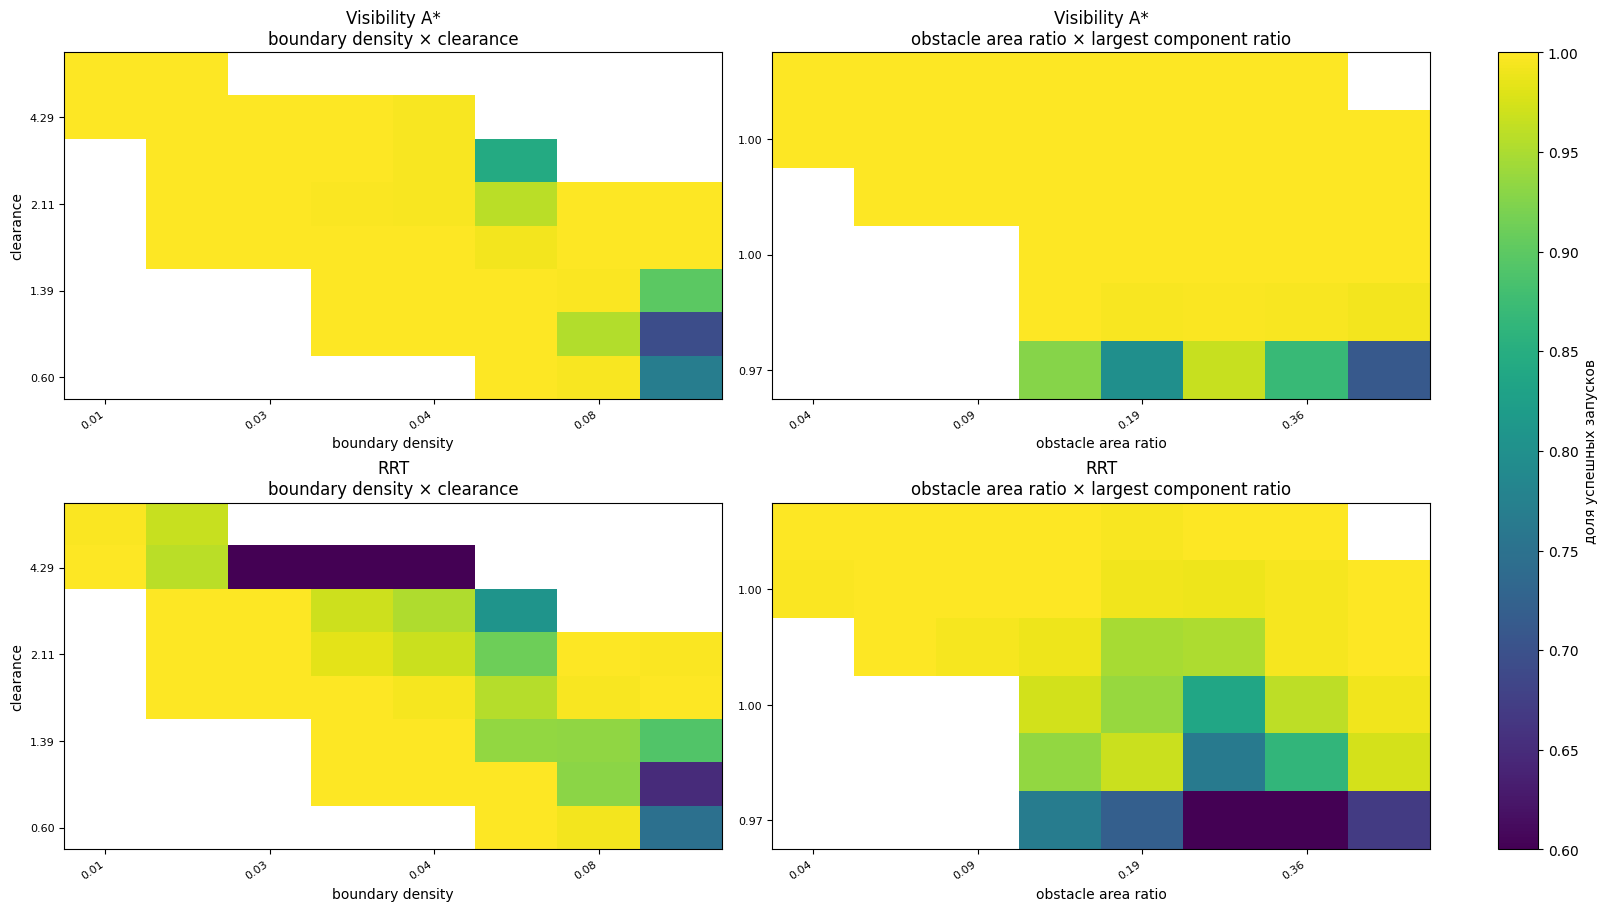

In [47]:
fig, axes = plt.subplots(
    len(PAIR_HEATMAP_ALGORITHMS),
    len(PAIR_PLOT_SPECS),
    figsize=(16, 9),
    constrained_layout=True,
)
if len(PAIR_HEATMAP_ALGORITHMS) == 1:
    axes = np.asarray([axes])

last_image = None
for row_index, algorithm_id in enumerate(PAIR_HEATMAP_ALGORITHMS):
    for col_index, spec in enumerate(PAIR_PLOT_SPECS):
        ax = axes[row_index, col_index]
        plot_df = pair_success_df.loc[
            (pair_success_df['algorithm_id'] == algorithm_id)
            & (pair_success_df['x_metric'] == spec['x'])
            & (pair_success_df['y_metric'] == spec['y'])
        ].copy()

        x_labels = pair_axis_label_map[(spec['x'], spec['y'])]['x']
        y_labels = pair_axis_label_map[(spec['x'], spec['y'])]['y']
        x_size = int(x_labels.index.max())
        y_size = int(y_labels.index.max())

        rate_matrix = np.full((y_size, x_size), np.nan)
        for row in plot_df.itertuples():
            if row.sample_count >= MIN_PAIR_SUPPORT:
                rate_matrix[int(row.y_bin_rank) - 1, int(row.x_bin_rank) - 1] = row.success_rate

        last_image = ax.imshow(
            rate_matrix,
            origin='lower',
            aspect='auto',
            cmap='viridis',
            vmin=pair_success_floor,
            vmax=1.0,
        )
        pair_title = plot_df['pair_title'].iloc[0] if not plot_df.empty else f"{SCENE_METRIC_LABELS[spec['x']]} × {SCENE_METRIC_LABELS[spec['y']]}"
        ax.set_title(f"{ALGORITHM_LABELS.get(algorithm_id, algorithm_id)}\n{pair_title}")
        ax.set_xlabel(SCENE_METRIC_LABELS[spec['x']])
        if col_index == 0:
            ax.set_ylabel(SCENE_METRIC_LABELS[spec['y']])

        x_tick_positions = list(range(0, x_size, 2))
        y_tick_positions = list(range(0, y_size, 2))
        ax.set_xticks(x_tick_positions)
        ax.set_xticklabels(
            [f'{x_labels.iloc[pos]:.2f}' for pos in x_tick_positions],
            rotation=35,
            ha='right',
            fontsize=8,
        )
        ax.set_yticks(y_tick_positions)
        ax.set_yticklabels([f'{y_labels.iloc[pos]:.2f}' for pos in y_tick_positions], fontsize=8)

fig.colorbar(last_image, ax=axes, label='доля успешных запусков')
pair_heatmap_figure_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_success_pair_heatmaps.png'
fig.savefig(pair_heatmap_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', pair_success_path)
print('Saved:', pair_low_success_cells_path)
print('Saved:', pair_heatmap_figure_path)

with pd.option_context('display.max_columns', None, 'display.width', 2200):
    display(pair_low_success_cells_df[['algorithm_label', 'pair_title', 'success_rate', 'sample_count', 'x_value', 'y_value']].head(12))

plt.show()

Линейные профили показывают форму зависимости успешности от каждой метрики среды, а двумерные heatmap-графики помогают локализовать сочетания параметров, где алгоритмы теряют устойчивость.

Для relative_path_length более высокие значения означают менее качественный путь. Поэтому положительные значения на правой heatmap отражают ухудшение качества при переходе к более сложным сценам, а отрицательные значения указывают на отсутствие заметной деградации или на слабую чувствительность алгоритма к соответствующей метрике.

### Корреляции качества пути с параметрами среды

In [48]:
QUALITY_METRICS = SCENE_METRIC_COLUMNS.copy()
quality_source_df = SUCCESS_RUNS_DF.loc[SUCCESS_RUNS_DF['relative_path_length'] > 0].copy()

quality_correlation_pairs_df = (
    algorithm_metric_correlations_df.loc[
        algorithm_metric_correlations_df['metric'].isin(QUALITY_METRICS),
        ['algorithm_id', 'metric', 'quality_spearman', 'quality_sample_size']
    ]
    .copy()
)
quality_corr_heatmap_df = (
    quality_correlation_pairs_df
    .pivot(index='algorithm_id', columns='metric', values='quality_spearman')
    .reindex(index=plot_order, columns=QUALITY_METRICS)
)

### Чувствительность качества пути к усложнению сцены

In [49]:
quality_sensitivity_rows = []
for algorithm_id, algorithm_df in quality_source_df.groupby('algorithm_id'):
    for metric in QUALITY_METRICS:
        metric_df = algorithm_df[[metric, 'relative_path_length']].dropna().copy()
        metric_df, quantile_count = add_quantile_ranks(metric_df, metric, 'metric_quantile_rank', q=4)
        metric_df = metric_df.dropna(subset=['metric_quantile_rank']).copy()
        if metric_df.empty or quantile_count < 2:
            continue

        profile_df = (
            metric_df.groupby('metric_quantile_rank')
            .agg(
                metric_value=(metric, 'median'),
                median_relative_path_length=('relative_path_length', 'median'),
                p90_relative_path_length=('relative_path_length', lambda s: s.quantile(0.9)),
                sample_count=('relative_path_length', 'size'),
            )
            .reset_index()
            .sort_values('metric_value')
            .reset_index(drop=True)
        )

        low_row = profile_df.iloc[0]
        high_row = profile_df.iloc[-1]
        delta_quality = high_row['median_relative_path_length'] - low_row['median_relative_path_length']

        quality_sensitivity_rows.append({
            'algorithm_id': algorithm_id,
            'metric': metric,
            'low_metric_value': low_row['metric_value'],
            'high_metric_value': high_row['metric_value'],
            'low_quantile_median_relative_path_length': low_row['median_relative_path_length'],
            'high_quantile_median_relative_path_length': high_row['median_relative_path_length'],
            'low_quantile_p90_relative_path_length': low_row['p90_relative_path_length'],
            'high_quantile_p90_relative_path_length': high_row['p90_relative_path_length'],
            'low_quantile_sample_count': low_row['sample_count'],
            'high_quantile_sample_count': high_row['sample_count'],
            'delta_relative_path_length': delta_quality,
            'quantile_count': quantile_count,
        })

quality_sensitivity_df = pd.DataFrame(quality_sensitivity_rows)
quality_sensitivity_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_quality_sensitivity.csv'
quality_sensitivity_df.to_csv(quality_sensitivity_path, index=False)

quality_delta_heatmap_df = (
    quality_sensitivity_df
    .pivot(index='algorithm_id', columns='metric', values='delta_relative_path_length')
    .reindex(index=plot_order, columns=QUALITY_METRICS)
)

quality_metric_summary_df = (
    quality_correlation_pairs_df
    .merge(quality_sensitivity_df, on=['algorithm_id', 'metric'], how='left')
    .assign(
        algorithm_label=lambda df: df['algorithm_id'].map(ALGORITHM_LABELS).fillna(df['algorithm_id']),
        metric_label=lambda df: df['metric'].map(SCENE_METRIC_LABELS).fillna(df['metric']),
    )
)
quality_metric_summary_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_quality_metric_summary.csv'
quality_metric_summary_df.to_csv(quality_metric_summary_path, index=False)

quality_top_links_df = (
    quality_metric_summary_df
    .assign(abs_quality_spearman=lambda df: df['quality_spearman'].abs())
    .sort_values('abs_quality_spearman', ascending=False)
    .reset_index(drop=True)
)
quality_top_deltas_df = (
    quality_metric_summary_df
    .assign(abs_delta_relative_path_length=lambda df: df['delta_relative_path_length'].abs())
    .sort_values('abs_delta_relative_path_length', ascending=False)
    .reset_index(drop=True)
)

quality_delta_abs_max = np.nanmax(np.abs(quality_delta_heatmap_df.values))
quality_delta_abs_max = max(0.002, float(quality_delta_abs_max if np.isfinite(quality_delta_abs_max) else 0.002))

### Сводная визуализация качества пути

Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_quality_sensitivity.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_quality_metric_summary.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_quality_metric_summary.png


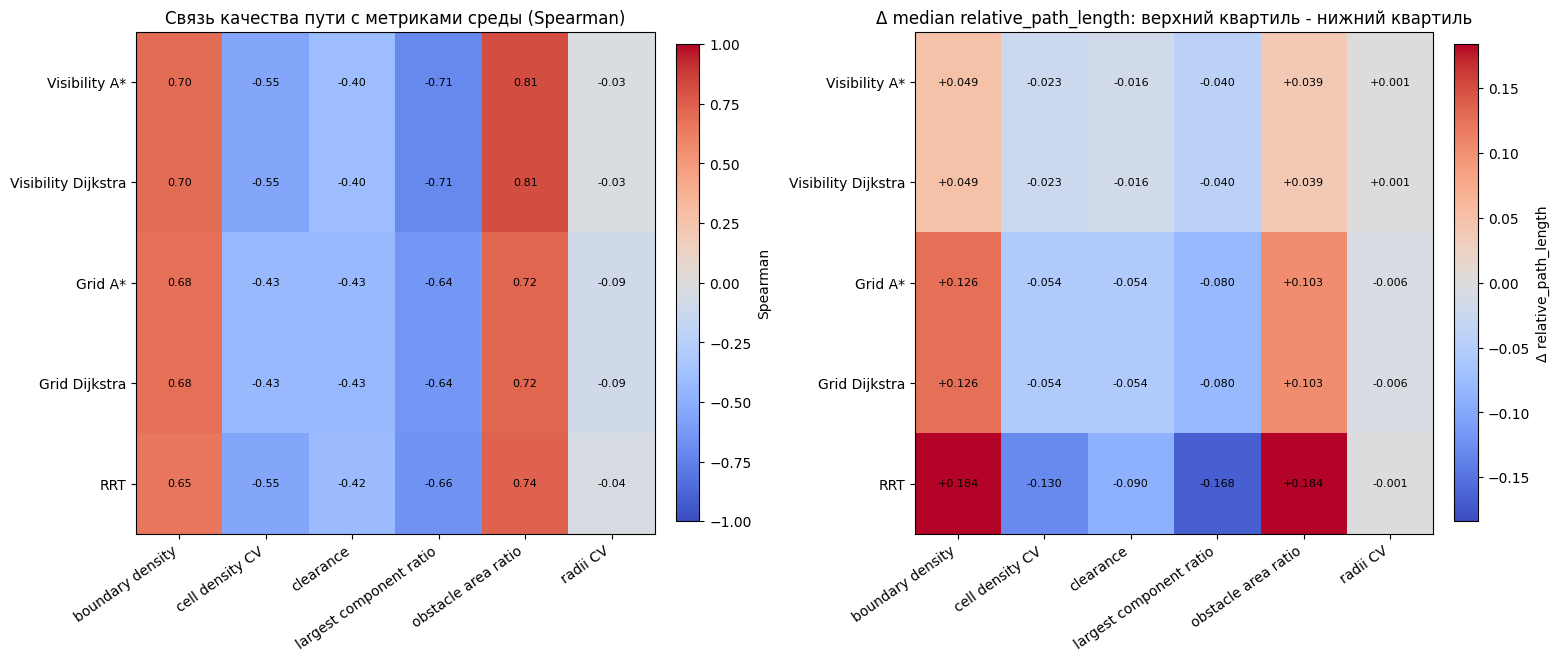

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 6.5), constrained_layout=True)

plot_quality_corr_df = quality_corr_heatmap_df.rename(index=ALGORITHM_LABELS, columns=SCENE_METRIC_LABELS)
quality_corr_image = axes[0].imshow(plot_quality_corr_df.values, aspect='auto', cmap='coolwarm', vmin=-1.0, vmax=1.0)
axes[0].set_title('Связь качества пути с метриками среды (Spearman)')
axes[0].set_yticks(range(len(plot_quality_corr_df.index)))
axes[0].set_yticklabels(plot_quality_corr_df.index)
axes[0].set_xticks(range(len(plot_quality_corr_df.columns)))
axes[0].set_xticklabels(plot_quality_corr_df.columns, rotation=35, ha='right')
for row_index in range(len(plot_quality_corr_df.index)):
    for col_index in range(len(plot_quality_corr_df.columns)):
        value = plot_quality_corr_df.iloc[row_index, col_index]
        if pd.notna(value):
            axes[0].text(col_index, row_index, f'{value:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(quality_corr_image, ax=axes[0], fraction=0.046, pad=0.04, label='Spearman')

plot_quality_delta_df = quality_delta_heatmap_df.rename(index=ALGORITHM_LABELS, columns=SCENE_METRIC_LABELS)
quality_delta_image = axes[1].imshow(
    plot_quality_delta_df.values,
    aspect='auto',
    cmap='coolwarm',
    vmin=-quality_delta_abs_max,
    vmax=quality_delta_abs_max,
)
axes[1].set_title('Δ median relative_path_length: верхний квартиль - нижний квартиль')
axes[1].set_yticks(range(len(plot_quality_delta_df.index)))
axes[1].set_yticklabels(plot_quality_delta_df.index)
axes[1].set_xticks(range(len(plot_quality_delta_df.columns)))
axes[1].set_xticklabels(plot_quality_delta_df.columns, rotation=35, ha='right')
for row_index in range(len(plot_quality_delta_df.index)):
    for col_index in range(len(plot_quality_delta_df.columns)):
        value = plot_quality_delta_df.iloc[row_index, col_index]
        if pd.notna(value):
            axes[1].text(col_index, row_index, f'{value:+.3f}', ha='center', va='center', fontsize=8)
fig.colorbar(quality_delta_image, ax=axes[1], fraction=0.046, pad=0.04, label='Δ relative_path_length')

quality_summary_figure_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_quality_metric_summary.png'
fig.savefig(quality_summary_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', quality_sensitivity_path)
print('Saved:', quality_metric_summary_path)
print('Saved:', quality_summary_figure_path)

### Таблицы ключевых связей качества пути

In [51]:
quality_top_link_display_df = quality_top_links_df[
    [
        'algorithm_label',
        'metric_label',
        'quality_spearman',
        'delta_relative_path_length',
        'low_quantile_median_relative_path_length',
        'high_quantile_median_relative_path_length',
    ]
]
quality_top_delta_display_df = quality_top_deltas_df[
    [
        'algorithm_label',
        'metric_label',
        'delta_relative_path_length',
        'quality_spearman',
        'low_quantile_median_relative_path_length',
        'high_quantile_median_relative_path_length',
    ]
]

with pd.option_context('display.max_columns', None, 'display.width', 2200):
    display(quality_top_link_display_df.head(12))
    display(quality_top_delta_display_df.head(12))

plt.show()

,algorithm_label,metric_label,quality_spearman,delta_relative_path_length,low_quantile_median_relative_path_length,high_quantile_median_relative_path_length
0,Visibility Dijkstra,obstacle area ratio,0.813448,0.038766,1.000803,1.039569
1,Visibility A*,obstacle area ratio,0.813448,0.038766,1.000803,1.039569
2,RRT,obstacle area ratio,0.737049,0.183871,1.011404,1.195276
3,Grid A*,obstacle area ratio,0.722728,0.102912,1.028025,1.130937
4,Grid Dijkstra,obstacle area ratio,0.722728,0.102912,1.028025,1.130937
5,Visibility Dijkstra,largest component ratio,-0.713549,-0.040483,1.042243,1.001760
6,Visibility A*,largest component ratio,-0.713549,-0.040483,1.042243,1.001760
7,Visibility Dijkstra,boundary density,0.696099,0.049143,1.001191,1.050333
8,Visibility A*,boundary density,0.696099,0.049143,1.001191,1.050333
9,Grid Dijkstra,boundary density,0.684438,0.126081,1.028202,1.154283


,algorithm_label,metric_label,delta_relative_path_length,quality_spearman,low_quantile_median_relative_path_length,high_quantile_median_relative_path_length
0,RRT,obstacle area ratio,0.183871,0.737049,1.011404,1.195276
1,RRT,boundary density,0.183845,0.654088,1.012192,1.196037
2,RRT,largest component ratio,-0.167790,-0.662441,1.188642,1.020851
3,RRT,cell density CV,-0.129604,-0.548810,1.144015,1.014410
4,Grid Dijkstra,boundary density,0.126081,0.684438,1.028202,1.154283
5,Grid A*,boundary density,0.126081,0.684438,1.028202,1.154283
6,Grid Dijkstra,obstacle area ratio,0.102912,0.722728,1.028025,1.130937
7,Grid A*,obstacle area ratio,0.102912,0.722728,1.028025,1.130937
8,RRT,clearance,-0.090408,-0.418764,1.106266,1.015857
9,Grid Dijkstra,largest component ratio,-0.079919,-0.637072,1.117850,1.037931


    Для качества пути эти таблицы полезны как компактный мост между числовыми метриками среды и практическим смыслом маршрута. Они показывают, в каких режимах усложнение сцены сильнее всего удлиняет найденный путь.
    


Для relative_path_length более высокие значения означают менее качественный путь. Поэтому положительные значения на правой heatmap отражают ухудшение качества при переходе к более сложным сценам, а отрицательные значения указывают на отсутствие заметной деградации или на слабую чувствительность алгоритма к соответствующей метрике.

### Приоритет метрик для анализа качества пути

In [52]:
quality_metric_priority_df = (
    quality_metric_summary_df
    .assign(
        abs_quality_spearman=lambda df: df['quality_spearman'].abs(),
        abs_delta_relative_path_length=lambda df: df['delta_relative_path_length'].abs(),
    )
    .groupby('metric', as_index=False)
    .agg(
        max_abs_quality_spearman=('abs_quality_spearman', 'max'),
        max_abs_delta_relative_path_length=('abs_delta_relative_path_length', 'max'),
    )
    .sort_values(['max_abs_quality_spearman', 'max_abs_delta_relative_path_length'], ascending=False)
    .reset_index(drop=True)
)
quality_metric_priority_df['metric_label'] = quality_metric_priority_df['metric'].map(SCENE_METRIC_LABELS).fillna(quality_metric_priority_df['metric'])
quality_metric_priority_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_quality_metric_priority.csv'
quality_metric_priority_df.to_csv(quality_metric_priority_path, index=False)

    Приоритетный список метрик нужен затем, чтобы сосредоточиться только на наиболее информативных профилях качества и не перегружать раздел множеством близких по смыслу графиков.
    


### Профили качества пути по квантилям

In [53]:
QUALITY_PROFILE_METRICS = quality_metric_priority_df['metric'].head(min(3, len(quality_metric_priority_df))).tolist()

quality_profile_metric_count = max(1, len(QUALITY_PROFILE_METRICS))

quality_profile_rows = []
for algorithm_id, algorithm_df in quality_source_df.groupby('algorithm_id'):
    for metric in QUALITY_PROFILE_METRICS:
        metric_df = algorithm_df[[metric, 'relative_path_length']].dropna().copy()
        metric_df, quantile_count = add_quantile_ranks(metric_df, metric, 'metric_quantile_rank', q=6)
        metric_df = metric_df.dropna(subset=['metric_quantile_rank']).copy()
        if metric_df.empty or quantile_count < 3:
            continue

        profile_df = (
            metric_df.groupby('metric_quantile_rank')
            .agg(
                metric_value=(metric, 'median'),
                median_relative_path_length=('relative_path_length', 'median'),
                q25_relative_path_length=('relative_path_length', lambda s: s.quantile(0.25)),
                q75_relative_path_length=('relative_path_length', lambda s: s.quantile(0.75)),
                sample_count=('relative_path_length', 'size'),
            )
            .reset_index()
            .sort_values('metric_value')
            .reset_index(drop=True)
        )
        profile_df['algorithm_id'] = algorithm_id
        profile_df['algorithm_label'] = ALGORITHM_LABELS.get(algorithm_id, algorithm_id)
        profile_df['metric'] = metric
        profile_df['metric_label'] = SCENE_METRIC_LABELS.get(metric, metric)
        profile_df['quantile_count'] = quantile_count
        quality_profile_rows.append(profile_df)

quality_profiles_df = pd.concat(quality_profile_rows, ignore_index=True) if quality_profile_rows else pd.DataFrame()
quality_profiles_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_quality_profiles.csv'
quality_profiles_df.to_csv(quality_profiles_path, index=False)

### Визуализация профилей качества

Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_quality_metric_priority.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_quality_profiles.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_quality_profiles.png


,metric,max_abs_quality_spearman,max_abs_delta_relative_path_length,metric_label
0,scene_metric_obstacle_area_ratio,0.813448,0.183871,obstacle area ratio
1,scene_metric_largest_component_ratio,0.713549,0.167790,largest component ratio
2,scene_metric_boundary_density,0.696099,0.183845,boundary density
3,scene_metric_cell_density_cv,0.552543,0.129604,cell density CV
4,scene_metric_clearance,0.434125,0.090408,clearance
5,scene_metric_radii_cv,0.094682,0.006348,radii CV


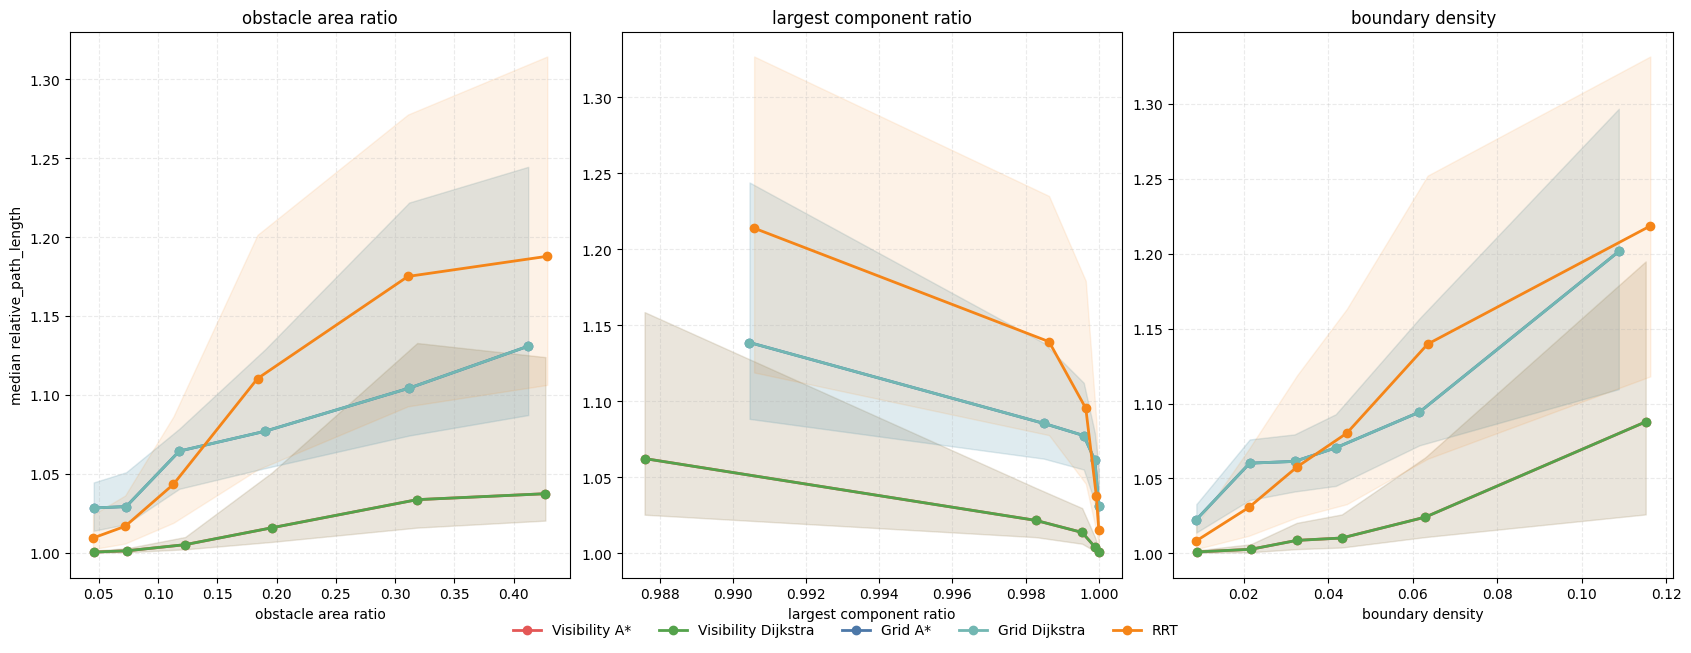

In [54]:
fig, axes = plt.subplots(1, quality_profile_metric_count, figsize=(5.6 * quality_profile_metric_count, 6.2), constrained_layout=True, squeeze=False)
axes = axes.ravel()

if QUALITY_PROFILE_METRICS and not quality_profiles_df.empty:
    for axis_index, metric in enumerate(QUALITY_PROFILE_METRICS):
        ax = axes[axis_index]
        metric_plot_df = quality_profiles_df.loc[quality_profiles_df['metric'] == metric].copy()
        for algorithm_id in plot_order:
            algo_df = metric_plot_df.loc[metric_plot_df['algorithm_id'] == algorithm_id].sort_values('metric_value')
            if algo_df.empty:
                continue

            x_values = algo_df['metric_value'].to_numpy()
            y_values = algo_df['median_relative_path_length'].to_numpy()
            lower_values = algo_df['q25_relative_path_length'].to_numpy()
            upper_values = algo_df['q75_relative_path_length'].to_numpy()
            color = ALGORITHM_COLORS[algorithm_id]

            ax.plot(
                x_values,
                y_values,
                marker='o',
                linewidth=2,
                color=color,
                label=ALGORITHM_LABELS.get(algorithm_id, algorithm_id),
            )
            ax.fill_between(x_values, lower_values, upper_values, color=color, alpha=0.10)

        ax.set_title(SCENE_METRIC_LABELS.get(metric, metric))
        ax.set_xlabel(SCENE_METRIC_LABELS.get(metric, metric))
        if axis_index == 0:
            ax.set_ylabel('median relative_path_length')
        ax.grid(alpha=0.25, linestyle='--')

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.04), ncol=min(5, len(handles)), frameon=False)
else:
    axes[0].axis('off')
    axes[0].text(0.5, 0.5, 'Недостаточно данных для quality-профилей', ha='center', va='center')

quality_profiles_figure_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_quality_profiles.png'
fig.savefig(quality_profiles_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', quality_metric_priority_path)
print('Saved:', quality_profiles_path)
print('Saved:', quality_profiles_figure_path)

with pd.option_context('display.max_columns', None, 'display.width', 2200):
    display(quality_metric_priority_df.head(6))

plt.show()

### Scatter-сравнение качества пути

Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_quality_algorithm_scatter.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_quality_algorithm_scatter.png


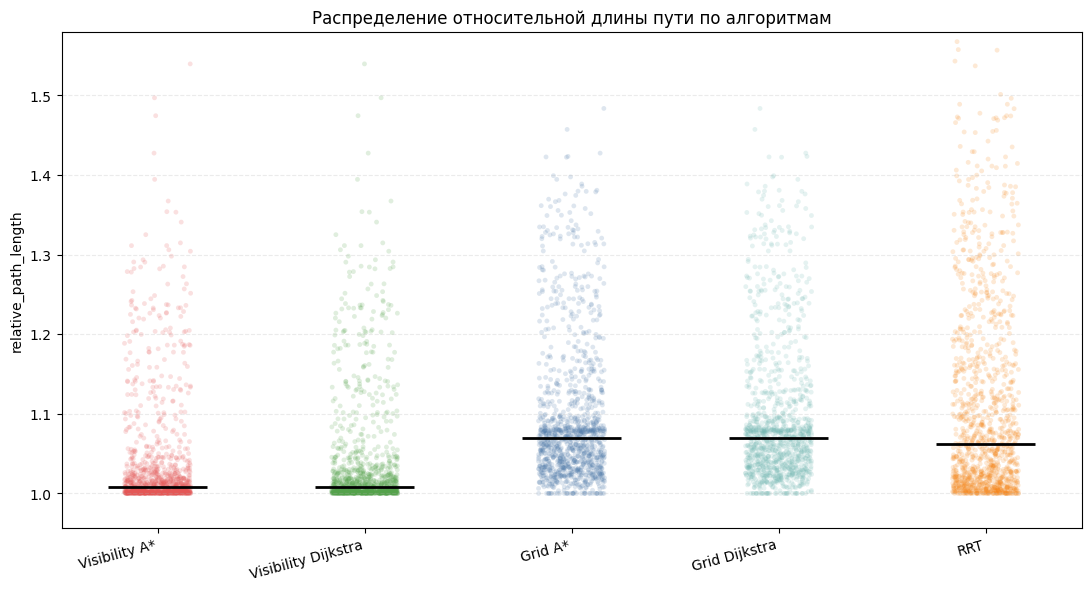

In [55]:
quality_scatter_frames = []
for algorithm_id, algorithm_df in quality_source_df.groupby('algorithm_id'):
    sample_size = min(len(algorithm_df), 1200)
    sample_df = algorithm_df.sample(sample_size, random_state=42).copy() if sample_size > 0 else algorithm_df.head(0).copy()
    if sample_df.empty:
        continue
    sample_df['algorithm_label'] = ALGORITHM_LABELS.get(algorithm_id, algorithm_id)
    quality_scatter_frames.append(sample_df[['algorithm_id', 'algorithm_label', 'relative_path_length']])

quality_algorithm_scatter_df = pd.concat(quality_scatter_frames, ignore_index=True) if quality_scatter_frames else pd.DataFrame(columns=['algorithm_id', 'algorithm_label', 'relative_path_length'])
quality_algorithm_scatter_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_quality_algorithm_scatter.csv'
quality_algorithm_scatter_df.to_csv(quality_algorithm_scatter_path, index=False)

fig, ax = plt.subplots(figsize=(10.8, 5.8), constrained_layout=True)
rng = np.random.default_rng(42)
for axis_index, algorithm_id in enumerate(plot_order):
    algo_df = quality_algorithm_scatter_df.loc[quality_algorithm_scatter_df['algorithm_id'] == algorithm_id].copy()
    if algo_df.empty:
        continue

    x_values = np.full(len(algo_df), axis_index, dtype=float) + rng.uniform(-0.16, 0.16, len(algo_df))
    y_values = algo_df['relative_path_length'].to_numpy()
    color = ALGORITHM_COLORS[algorithm_id]

    ax.scatter(x_values, y_values, s=12, alpha=0.18, color=color, edgecolors='none')
    ax.hlines(np.median(y_values), axis_index - 0.24, axis_index + 0.24, color='black', linewidth=2)

ax.set_xticks(range(len(plot_order)))
ax.set_xticklabels([ALGORITHM_LABELS.get(algorithm_id, algorithm_id) for algorithm_id in plot_order], rotation=15, ha='right')
ax.set_ylabel('relative_path_length')
ax.set_title('Распределение относительной длины пути по алгоритмам')
ax.grid(axis='y', alpha=0.25, linestyle='--')

if not quality_algorithm_scatter_df.empty:
    upper_limit = quality_algorithm_scatter_df['relative_path_length'].quantile(0.995)
    lower_limit = quality_algorithm_scatter_df['relative_path_length'].quantile(0.005)
    if pd.notna(lower_limit) and pd.notna(upper_limit) and upper_limit > lower_limit:
        margin = max(0.002, (upper_limit - lower_limit) * 0.08)
        ax.set_ylim(lower_limit - margin, upper_limit + margin)

quality_algorithm_scatter_figure_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_quality_algorithm_scatter.png'
fig.savefig(quality_algorithm_scatter_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', quality_algorithm_scatter_path)
print('Saved:', quality_algorithm_scatter_figure_path)

plt.show()

Для relative_path_length более высокие значения означают менее качественный путь. Поэтому положительные значения на правой heatmap отражают ухудшение качества при переходе к более сложным сценам, а отрицательные значения указывают на отсутствие заметной деградации или на слабую чувствительность алгоритма к соответствующей метрике.

## Дополнительные визуализации и итоговая интерпретация

В этой части добавлены более наглядные визуальные представления результатов: линейные профили по конфигам, круговые диаграммы исходов и победителей, ECDF-кривые, scatter-графики и итоговый текстовый вывод.

Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_config_lines.png


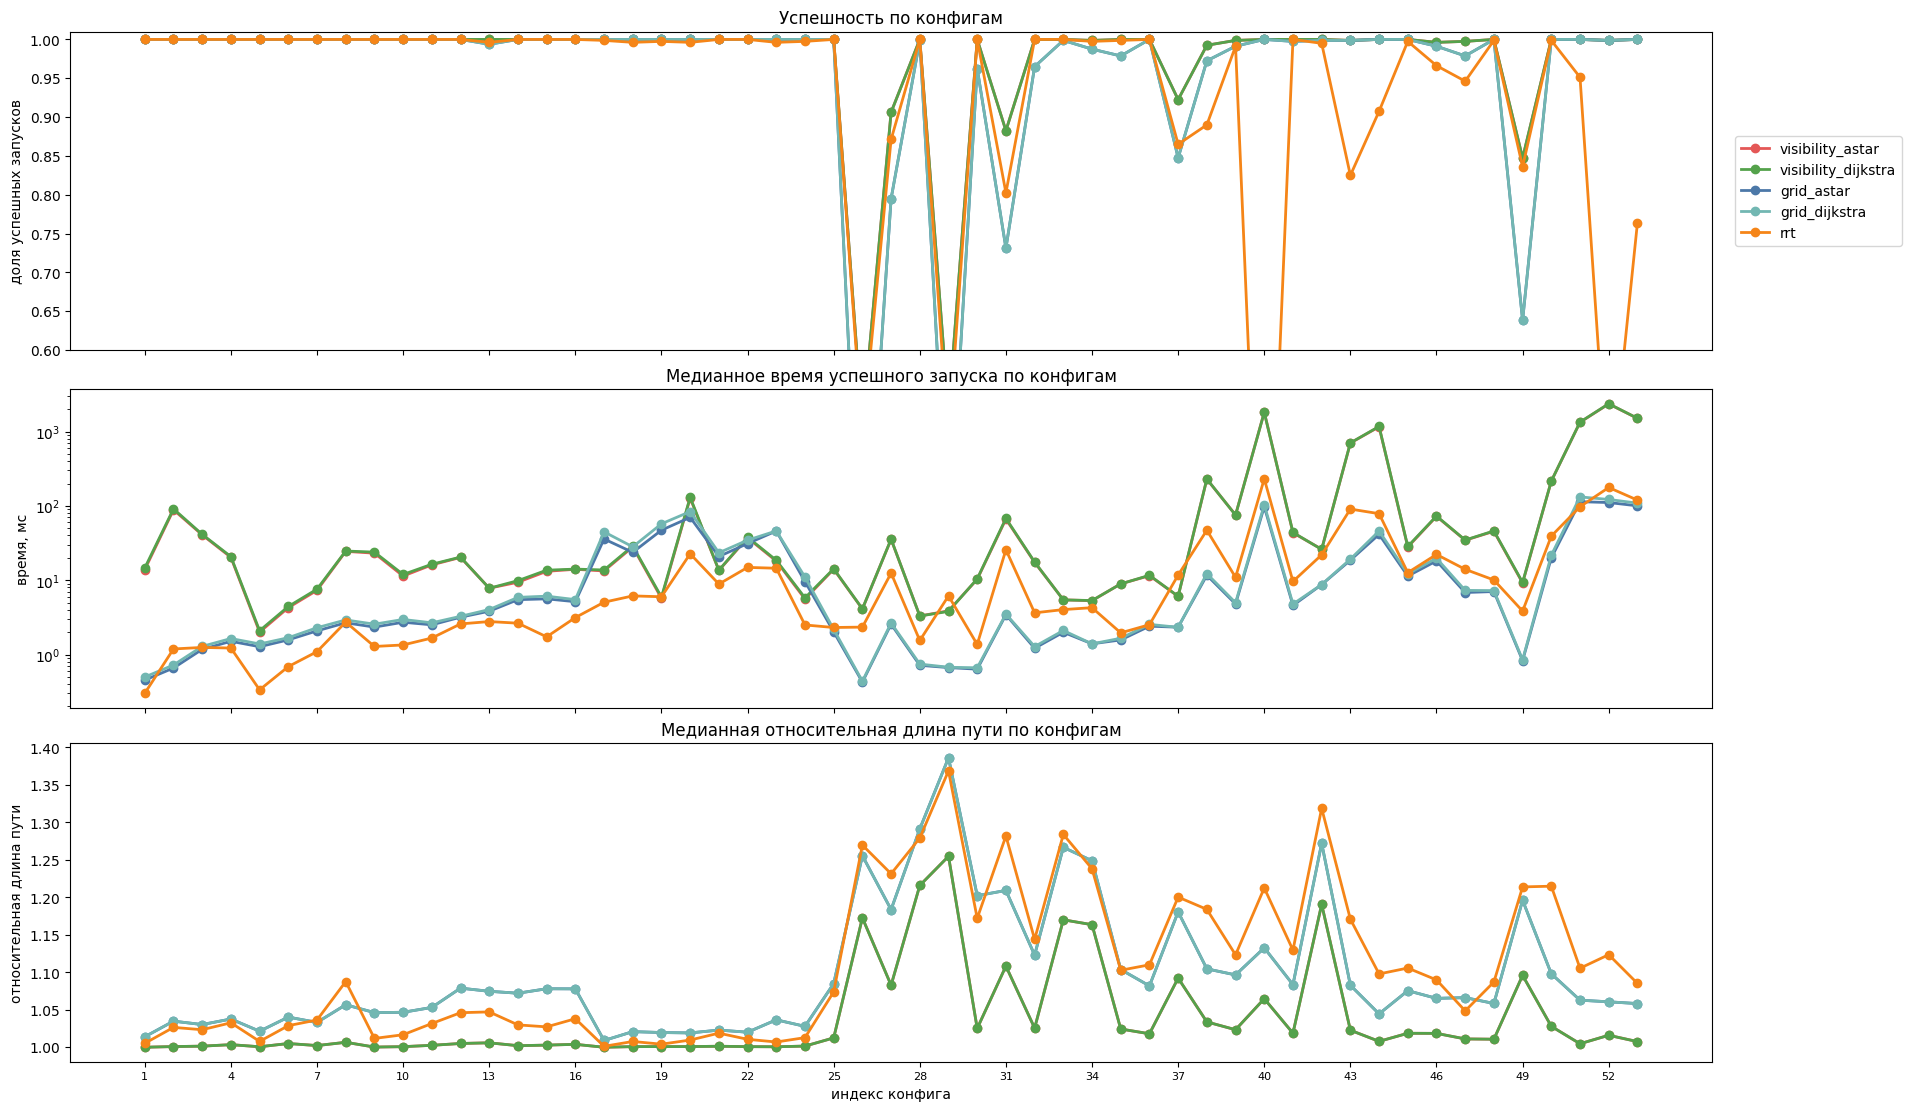

In [56]:
fig, axes = plt.subplots(3, 1, figsize=(19, 11), constrained_layout=True, sharex=True)

for algorithm_id in plot_order:
    algo_success_df = config_success_df.loc[config_success_df['algorithm_id'] == algorithm_id].sort_values('config_index')
    axes[0].plot(algo_success_df['config_index'], algo_success_df['success_rate'], marker='o', linewidth=2, label=algorithm_id, color=ALGORITHM_COLORS[algorithm_id])
axes[0].set_title('Успешность по конфигам')
axes[0].set_ylabel('доля успешных запусков')
axes[0].set_ylim(0.6, 1.01)
axes[0].legend(loc='center left', bbox_to_anchor=(1.01, 0.5))

for algorithm_id in plot_order:
    algo_runtime_df = config_runtime_df.loc[config_runtime_df['algorithm_id'] == algorithm_id].sort_values('config_index')
    axes[1].plot(algo_runtime_df['config_index'], algo_runtime_df['median_runtime_success_ms'], marker='o', linewidth=2, label=algorithm_id, color=ALGORITHM_COLORS[algorithm_id])
axes[1].set_title('Медианное время успешного запуска по конфигам')
axes[1].set_ylabel('время, мс')
axes[1].set_yscale('log')

for algorithm_id in plot_order:
    algo_quality_df = config_quality_df.loc[config_quality_df['algorithm_id'] == algorithm_id].sort_values('config_index')
    axes[2].plot(algo_quality_df['config_index'], algo_quality_df['median_relative_path_length'], marker='o', linewidth=2, label=algorithm_id, color=ALGORITHM_COLORS[algorithm_id])
axes[2].set_title('Медианная относительная длина пути по конфигам')
axes[2].set_ylabel('относительная длина пути')
axes[2].set_xlabel('индекс конфига')

for ax in axes:
    ax.set_xticks(range(1, int(config_success_df['config_index'].max()) + 1, 3))
    ax.tick_params(axis='x', labelrotation=0, labelsize=8)

config_lines_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_config_lines.png'
fig.savefig(config_lines_path, dpi=180, bbox_inches='tight')
print('Saved:', config_lines_path)
plt.show()

Линейные графики показывают, на каких конфигурациях алгоритмы начинают резко расходиться. Это полезно для выделения семейств сцен, где преимущества конкретного метода становятся критически важными.

Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_outcome_donuts.png


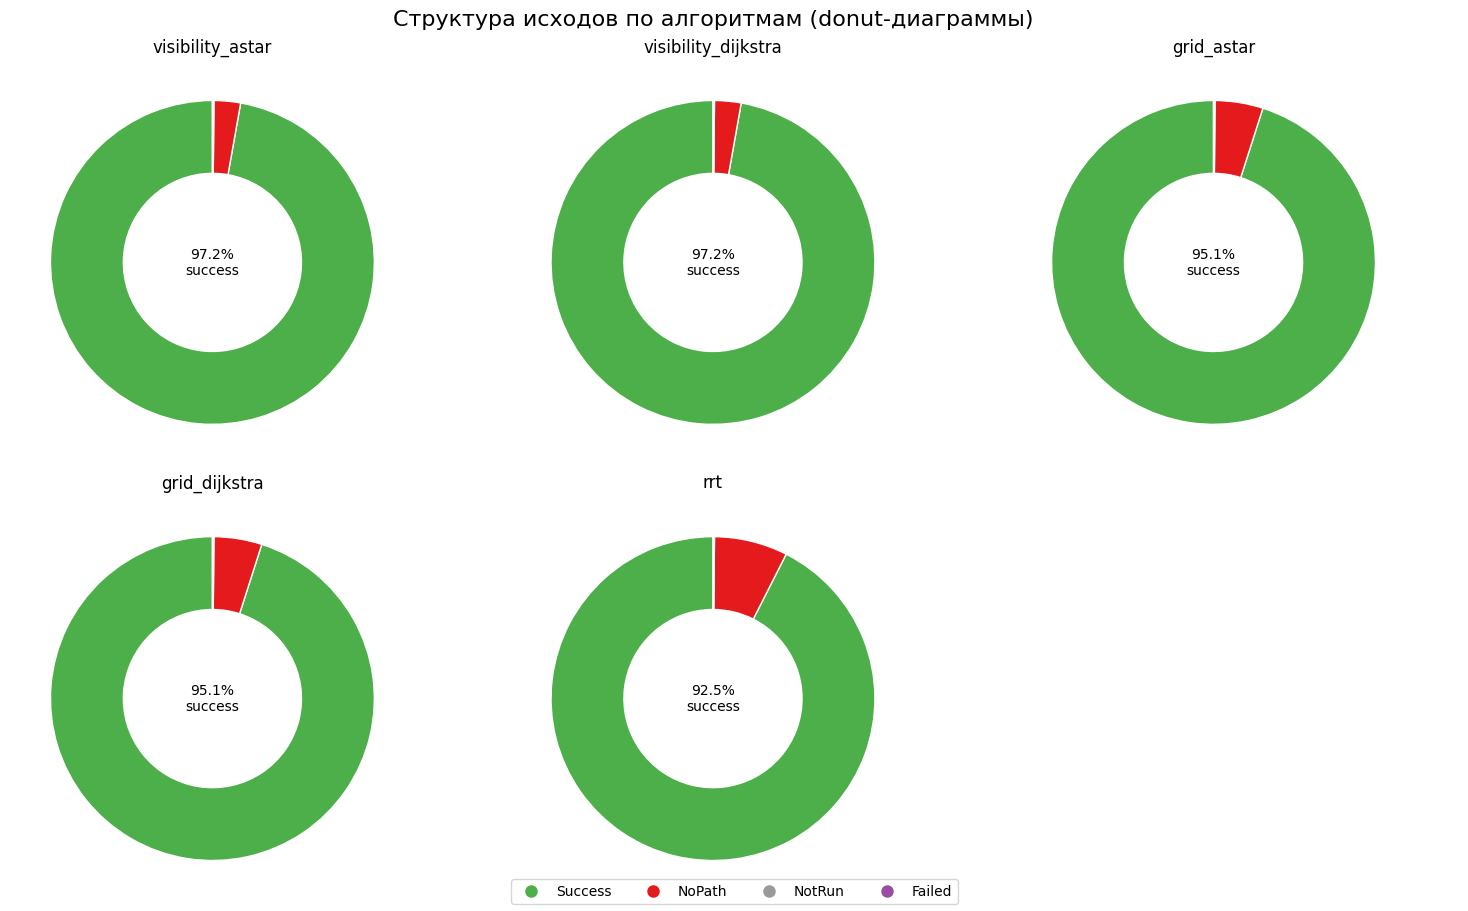

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
axes = axes.ravel()
status_colors = {'Success': '#4daf4a', 'NoPath': '#e41a1c', 'NotRun': '#999999', 'Failed': '#984ea3'}

for axis_index, algorithm_id in enumerate(plot_order):
    ax = axes[axis_index]
    status_counts = status_counts_df.loc[algorithm_id, STATUS_ORDER]
    labels = [label for label in STATUS_ORDER if status_counts[label] > 0]
    values = [status_counts[label] for label in labels]
    colors = [status_colors[label] for label in labels]

    ax.pie(
        values,
        startangle=90,
        colors=colors,
        wedgeprops={'width': 0.45, 'edgecolor': 'white'}
    )
    ax.set_title(algorithm_id)
    ax.text(
        0, 0,
        f"{status_counts['Success'] / status_counts.sum():.1%}\nsuccess",
        ha='center',
        va='center',
        fontsize=10
    )

axes[-1].axis('off')
legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=status_colors[label], markersize=10)
    for label in status_colors
]
fig.legend(legend_handles, list(status_colors.keys()), loc='lower center', ncol=4)
fig.suptitle('Структура исходов по алгоритмам (donut-диаграммы)', fontsize=16)

outcome_donuts_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_outcome_donuts.png'
fig.savefig(outcome_donuts_path, dpi=180, bbox_inches='tight')
print('Saved:', outcome_donuts_path)
plt.show()

Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_winner_pies.png


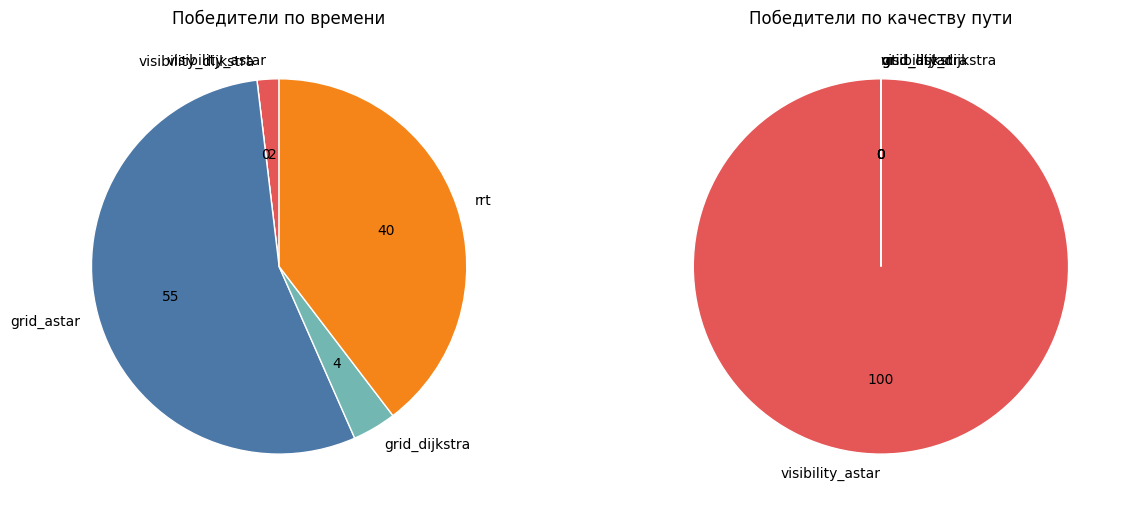

In [58]:
runtime_winner_counts = config_runtime_winners_df['algorithm_id'].value_counts().reindex(plot_order, fill_value=0)
quality_winner_counts = config_quality_winners_df['algorithm_id'].value_counts().reindex(plot_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, counts, title in [
    (axes[0], runtime_winner_counts, 'Победители по времени'),
    (axes[1], quality_winner_counts, 'Победители по качеству пути'),
]:
    labels = counts.index.tolist()
    values = counts.values
    colors = [ALGORITHM_COLORS[label] for label in labels]
    ax.pie(values, labels=labels, autopct='%1.0f', startangle=90, colors=colors, wedgeprops={'edgecolor': 'white'})
    ax.set_title(title)

winner_pies_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_winner_pies.png'
fig.savefig(winner_pies_path, dpi=180, bbox_inches='tight')
print('Saved:', winner_pies_path)
plt.show()

Один алгоритм может доминировать по времени, другой - по качеству пути. Поэтому итоговая рекомендация должна учитывать компромисс, а не только один показатель.

Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_ecdf.png


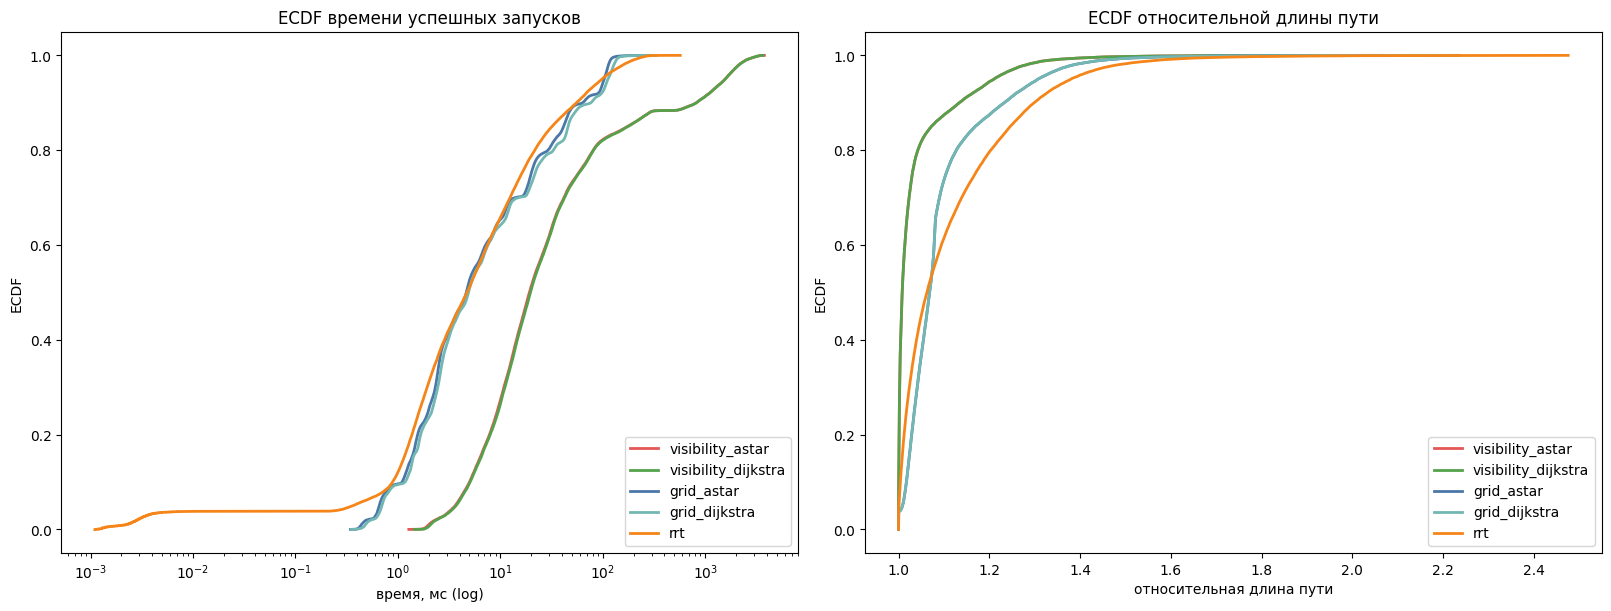

In [59]:
def build_ecdf(values):
    values = np.sort(np.asarray(values, dtype=float))
    y = np.arange(1, len(values) + 1) / len(values)
    return values, y

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
for algorithm_id in plot_order:
    runtime_values = SUCCESS_RUNS_DF.loc[SUCCESS_RUNS_DF['algorithm_id'] == algorithm_id, 'runtime_ms'].values
    x, y = build_ecdf(runtime_values)
    axes[0].plot(x, y, linewidth=2, label=algorithm_id, color=ALGORITHM_COLORS[algorithm_id])
axes[0].set_xscale('log')
axes[0].set_title('ECDF времени успешных запусков')
axes[0].set_xlabel('время, мс (log)')
axes[0].set_ylabel('ECDF')
axes[0].legend(loc='lower right')

for algorithm_id in plot_order:
    quality_values = SUCCESS_RUNS_DF.loc[SUCCESS_RUNS_DF['algorithm_id'] == algorithm_id, 'relative_path_length'].values
    x, y = build_ecdf(quality_values)
    axes[1].plot(x, y, linewidth=2, label=algorithm_id, color=ALGORITHM_COLORS[algorithm_id])
axes[1].set_title('ECDF относительной длины пути')
axes[1].set_xlabel('относительная длина пути')
axes[1].set_ylabel('ECDF')
axes[1].legend(loc='lower right')

ecdf_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_ecdf.png'
fig.savefig(ecdf_path, dpi=180, bbox_inches='tight')
print('Saved:', ecdf_path)
plt.show()

ECDF-графики показывают всю функцию распределения. По ним можно судить о стабильности преимущества алгоритма, а не только о точечных статистиках вроде медианы.

Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_runtime_quality_scatter.png


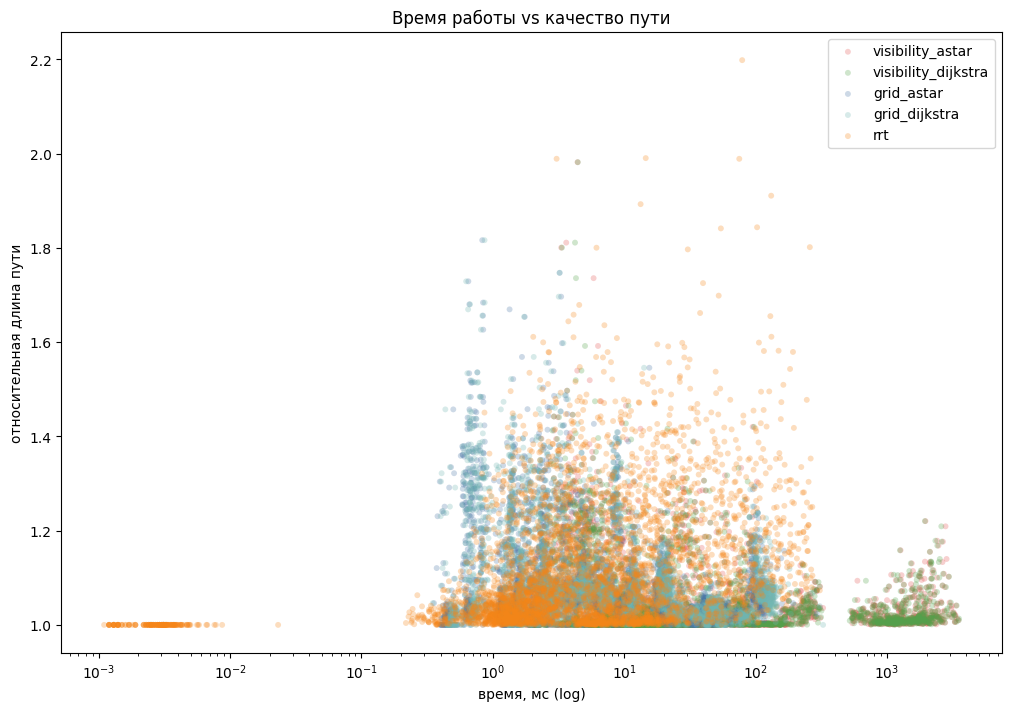

In [60]:
scatter_sample_df = SUCCESS_RUNS_DF.groupby('algorithm_id', group_keys=False).apply(lambda df: df.sample(min(len(df), 4000), random_state=42)).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)
for algorithm_id in plot_order:
    algo_df = scatter_sample_df.loc[scatter_sample_df['algorithm_id'] == algorithm_id]
    ax.scatter(
        algo_df['runtime_ms'],
        algo_df['relative_path_length'],
        s=18,
        alpha=0.28,
        color=ALGORITHM_COLORS[algorithm_id],
        label=algorithm_id,
        edgecolors='none',
    )
ax.set_xscale('log')
ax.set_title('Время работы vs качество пути')
ax.set_xlabel('время, мс (log)')
ax.set_ylabel('относительная длина пути')
ax.legend(loc='upper right')

runtime_quality_scatter_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_runtime_quality_scatter.png'
fig.savefig(runtime_quality_scatter_path, dpi=180, bbox_inches='tight')
print('Saved:', runtime_quality_scatter_path)
plt.show()

Scatter-представление хорошо показывает пространство trade-off между скоростью и качеством маршрута. По нему видно, какие алгоритмы ближе к быстрой, а какие - к качественной части фронта решений.

### Итоговые таблицы по алгоритмам

In [61]:
summary_rows = []
for algorithm_id in plot_order:
    algo_corr_df = algorithm_metric_correlations_df.loc[
        algorithm_metric_correlations_df['algorithm_id'] == algorithm_id
    ].copy()

    top_success_row = algo_corr_df.iloc[algo_corr_df['success_spearman'].abs().argmax()]
    top_runtime_row = algo_corr_df.iloc[algo_corr_df['runtime_spearman'].abs().argmax()]
    top_quality_row = algo_corr_df.iloc[algo_corr_df['quality_spearman'].abs().argmax()]

    summary_rows.append({
        'algorithm_id': algorithm_id,
        'top_success_metric': SHORT_METRIC_LABELS[top_success_row['metric']],
        'top_success_corr': top_success_row['success_spearman'],
        'top_runtime_metric': SHORT_METRIC_LABELS[top_runtime_row['metric']],
        'top_runtime_corr': top_runtime_row['runtime_spearman'],
        'top_quality_metric': SHORT_METRIC_LABELS[top_quality_row['metric']],
        'top_quality_corr': top_quality_row['quality_spearman'],
    })

algorithm_summary_metrics_df = pd.DataFrame(summary_rows)

best_success_algorithm = algorithm_overview_df['success_rate_executed'].idxmax()
weakest_success_algorithm = algorithm_overview_df['success_rate_executed'].idxmin()
fastest_success_algorithm = algorithm_overview_df['median_runtime_success_ms'].idxmin()
best_quality_algorithm = algorithm_overview_df['median_relative_path_length'].idxmin()

algorithm_key_results_df = pd.DataFrame([
    {
        'criterion': 'best_success_rate',
        'algorithm_id': best_success_algorithm,
        'value': algorithm_overview_df.loc[best_success_algorithm, 'success_rate_executed'],
    },
    {
        'criterion': 'weakest_success_rate',
        'algorithm_id': weakest_success_algorithm,
        'value': algorithm_overview_df.loc[weakest_success_algorithm, 'success_rate_executed'],
    },
    {
        'criterion': 'fastest_successful_runtime',
        'algorithm_id': fastest_success_algorithm,
        'value': algorithm_overview_df.loc[fastest_success_algorithm, 'median_runtime_success_ms'],
    },
    {
        'criterion': 'best_median_path_quality',
        'algorithm_id': best_quality_algorithm,
        'value': algorithm_overview_df.loc[best_quality_algorithm, 'median_relative_path_length'],
    },
])
algorithm_key_results_df['algorithm_label'] = algorithm_key_results_df['algorithm_id'].map(ALGORITHM_LABELS)

algorithm_summary_metrics_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_summary_metrics.csv'
algorithm_key_results_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_key_results.csv'
algorithm_summary_metrics_df.to_csv(algorithm_summary_metrics_path, index=False)
algorithm_key_results_df.to_csv(algorithm_key_results_path, index=False)

print('Saved:', algorithm_summary_metrics_path)
print('Saved:', algorithm_key_results_path)

display(algorithm_key_results_df)
display(algorithm_summary_metrics_df)

Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_summary_metrics.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_algorithm_key_results.csv


,criterion,algorithm_id,value,algorithm_label
0,best_success_rate,visibility_astar,0.973522,Visibility A*
1,weakest_success_rate,rrt,0.926707,RRT
2,fastest_successful_runtime,grid_astar,4.656100,Grid A*
3,best_median_path_quality,visibility_astar,1.007930,Visibility A*


,algorithm_id,top_success_metric,top_success_corr,top_runtime_metric,top_runtime_corr,top_quality_metric,top_quality_corr
0,visibility_astar,largest_component_ratio,0.269994,scene_obstacle_count,0.908299,obstacle_area_ratio,0.813448
1,visibility_dijkstra,largest_component_ratio,0.269994,scene_obstacle_count,0.905481,obstacle_area_ratio,0.813448
2,grid_astar,largest_component_ratio,0.345807,scene_direct_distance,0.975386,obstacle_area_ratio,0.722728
3,grid_dijkstra,largest_component_ratio,0.345807,scene_direct_distance,0.972314,obstacle_area_ratio,0.722728
4,rrt,largest_component_ratio,0.365617,scene_obstacle_count,0.695521,obstacle_area_ratio,0.737049


    Итоговые таблицы по алгоритмам сводят разрозненные наблюдения в один компактный слой для выводов. После этого к частным графикам уже можно возвращаться только как к иллюстрациям, а не как к основному источнику аргументов.
    


Итоговая интерпретация: универсально лучшего алгоритма по всем критериям нет. Если важнее надежность и качество пути, предпочтительны visibility-подходы; если приоритетом является скорость, наиболее выгоден RRT; grid-алгоритмы можно рассматривать как компромиссный вариант.

## Прогнозирование предпочтительного алгоритма по характеристикам сцены

Финальный ML-блок отвечает на практический вопрос: можно ли по метрикам сцены заранее предсказать, какой алгоритм окажется предпочтительным. Целевая переменная формируется через score, в котором успешность имеет приоритет, а затем учитываются время, качество пути и устойчивость компромисса.



### Импорты и классы алгоритмов

Сначала подключаются только те инструменты `scikit-learn`, которые действительно используются в компактной версии модели.



In [62]:
from itertools import product

from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

RECOMMENDATION_ALGORITHMS = ['visibility_astar', 'grid_astar', 'rrt']
GRAPH_ALGORITHMS = ['visibility_astar', 'grid_astar']
RRT_ALGORITHM = 'rrt'
GRAPH_CLASS_LABEL = 'graph'

RECOMMENDATION_LABELS = {algorithm_id: ALGORITHM_LABELS[algorithm_id] for algorithm_id in RECOMMENDATION_ALGORITHMS}
SCENE_KEY_COLUMNS = ['config_index', 'scene_id']

### Признаки модели

Ниже задаются три уровня признаков: исходные scene-level характеристики, инженерные преобразования и компактное подмножество признаков для быстрой итоговой модели.



In [63]:
RAW_SCENE_FEATURE_COLUMNS = [
    'scene_metric_obstacle_area_ratio',
    'scene_metric_boundary_density',
    'scene_metric_cell_density_cv',
    'scene_metric_radii_cv',
    'scene_metric_clearance',
    'scene_metric_largest_component_ratio',
    'scene_obstacle_count',
    'scene_width',
    'scene_height',
    'scene_area',
    'scene_direct_distance',
    'scene_start_x',
    'scene_start_y',
    'scene_goal_x',
    'scene_goal_y',
    'config_start_goal_min_distance',
]

ENGINEERED_ML_FEATURE_COLUMNS = [
    'scene_obstacle_density',
    'scene_direct_distance_ratio',
    'scene_clearance_component_interaction',
    'scene_boundary_area_interaction',
    'scene_obstacle_clearance_ratio',
    'scene_radii_cell_interaction',
    'scene_obstacle_count_log',
    'scene_area_log',
    'scene_direct_distance_log',
    'scene_aspect_ratio',
    'scene_start_x_norm',
    'scene_start_y_norm',
    'scene_goal_x_norm',
    'scene_goal_y_norm',
    'scene_start_goal_dx_norm',
    'scene_start_goal_dy_norm',
    'scene_start_border_distance_norm',
    'scene_goal_border_distance_norm',
    'scene_start_center_distance_norm',
    'scene_goal_center_distance_norm',
    'scene_direct_distance_min_ratio',
    'scene_component_gap',
    'scene_distance_clearance_ratio',
    'scene_obstacle_area_per_obstacle',
    'scene_obstacle_count_sqrt_area_ratio',
    'scene_border_distance_gap_norm',
    'scene_center_distance_gap_norm',
    'scene_axis_balance_norm',
    'scene_route_pressure_index',
    'scene_clearance_log',
    'scene_goal_start_mean_border_norm',
]



In [64]:
ML_FEATURE_COLUMNS = [
    'scene_metric_obstacle_area_ratio',
    'scene_metric_boundary_density',
    'scene_metric_cell_density_cv',
    'scene_metric_radii_cv',
    'scene_metric_clearance',
    'scene_metric_largest_component_ratio',
    'scene_obstacle_count',
    'scene_width',
    'scene_height',
    'scene_area',
    'scene_direct_distance',
    *ENGINEERED_ML_FEATURE_COLUMNS,
]

COMPACT_ML_FEATURE_COLUMNS = [
    'scene_metric_obstacle_area_ratio',
    'scene_metric_boundary_density',
    'scene_metric_cell_density_cv',
    'scene_metric_radii_cv',
    'scene_metric_clearance',
    'scene_metric_largest_component_ratio',
    'scene_obstacle_count',
    'scene_area',
    'scene_direct_distance',
    'scene_obstacle_density',
    'scene_direct_distance_ratio',
    'scene_clearance_component_interaction',
    'scene_boundary_area_interaction',
    'scene_obstacle_clearance_ratio',
    'scene_radii_cell_interaction',
    'scene_obstacle_count_log',
    'scene_aspect_ratio',
    'scene_start_goal_dx_norm',
    'scene_start_goal_dy_norm',
    'scene_start_border_distance_norm',
    'scene_goal_border_distance_norm',
    'scene_direct_distance_min_ratio',
]

ML_FEATURE_SET_MAP = {
    'all_features': ML_FEATURE_COLUMNS,
    'compact_features': COMPACT_ML_FEATURE_COLUMNS,
}

ML_FEATURE_SET_LABELS = {
    'all_features': 'all engineered features',
    'compact_features': 'compact generalization-oriented subset',
}

ML_FEATURE_LABELS = {
    'scene_metric_obstacle_area_ratio': 'obstacle area ratio',
    'scene_metric_boundary_density': 'boundary density',
    'scene_metric_cell_density_cv': 'cell density CV',
    'scene_metric_radii_cv': 'radii CV',
    'scene_metric_clearance': 'clearance',
    'scene_metric_largest_component_ratio': 'largest component ratio',
    'scene_obstacle_count': 'obstacle count',
    'scene_width': 'scene width',
    'scene_height': 'scene height',
    'scene_area': 'scene area',
    'scene_direct_distance': 'direct distance',
    'scene_obstacle_density': 'obstacle density',
    'scene_direct_distance_ratio': 'distance / sqrt(area)',
    'scene_clearance_component_interaction': 'clearance * component',
    'scene_boundary_area_interaction': 'boundary * area ratio',
    'scene_obstacle_clearance_ratio': 'area ratio / clearance',
    'scene_radii_cell_interaction': 'radii CV * cell CV',
    'scene_obstacle_count_log': 'log obstacle count',
    'scene_area_log': 'log scene area',
    'scene_direct_distance_log': 'log direct distance',
    'scene_aspect_ratio': 'scene aspect ratio',
    'scene_start_x_norm': 'start x / width',
    'scene_start_y_norm': 'start y / height',
    'scene_goal_x_norm': 'goal x / width',
    'scene_goal_y_norm': 'goal y / height',
    'scene_start_goal_dx_norm': '|goal x - start x| / width',
    'scene_start_goal_dy_norm': '|goal y - start y| / height',
    'scene_start_border_distance_norm': 'start border distance',
    'scene_goal_border_distance_norm': 'goal border distance',
    'scene_start_center_distance_norm': 'start center distance',
    'scene_goal_center_distance_norm': 'goal center distance',
    'scene_direct_distance_min_ratio': 'distance / min required distance',
    'scene_component_gap': '1 - largest component ratio',
    'scene_distance_clearance_ratio': 'distance / clearance',
    'scene_obstacle_area_per_obstacle': 'area ratio / obstacle count',
    'scene_obstacle_count_sqrt_area_ratio': 'obstacle count / sqrt(area)',
    'scene_border_distance_gap_norm': '|goal border - start border|',
    'scene_center_distance_gap_norm': '|goal center - start center|',
    'scene_axis_balance_norm': '|dx_norm - dy_norm|',
    'scene_route_pressure_index': 'distance ratio * obstacle density',
    'scene_clearance_log': 'log clearance',
    'scene_goal_start_mean_border_norm': 'mean border distance',
}

### Параметры score и обучения

В этом блоке фиксируются веса score, параметры компактного перебора и базовые настройки выборки. Сетка оставлена небольшой, чтобы раздел оставался воспроизводимым и не разрастался вычислительно.



In [65]:
EPSILON = 1e-9

SCORE_ALPHA = 2.0
FAILURE_SCORE_PENALTY = 1.0

DEFAULT_SCORE_BETA = 0.60
DEFAULT_SCORE_GAMMA = 0.90
DEFAULT_SCORE_DELTA = 0.40

SCORE_BETA_GRID = [0.45, 0.60, 0.75]
SCORE_GAMMA_GRID = [0.75, 0.90, 1.05]
SCORE_DELTA_GRID = [0.40, 0.80]

QUALITY_RUNTIME_TOLERANCE = 0.15
TARGET_MIN_CLASS_SHARE = 0.03
AUTOTUNE_CANDIDATE_LIMIT = 8
AUTOTUNE_PROXY_TEST_SIZE = 0.25
AUTOTUNE_MIN_CLASS_COUNT = 250
USE_AUTOTUNED_SCORE_PARAMS = True

MULTICLASS_BIAS_GRID = [0.90, 1.00, 1.10]

RANDOM_STATE = 42
TEST_SIZE = 0.20
VALIDATION_SIZE = 0.20
MODEL_OUTPUT_PREFIX = f'{DATASET_PREFIX}_ml_algorithm_recommendation'

SELECTED_ML_FEATURE_SET = 'compact_features'
SELECTED_ML_FEATURE_COLUMNS = COMPACT_ML_FEATURE_COLUMNS.copy()

### Формирование признаков, score и целевой переменной

На этом этапе из общего run-level датасета выделяется отдельная выборка для рекомендации алгоритма. Затем к сценам добавляются инженерные признаки, а для каждой сцены рассчитывается score по всем алгоритмам-кандидатам.



### Исходная таблица для рекомендаций

Сначала проверяется, что в рабочем датасете присутствуют все необходимые scene-level колонки, а затем собираются две таблицы: run-level таблица для расчета score и scene-level таблица с признаками среды.



In [66]:
missing_scene_feature_columns = [column for column in RAW_SCENE_FEATURE_COLUMNS if column not in analysis_run_df.columns]
if missing_scene_feature_columns:
    raise KeyError(f'Missing raw scene feature columns in analysis_run_df: {missing_scene_feature_columns}')

recommendation_source_columns = [
    *SCENE_KEY_COLUMNS,
    'config_name',
    'algorithm_id',
    'algorithm_status',
    'algorithm_was_executed',
    'path_found',
    'runtime_ms',
    'relative_path_length',
]

recommendation_source_df = (
    analysis_run_df.loc[
        analysis_run_df['algorithm_id'].isin(RECOMMENDATION_ALGORITHMS)
        & analysis_run_df['algorithm_was_executed'].fillna(False),
        recommendation_source_columns,
    ]
    .copy()
    .sort_values([*SCENE_KEY_COLUMNS, 'algorithm_id'])
    .reset_index(drop=True)
)

if recommendation_source_df.empty:
    raise ValueError('Recommendation source dataframe is empty. Check filters and dataset loading.')

scene_algorithm_duplicates = recommendation_source_df.duplicated(subset=[*SCENE_KEY_COLUMNS, 'algorithm_id']).sum()
if scene_algorithm_duplicates > 0:
    raise ValueError(f'Found duplicated scene/algorithm rows in recommendation_source_df: {scene_algorithm_duplicates}')

scene_feature_source_columns = [*SCENE_KEY_COLUMNS, 'config_name', *RAW_SCENE_FEATURE_COLUMNS]
scene_feature_df = (
    analysis_run_df[scene_feature_source_columns]
    .drop_duplicates(subset=[*SCENE_KEY_COLUMNS, 'config_name'])
    .reset_index(drop=True)
)

if scene_feature_df.empty:
    raise ValueError('Scene feature dataframe is empty. Check analysis_run_df construction.')

### Инженерные признаки сцены

Инженерные признаки описывают не только размер и плотность сцены, но и взаимное расположение старта и цели, граничные эффекты и комбинированные индикаторы сложности.



In [67]:
def minmax_normalize(series: pd.Series, default_value: float = 0.0) -> pd.Series:
    numeric_series = pd.to_numeric(series, errors='coerce')
    if numeric_series.dropna().empty:
        return pd.Series(default_value, index=series.index, dtype=float)

    min_value = float(numeric_series.min(skipna=True))
    max_value = float(numeric_series.max(skipna=True))
    if not np.isfinite(min_value) or not np.isfinite(max_value) or np.isclose(min_value, max_value):
        return pd.Series(default_value, index=series.index, dtype=float)

    return ((numeric_series - min_value) / (max_value - min_value)).clip(lower=0.0, upper=1.0)

In [68]:
def add_engineered_ml_features(scene_df: pd.DataFrame) -> pd.DataFrame:
    feature_df = scene_df.copy()

    scene_area = pd.to_numeric(feature_df['scene_area'], errors='coerce').fillna(0.0).clip(lower=0.0)
    scene_width = pd.to_numeric(feature_df['scene_width'], errors='coerce').fillna(0.0).clip(lower=0.0)
    scene_height = pd.to_numeric(feature_df['scene_height'], errors='coerce').fillna(0.0).clip(lower=0.0)
    direct_distance = pd.to_numeric(feature_df['scene_direct_distance'], errors='coerce').fillna(0.0).clip(lower=0.0)
    obstacle_count = pd.to_numeric(feature_df['scene_obstacle_count'], errors='coerce').fillna(0.0).clip(lower=0.0)

    obstacle_area_ratio = pd.to_numeric(feature_df['scene_metric_obstacle_area_ratio'], errors='coerce').fillna(0.0).clip(lower=0.0)
    boundary_density = pd.to_numeric(feature_df['scene_metric_boundary_density'], errors='coerce').fillna(0.0).clip(lower=0.0)
    cell_density_cv = pd.to_numeric(feature_df['scene_metric_cell_density_cv'], errors='coerce').fillna(0.0).clip(lower=0.0)
    radii_cv = pd.to_numeric(feature_df['scene_metric_radii_cv'], errors='coerce').fillna(0.0).clip(lower=0.0)
    clearance = pd.to_numeric(feature_df['scene_metric_clearance'], errors='coerce').fillna(0.0).clip(lower=0.0)
    largest_component_ratio = pd.to_numeric(feature_df['scene_metric_largest_component_ratio'], errors='coerce').fillna(0.0).clip(lower=0.0)

    start_x = pd.to_numeric(feature_df['scene_start_x'], errors='coerce').fillna(0.0).clip(lower=0.0)
    start_y = pd.to_numeric(feature_df['scene_start_y'], errors='coerce').fillna(0.0).clip(lower=0.0)
    goal_x = pd.to_numeric(feature_df['scene_goal_x'], errors='coerce').fillna(0.0).clip(lower=0.0)
    goal_y = pd.to_numeric(feature_df['scene_goal_y'], errors='coerce').fillna(0.0).clip(lower=0.0)
    config_start_goal_min_distance = pd.to_numeric(feature_df['config_start_goal_min_distance'], errors='coerce').fillna(0.0).clip(lower=0.0)

    sqrt_area = np.sqrt(np.clip(scene_area, EPSILON, None))
    min_scene_side = np.minimum(scene_width, scene_height).clip(lower=EPSILON)
    half_width = scene_width / 2.0
    half_height = scene_height / 2.0

    feature_df['scene_obstacle_density'] = obstacle_count / np.clip(scene_area, EPSILON, None)
    feature_df['scene_direct_distance_ratio'] = direct_distance / sqrt_area
    feature_df['scene_clearance_component_interaction'] = clearance * largest_component_ratio
    feature_df['scene_boundary_area_interaction'] = boundary_density * obstacle_area_ratio
    feature_df['scene_obstacle_clearance_ratio'] = obstacle_area_ratio / np.clip(clearance, EPSILON, None)
    feature_df['scene_radii_cell_interaction'] = radii_cv * cell_density_cv
    feature_df['scene_obstacle_count_log'] = np.log1p(obstacle_count)
    feature_df['scene_area_log'] = np.log1p(scene_area)
    feature_df['scene_direct_distance_log'] = np.log1p(direct_distance)
    feature_df['scene_aspect_ratio'] = np.maximum(scene_width, scene_height) / min_scene_side

    feature_df['scene_start_x_norm'] = start_x / np.clip(scene_width, EPSILON, None)
    feature_df['scene_start_y_norm'] = start_y / np.clip(scene_height, EPSILON, None)
    feature_df['scene_goal_x_norm'] = goal_x / np.clip(scene_width, EPSILON, None)
    feature_df['scene_goal_y_norm'] = goal_y / np.clip(scene_height, EPSILON, None)
    feature_df['scene_start_goal_dx_norm'] = np.abs(goal_x - start_x) / np.clip(scene_width, EPSILON, None)
    feature_df['scene_start_goal_dy_norm'] = np.abs(goal_y - start_y) / np.clip(scene_height, EPSILON, None)

    start_border_distance = np.minimum.reduce([
        start_x,
        np.clip(scene_width - start_x, 0.0, None),
        start_y,
        np.clip(scene_height - start_y, 0.0, None),
    ])
    goal_border_distance = np.minimum.reduce([
        goal_x,
        np.clip(scene_width - goal_x, 0.0, None),
        goal_y,
        np.clip(scene_height - goal_y, 0.0, None),
    ])
    start_center_distance = np.sqrt((start_x - half_width) ** 2 + (start_y - half_height) ** 2)
    goal_center_distance = np.sqrt((goal_x - half_width) ** 2 + (goal_y - half_height) ** 2)

    feature_df['scene_start_border_distance_norm'] = start_border_distance / min_scene_side
    feature_df['scene_goal_border_distance_norm'] = goal_border_distance / min_scene_side
    feature_df['scene_start_center_distance_norm'] = start_center_distance / sqrt_area
    feature_df['scene_goal_center_distance_norm'] = goal_center_distance / sqrt_area
    feature_df['scene_direct_distance_min_ratio'] = direct_distance / np.clip(config_start_goal_min_distance, 1.0, None)

    feature_df['scene_component_gap'] = (1.0 - largest_component_ratio).clip(lower=0.0)
    feature_df['scene_distance_clearance_ratio'] = direct_distance / np.clip(clearance, EPSILON, None)
    feature_df['scene_obstacle_area_per_obstacle'] = obstacle_area_ratio / np.clip(obstacle_count, 1.0, None)
    feature_df['scene_obstacle_count_sqrt_area_ratio'] = obstacle_count / np.clip(sqrt_area, 1.0, None)
    feature_df['scene_border_distance_gap_norm'] = np.abs(
        feature_df['scene_goal_border_distance_norm'] - feature_df['scene_start_border_distance_norm']
    )
    feature_df['scene_center_distance_gap_norm'] = np.abs(
        feature_df['scene_goal_center_distance_norm'] - feature_df['scene_start_center_distance_norm']
    )
    feature_df['scene_axis_balance_norm'] = np.abs(
        feature_df['scene_start_goal_dx_norm'] - feature_df['scene_start_goal_dy_norm']
    )
    feature_df['scene_route_pressure_index'] = obstacle_area_ratio * direct_distance / np.clip(sqrt_area, 1.0, None)
    feature_df['scene_clearance_log'] = np.log1p(clearance)
    feature_df['scene_goal_start_mean_border_norm'] = (
        feature_df['scene_start_border_distance_norm'] + feature_df['scene_goal_border_distance_norm']
    ) / 2.0

    return feature_df


In [69]:
scene_feature_df = add_engineered_ml_features(scene_feature_df)

missing_all_ml_features = [column for column in ML_FEATURE_COLUMNS if column not in scene_feature_df.columns]
if missing_all_ml_features:
    raise KeyError(f'Missing engineered ML feature columns after augmentation: {missing_all_ml_features}')

### Подготовка trade-off признаков и весов

Для сравнения алгоритмов внутри одной сцены дополнительно формируются признаки компромисса между временем и качеством маршрута. Отдельно рассчитываются веса обучающих примеров: уверенные сцены получают больший вклад в обучение.



In [70]:
def prepare_scene_tradeoff_frame(scene_group: pd.DataFrame) -> pd.DataFrame:
    group = scene_group.copy()
    success_mask = group['path_found'].fillna(False)
    group['success_value'] = success_mask.astype(float)
    group['scene_has_success'] = bool(success_mask.any())

    runtime_series = pd.to_numeric(group['runtime_ms'], errors='coerce').where(lambda s: s >= 0)
    runtime_fill = runtime_series.fillna(runtime_series.max(skipna=True) if runtime_series.notna().any() else 0.0)
    group['runtime_norm_scene'] = minmax_normalize(np.log1p(runtime_fill))

    relative_length = pd.to_numeric(group['relative_path_length'], errors='coerce')
    success_quality = np.clip(relative_length.fillna(1.0) - 1.0, 0.0, None)
    failure_proxy = float(success_quality.loc[success_mask].max()) + 1.0 if success_mask.any() else 1.0
    quality_raw = pd.Series(np.where(success_mask, success_quality, failure_proxy), index=group.index, dtype=float)
    group['quality_penalty_raw'] = quality_raw
    group['quality_norm_scene'] = minmax_normalize(quality_raw)

    group['tradeoff_imbalance'] = (group['runtime_norm_scene'] - group['quality_norm_scene']).abs()
    group['algorithm_label'] = group['algorithm_id'].map(ALGORITHM_LABELS)
    group['scene_uid'] = group['config_index'].astype(str) + '::' + group['scene_id'].astype(str)
    return group

In [71]:
def build_margin_weight_from_series(score_margin_series: pd.Series, base_weight: float = 0.75, scale: float = 100.0) -> pd.Series:
    margin_series = pd.to_numeric(score_margin_series, errors='coerce').fillna(0.0).clip(lower=0.0)
    return base_weight + minmax_normalize(np.log1p(margin_series * scale), default_value=0.0)

In [72]:
def build_training_sample_weight(scene_df: pd.DataFrame, index: pd.Index, target_series: pd.Series) -> pd.Series:
    margin_weight = build_margin_weight_from_series(scene_df.loc[index, 'score_margin_to_second'])
    class_weight = pd.Series(compute_sample_weight(class_weight='balanced', y=target_series), index=index, dtype=float)
    sample_weight = (margin_weight * class_weight).astype(float)
    return pd.Series(sample_weight.to_numpy(), index=index, dtype=float)

In [73]:
prepared_scene_frames = []
for _, scene_group in recommendation_source_df.groupby(SCENE_KEY_COLUMNS, sort=False):
    prepared_scene_frames.append(prepare_scene_tradeoff_frame(scene_group))

prepared_recommendation_df = pd.concat(prepared_scene_frames, ignore_index=True)


### Расчет score и scene-level датасета

Здесь score рассчитывается на уровне пары «сцена-алгоритм», после чего выбирается алгоритм-победитель и собирается итоговая scene-level таблица для обучения модели.



In [74]:
def build_recommendation_artifacts(prepared_df: pd.DataFrame, beta: float, gamma: float, delta: float):
    scored_df = prepared_df.copy()
    success_mask = scored_df['path_found'].fillna(False)
    success_score = (
        SCORE_ALPHA
        - beta * scored_df['runtime_norm_scene']
        - gamma * scored_df['quality_norm_scene']
        - delta * scored_df['tradeoff_imbalance']
    )
    scored_df['score'] = np.where(success_mask, success_score, -FAILURE_SCORE_PENALTY)

    eligible_scores_df = scored_df.loc[scored_df['scene_has_success']].copy()
    eligible_scores_df = eligible_scores_df.sort_values(
        [*SCENE_KEY_COLUMNS, 'score', 'success_value', 'quality_norm_scene', 'runtime_norm_scene'],
        ascending=[True, True, False, False, True, True],
    ).reset_index(drop=True)
    eligible_scores_df['scene_rank'] = eligible_scores_df.groupby(SCENE_KEY_COLUMNS).cumcount() + 1

    winner_margin_df = (
        eligible_scores_df.groupby(SCENE_KEY_COLUMNS)['score']
        .agg(lambda s: float(s.iloc[0] - s.iloc[1]) if len(s) > 1 else np.nan)
        .rename('score_margin_to_second')
        .reset_index()
    )

    recommended_algorithm_df = (
        eligible_scores_df.loc[
            eligible_scores_df['scene_rank'] == 1,
            [*SCENE_KEY_COLUMNS, 'config_name', 'scene_uid', 'algorithm_id', 'algorithm_label', 'score']
        ]
        .rename(columns={'algorithm_id': 'target_algorithm', 'algorithm_label': 'target_algorithm_label', 'score': 'target_score'})
        .merge(winner_margin_df, on=SCENE_KEY_COLUMNS, how='left')
    )
    return scored_df, recommended_algorithm_df

In [75]:
def build_scene_level_dataset(recommended_df: pd.DataFrame) -> pd.DataFrame:
    scene_df = (
        scene_feature_df
        .merge(recommended_df, on=[*SCENE_KEY_COLUMNS, 'config_name'], how='inner')
        .sort_values(SCENE_KEY_COLUMNS)
        .reset_index(drop=True)
    )
    scene_df['scene_uid'] = scene_df['config_index'].astype(str) + '::' + scene_df['scene_id'].astype(str)
    return scene_df

In [76]:
def summarize_class_balance(scene_df: pd.DataFrame) -> dict:
    counts = scene_df['target_algorithm'].value_counts().reindex(RECOMMENDATION_ALGORITHMS, fill_value=0)
    shares = counts / counts.sum()
    positive_shares = shares.loc[shares > 0]

    if positive_shares.empty:
        entropy = 0.0
    else:
        entropy = float(-(positive_shares * np.log(positive_shares)).sum())

    normalized_entropy = entropy / np.log(len(RECOMMENDATION_ALGORITHMS)) if len(RECOMMENDATION_ALGORITHMS) > 1 else 1.0
    effective_class_count = float(np.exp(entropy))
    present_classes = int((counts > 0).sum())
    majority_share = float(shares.max())
    min_share = float(positive_shares.min()) if present_classes > 0 else 0.0
    balance_objective = normalized_entropy + min_share - majority_share

    summary = {
        'scene_rows': int(len(scene_df)),
        'present_classes': present_classes,
        'majority_share': majority_share,
        'min_share': min_share,
        'normalized_entropy': normalized_entropy,
        'effective_class_count': effective_class_count,
        'balance_objective': balance_objective,
        'meets_min_share_rule': bool(present_classes == len(RECOMMENDATION_ALGORITHMS) and min_share >= TARGET_MIN_CLASS_SHARE),
    }
    for algorithm_id in RECOMMENDATION_ALGORITHMS:
        summary[f'count_{algorithm_id}'] = int(counts.loc[algorithm_id])
        summary[f'share_{algorithm_id}'] = float(shares.loc[algorithm_id])
    return summary

### Проверка предсказуемости целевой переменной

Перед полным обучением полезно проверить, не получилась ли целевая переменная слишком вырожденной. Быстрая proxy-оценка показывает, насколько разумно вообще обучать классификатор при выбранных весах score.



In [77]:
def evaluate_target_predictability(scene_df: pd.DataFrame) -> dict:
    class_counts = scene_df['target_algorithm'].value_counts().reindex(RECOMMENDATION_ALGORITHMS, fill_value=0)
    present_class_counts = class_counts.loc[class_counts > 0]
    min_class_count = int(present_class_counts.min()) if not present_class_counts.empty else 0

    if scene_df['target_algorithm'].nunique() < len(RECOMMENDATION_ALGORITHMS):
        return {
            'proxy_status': 'missing_classes',
            'proxy_accuracy': np.nan,
            'proxy_balanced_accuracy': np.nan,
            'proxy_macro_f1': np.nan,
            'proxy_majority_accuracy': np.nan,
            'proxy_majority_macro_f1': np.nan,
            'proxy_macro_f1_gain': np.nan,
            'proxy_min_class_count': min_class_count,
        }

    if min_class_count < AUTOTUNE_MIN_CLASS_COUNT:
        return {
            'proxy_status': 'insufficient_class_rows',
            'proxy_accuracy': np.nan,
            'proxy_balanced_accuracy': np.nan,
            'proxy_macro_f1': np.nan,
            'proxy_majority_accuracy': np.nan,
            'proxy_majority_macro_f1': np.nan,
            'proxy_macro_f1_gain': np.nan,
            'proxy_min_class_count': min_class_count,
        }

    X_proxy = scene_df[ML_FEATURE_COLUMNS].copy()
    y_proxy = scene_df['target_algorithm'].copy()

    try:
        X_proxy_train, X_proxy_valid, y_proxy_train, y_proxy_valid = train_test_split(
            X_proxy,
            y_proxy,
            test_size=AUTOTUNE_PROXY_TEST_SIZE,
            random_state=RANDOM_STATE,
            stratify=y_proxy,
        )
    except ValueError:
        return {
            'proxy_status': 'split_failed',
            'proxy_accuracy': np.nan,
            'proxy_balanced_accuracy': np.nan,
            'proxy_macro_f1': np.nan,
            'proxy_majority_accuracy': np.nan,
            'proxy_majority_macro_f1': np.nan,
            'proxy_macro_f1_gain': np.nan,
            'proxy_min_class_count': min_class_count,
        }

    proxy_sample_weight = build_training_sample_weight(scene_df, X_proxy_train.index, y_proxy_train)
    proxy_pipeline = Pipeline(
        steps=[
            ('imputer', SimpleImputer(strategy='median')),
            (
                'model',
                ExtraTreesClassifier(
                    n_estimators=220,
                    max_depth=16,
                    min_samples_split=6,
                    min_samples_leaf=2,
                    max_features='sqrt',
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )

    proxy_pipeline.fit(X_proxy_train, y_proxy_train, model__sample_weight=proxy_sample_weight.to_numpy())
    y_proxy_pred = proxy_pipeline.predict(X_proxy_valid)

    proxy_majority_class = y_proxy_train.value_counts().idxmax()
    proxy_majority_pred = np.full(shape=len(y_proxy_valid), fill_value=proxy_majority_class, dtype=object)

    proxy_accuracy = accuracy_score(y_proxy_valid, y_proxy_pred)
    proxy_balanced_accuracy = balanced_accuracy_score(y_proxy_valid, y_proxy_pred)
    proxy_macro_f1 = f1_score(y_proxy_valid, y_proxy_pred, average='macro')
    proxy_majority_accuracy = accuracy_score(y_proxy_valid, proxy_majority_pred)
    proxy_majority_macro_f1 = f1_score(y_proxy_valid, proxy_majority_pred, average='macro')

    return {
        'proxy_status': 'ok',
        'proxy_accuracy': proxy_accuracy,
        'proxy_balanced_accuracy': proxy_balanced_accuracy,
        'proxy_macro_f1': proxy_macro_f1,
        'proxy_majority_accuracy': proxy_majority_accuracy,
        'proxy_majority_macro_f1': proxy_majority_macro_f1,
        'proxy_macro_f1_gain': proxy_macro_f1 - proxy_majority_macro_f1,
        'proxy_min_class_count': min_class_count,
    }

### Подбор параметров score

На этом шаге перебираются только несколько вариантов score. Сначала проверяется баланс классов, затем для лучших комбинаций оценивается proxy-предсказуемость целевой переменной.



In [78]:
score_sensitivity_rows = []
for beta, gamma, delta in product(SCORE_BETA_GRID, SCORE_GAMMA_GRID, SCORE_DELTA_GRID):
    if gamma + QUALITY_RUNTIME_TOLERANCE < beta:
        continue

    _, candidate_recommended_df = build_recommendation_artifacts(
        prepared_recommendation_df,
        beta=beta,
        gamma=gamma,
        delta=delta,
    )
    candidate_scene_df = build_scene_level_dataset(candidate_recommended_df)
    balance_summary = summarize_class_balance(candidate_scene_df)
    score_sensitivity_rows.append({
        'beta': beta,
        'gamma': gamma,
        'delta': delta,
        **balance_summary,
    })

score_sensitivity_df = pd.DataFrame(score_sensitivity_rows)
if score_sensitivity_df.empty:
    raise ValueError('Score sensitivity grid is empty. Expand the parameter ranges or relax the constraints.')

balance_candidate_df = score_sensitivity_df.sort_values(
    ['meets_min_share_rule', 'present_classes', 'balance_objective', 'min_share', 'normalized_entropy', 'majority_share'],
    ascending=[False, False, False, False, False, True],
).reset_index(drop=True)

In [80]:
proxy_rows = []
for row in balance_candidate_df[['beta', 'gamma', 'delta']].drop_duplicates().head(AUTOTUNE_CANDIDATE_LIMIT).itertuples(index=False):
    _, candidate_recommended_df = build_recommendation_artifacts(
        prepared_recommendation_df,
        beta=float(row.beta),
        gamma=float(row.gamma),
        delta=float(row.delta),
    )
    candidate_scene_df = build_scene_level_dataset(candidate_recommended_df)
    proxy_rows.append({
        'beta': float(row.beta),
        'gamma': float(row.gamma),
        'delta': float(row.delta),
        **evaluate_target_predictability(candidate_scene_df),
    })

proxy_df = pd.DataFrame(proxy_rows)

In [81]:
score_sensitivity_df = balance_candidate_df.merge(proxy_df, on=['beta', 'gamma', 'delta'], how='left')
score_sensitivity_df['proxy_is_valid'] = score_sensitivity_df['proxy_status'].eq('ok')
score_sensitivity_df['proxy_objective'] = np.where(
    score_sensitivity_df['proxy_is_valid'],
    0.45 * score_sensitivity_df['proxy_macro_f1']
    + 0.25 * score_sensitivity_df['proxy_balanced_accuracy']
    + 0.20 * score_sensitivity_df['proxy_macro_f1_gain']
    + 0.10 * score_sensitivity_df['min_share'],
    np.nan,
)
score_sensitivity_df['proxy_objective_for_sort'] = score_sensitivity_df['proxy_objective'].fillna(-np.inf)
score_sensitivity_df['proxy_macro_f1_gain_for_sort'] = score_sensitivity_df['proxy_macro_f1_gain'].fillna(-np.inf)
score_sensitivity_df = score_sensitivity_df.sort_values(
    [
        'meets_min_share_rule',
        'present_classes',
        'proxy_is_valid',
        'proxy_objective_for_sort',
        'balance_objective',
        'min_share',
        'normalized_entropy',
        'proxy_macro_f1_gain_for_sort',
    ],
    ascending=[False, False, False, False, False, False, False, False],
).reset_index(drop=True)

score_sensitivity_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_score_sensitivity.csv'
score_sensitivity_df.to_csv(score_sensitivity_path, index=False)

### Применение выбранного score и сохранение датасетов

In [82]:
if USE_AUTOTUNED_SCORE_PARAMS and not score_sensitivity_df.empty:
    selected_params_row = score_sensitivity_df.iloc[0]
    SCORE_BETA = float(selected_params_row['beta'])
    SCORE_GAMMA = float(selected_params_row['gamma'])
    SCORE_DELTA = float(selected_params_row['delta'])
else:
    SCORE_BETA = DEFAULT_SCORE_BETA
    SCORE_GAMMA = DEFAULT_SCORE_GAMMA
    SCORE_DELTA = DEFAULT_SCORE_DELTA
    selected_params_row = pd.Series({
        'beta': SCORE_BETA,
        'gamma': SCORE_GAMMA,
        'delta': SCORE_DELTA,
        'scene_rows': np.nan,
        'present_classes': np.nan,
        'majority_share': np.nan,
        'min_share': np.nan,
        'normalized_entropy': np.nan,
        'effective_class_count': np.nan,
        'balance_objective': np.nan,
        'proxy_status': 'not_used',
        'proxy_accuracy': np.nan,
        'proxy_balanced_accuracy': np.nan,
        'proxy_macro_f1': np.nan,
        'proxy_majority_accuracy': np.nan,
        'proxy_majority_macro_f1': np.nan,
        'proxy_macro_f1_gain': np.nan,
        'proxy_objective': np.nan,
        'proxy_min_class_count': np.nan,
    })

recommendation_scored_df, recommended_algorithm_df = build_recommendation_artifacts(
    prepared_recommendation_df,
    beta=SCORE_BETA,
    gamma=SCORE_GAMMA,
    delta=SCORE_DELTA,
)

recommendation_scored_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_scores.parquet'
recommendation_scored_df.to_parquet(recommendation_scored_path, index=False)

ml_scene_df = build_scene_level_dataset(recommended_algorithm_df)
ml_scene_dataset_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_dataset.parquet'
ml_scene_df.to_parquet(ml_scene_dataset_path, index=False)

### Контрольные таблицы целевой переменной

После выбора весов score сохраняются две базовые диагностики: распределение классов и таблица с выбранными параметрами, на которых будет строиться итоговая модель.



In [83]:
class_distribution_df = (
    ml_scene_df['target_algorithm']
    .value_counts()
    .rename_axis('target_algorithm')
    .reset_index(name='scene_count')
    .assign(
        target_algorithm_label=lambda df: df['target_algorithm'].map(ALGORITHM_LABELS),
        share=lambda df: df['scene_count'] / df['scene_count'].sum(),
    )
)
class_distribution_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_class_distribution.csv'
class_distribution_df.to_csv(class_distribution_path, index=False)

selected_score_params_df = pd.DataFrame([
    {
        'alpha': SCORE_ALPHA,
        'beta': SCORE_BETA,
        'gamma': SCORE_GAMMA,
        'delta': SCORE_DELTA,
        'failure_score_penalty': FAILURE_SCORE_PENALTY,
        'quality_runtime_tolerance': QUALITY_RUNTIME_TOLERANCE,
        'target_min_class_share': TARGET_MIN_CLASS_SHARE,
        'autotuned': USE_AUTOTUNED_SCORE_PARAMS,
        'feature_count': len(ML_FEATURE_COLUMNS),
        'scene_rows': selected_params_row.get('scene_rows', np.nan),
        'present_classes': selected_params_row.get('present_classes', np.nan),
        'majority_share': selected_params_row.get('majority_share', np.nan),
        'min_share': selected_params_row.get('min_share', np.nan),
        'normalized_entropy': selected_params_row.get('normalized_entropy', np.nan),
        'effective_class_count': selected_params_row.get('effective_class_count', np.nan),
        'balance_objective': selected_params_row.get('balance_objective', np.nan),
        'proxy_status': selected_params_row.get('proxy_status', 'unknown'),
        'proxy_accuracy': selected_params_row.get('proxy_accuracy', np.nan),
        'proxy_balanced_accuracy': selected_params_row.get('proxy_balanced_accuracy', np.nan),
        'proxy_macro_f1': selected_params_row.get('proxy_macro_f1', np.nan),
        'proxy_majority_accuracy': selected_params_row.get('proxy_majority_accuracy', np.nan),
        'proxy_majority_macro_f1': selected_params_row.get('proxy_majority_macro_f1', np.nan),
        'proxy_macro_f1_gain': selected_params_row.get('proxy_macro_f1_gain', np.nan),
        'proxy_objective': selected_params_row.get('proxy_objective', np.nan),
        'proxy_min_class_count': selected_params_row.get('proxy_min_class_count', np.nan),
    }
])
selected_score_params_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_selected_score_params.csv'
selected_score_params_df.to_csv(selected_score_params_path, index=False)

print('Recommendation source rows:', len(recommendation_source_df))
print('Unique scene keys in source:', recommendation_source_df[SCENE_KEY_COLUMNS].drop_duplicates().shape[0])
print('Prepared scene-algorithm rows:', len(prepared_recommendation_df))
print('Scene-level ML rows:', len(ml_scene_df))
print('Selected score params:', {'beta': SCORE_BETA, 'gamma': SCORE_GAMMA, 'delta': SCORE_DELTA})
print('Selected feature count:', len(ML_FEATURE_COLUMNS))
print('Saved:', score_sensitivity_path)
print('Saved:', selected_score_params_path)
print('Saved:', recommendation_scored_path)
print('Saved:', ml_scene_dataset_path)
print('Saved:', class_distribution_path)

display(selected_score_params_df)
display(score_sensitivity_df.head(20))
display(class_distribution_df)
display(ml_scene_df.head(10))

Recommendation source rows: 127011
Unique scene keys in source: 42337
Prepared scene-algorithm rows: 127011
Scene-level ML rows: 41217
Selected score params: {'beta': 0.75, 'gamma': 1.05, 'delta': 0.4}
Selected feature count: 42
Saved: Q:\Diploma\python\analysis_outputs\final53_ml_algorithm_recommendation_score_sensitivity.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_ml_algorithm_recommendation_selected_score_params.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_ml_algorithm_recommendation_scores.parquet
Saved: Q:\Diploma\python\analysis_outputs\final53_ml_algorithm_recommendation_dataset.parquet
Saved: Q:\Diploma\python\analysis_outputs\final53_ml_algorithm_recommendation_class_distribution.csv


,alpha,beta,gamma,delta,failure_score_penalty,quality_runtime_tolerance,target_min_class_share,autotuned,feature_count,scene_rows,...,balance_objective,proxy_status,proxy_accuracy,proxy_balanced_accuracy,proxy_macro_f1,proxy_majority_accuracy,proxy_majority_macro_f1,proxy_macro_f1_gain,proxy_objective,proxy_min_class_count
0,2.0,0.75,1.05,0.4,1.0,0.15,0.03,True,42,41217,...,0.855461,ok,0.630471,0.610589,0.610614,0.395245,0.188853,0.421761,0.53808,10842.0


,beta,gamma,delta,scene_rows,present_classes,majority_share,min_share,normalized_entropy,effective_class_count,balance_objective,...,proxy_balanced_accuracy,proxy_macro_f1,proxy_majority_accuracy,proxy_majority_macro_f1,proxy_macro_f1_gain,proxy_min_class_count,proxy_is_valid,proxy_objective,proxy_objective_for_sort,proxy_macro_f1_gain_for_sort
0,0.75,1.05,0.4,41217,3,0.395274,0.263047,0.987688,2.959695,0.855461,...,0.610589,0.610614,0.395245,0.188853,0.421761,10842.0,True,0.538080,0.538080,0.421761
1,0.60,0.90,0.4,41217,3,0.391635,0.272291,0.990168,2.967769,0.870824,...,0.601029,0.599622,0.391655,0.187621,0.412001,11223.0,True,0.529716,0.529716,0.412001
2,0.60,1.05,0.4,41217,3,0.364316,0.305820,0.997649,2.992260,0.939153,...,0.598633,0.589734,0.364289,0.178012,0.411722,12605.0,True,0.527965,0.527965,0.411722
3,0.45,0.75,0.4,41217,3,0.387510,0.283766,0.992630,2.975808,0.888886,...,0.595212,0.591053,0.387482,0.186180,0.404873,11696.0,True,0.524128,0.524128,0.404873
4,0.45,0.90,0.4,41217,3,0.356091,0.294466,0.996812,2.989511,0.935187,...,0.594020,0.582236,0.356138,0.175075,0.407162,12137.0,True,0.521390,0.521390,0.407162
5,0.45,0.90,0.8,41217,3,0.404299,0.258898,0.985348,2.952098,0.839947,...,0.594081,0.592361,0.404270,0.191924,0.400436,10671.0,True,0.521060,0.521060,0.400436
6,0.45,1.05,0.4,41217,3,0.403935,0.265982,0.986956,2.957317,0.849004,...,0.597587,0.579555,0.403979,0.191826,0.387729,10963.0,True,0.514340,0.514340,0.387729
7,0.45,1.05,0.8,41217,3,0.379940,0.307761,0.995630,2.985630,0.923451,...,0.582298,0.573535,0.379913,0.183544,0.389991,12685.0,True,0.512440,0.512440,0.389991
8,0.60,1.05,0.8,41217,3,0.404226,0.254676,0.984293,2.948678,0.834743,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,-inf,-inf
9,0.60,0.75,0.4,41217,3,0.424582,0.204697,0.961469,2.875660,0.741584,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,-inf,-inf


,target_algorithm,scene_count,target_algorithm_label,share
0,rrt,16292,RRT,0.395274
1,grid_astar,14083,Grid A*,0.341679
2,visibility_astar,10842,Visibility A*,0.263047


,config_index,scene_id,config_name,scene_metric_obstacle_area_ratio,scene_metric_boundary_density,scene_metric_cell_density_cv,scene_metric_radii_cv,scene_metric_clearance,scene_metric_largest_component_ratio,scene_obstacle_count,...,scene_center_distance_gap_norm,scene_axis_balance_norm,scene_route_pressure_index,scene_clearance_log,scene_goal_start_mean_border_norm,scene_uid,target_algorithm,target_algorithm_label,target_score,score_margin_to_second
0,1,scene_1,final53_compact_uniform_micro_open,0.0313,0.045626,1.830641,0.225328,0.964286,1.000000,46,...,0.023391,0.031416,0.023693,0.675129,0.224635,1::scene_1,rrt,RRT,2.000000,0.188810
1,1,scene_10,final53_compact_uniform_micro_open,0.0292,0.040409,1.897611,0.213522,0.964286,1.000000,40,...,0.041626,0.128281,0.029866,0.675129,0.107740,1::scene_10,rrt,RRT,1.791022,0.941022
2,1,scene_100,final53_compact_uniform_micro_open,0.0328,0.043596,1.753453,0.207487,0.964286,1.000000,43,...,0.103522,0.011554,0.031825,0.675129,0.127825,1::scene_100,rrt,RRT,1.912088,1.062088
3,1,scene_101,final53_compact_uniform_micro_open,0.0257,0.035077,2.178808,0.219353,0.964286,0.999948,36,...,0.191555,0.019409,0.025374,0.675129,0.146116,1::scene_101,rrt,RRT,1.718523,0.868523
4,1,scene_102,final53_compact_uniform_micro_open,0.0259,0.041437,1.928672,0.209483,0.964286,1.000000,41,...,0.060624,0.108787,0.023233,0.675129,0.156818,1::scene_102,rrt,RRT,0.998446,0.148446
5,1,scene_103,final53_compact_uniform_micro_open,0.0336,0.046324,1.879556,0.222773,0.964286,1.000000,46,...,0.077173,0.008664,0.029571,0.675129,0.165159,1::scene_103,visibility_astar,Visibility A*,0.850000,0.282884
6,1,scene_104,final53_compact_uniform_micro_open,0.0249,0.039128,2.015514,0.224713,0.964286,1.000000,40,...,0.069252,0.069128,0.024962,0.675129,0.112216,1::scene_104,grid_astar,Grid A*,0.998335,0.148335
7,1,scene_105,final53_compact_uniform_micro_open,0.0231,0.035986,2.098836,0.217143,0.964286,1.000000,37,...,0.102941,0.049207,0.024854,0.675129,0.101268,1::scene_105,rrt,RRT,2.000000,0.356101
8,1,scene_106,final53_compact_uniform_micro_open,0.0292,0.043482,1.726149,0.226605,0.964286,1.000000,45,...,0.012627,0.184267,0.027524,0.675129,0.123873,1::scene_106,rrt,RRT,1.909196,1.059196
9,1,scene_107,final53_compact_uniform_micro_open,0.0348,0.048055,1.688091,0.214091,0.964286,0.999894,47,...,0.025725,0.091790,0.031937,0.675129,0.153399,1::scene_107,rrt,RRT,2.000000,0.144494


    Распределение целевых классов показывает, насколько сбалансированной получилась сама задача рекомендации. Это важно для корректной интерпретации итогового качества модели и для сравнения с простым baseline.
    


### Компактный подбор score и классификатора

Здесь блок сознательно упрощен: вместо большого совместного поиска используется один базовый классификатор `HistGradientBoosting`, компактный набор признаков и небольшой перебор параметров `score`. Это делает раздел короче, понятнее и заметно быстрее в исполнении.



### Настройки быстрого поиска

В компактной версии поиск ограничен одной моделью и двумя вариантами trimming по margin. Для долгих циклов используется progress bar, если в окружении доступен `tqdm`.



In [84]:
JOINT_SCORE_CANDIDATE_LIMIT = 3
TRAIN_MARGIN_TRIM_QUANTILES = [0.00, 0.05]
PERMUTATION_IMPORTANCE_REPEATS = 2
PERMUTATION_IMPORTANCE_MAX_FEATURES = 12
FAST_PROGRESS = True

FEATURE_IMPORTANCE_PRIORITY = [
    'scene_metric_obstacle_area_ratio',
    'scene_metric_boundary_density',
    'scene_metric_clearance',
    'scene_metric_largest_component_ratio',
    'scene_metric_cell_density_cv',
    'scene_metric_radii_cv',
    'scene_direct_distance',
    'scene_obstacle_count',
    'scene_obstacle_density',
    'scene_direct_distance_ratio',
    'scene_boundary_area_interaction',
    'scene_start_goal_dx_norm',
    'scene_start_goal_dy_norm',
]

def progress_bar(iterable, **kwargs):
    try:
        from tqdm.auto import tqdm
        return tqdm(iterable, **kwargs)
    except Exception:
        return iterable


def log_progress(message):
    if FAST_PROGRESS:
        print(f"[{pd.Timestamp.now():%H:%M:%S}] {message}", flush=True)

### Модель, вероятности и bias-коррекция

Здесь задается единственный базовый классификатор и вспомогательные функции для работы с вероятностями и небольшой bias-коррекции по классам.



In [85]:
def build_model_candidates():
    return {
        'hist_gradient_boosting': Pipeline(
            steps=[
                ('imputer', SimpleImputer(strategy='median')),
                (
                    'model',
                    HistGradientBoostingClassifier(
                        learning_rate=0.035,
                        max_iter=500,
                        max_leaf_nodes=63,
                        min_samples_leaf=16,
                        l2_regularization=0.10,
                        early_stopping=True,
                        validation_fraction=0.10,
                        n_iter_no_change=30,
                        class_weight='balanced',
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
    }

In [86]:
def predict_proba_frame(pipeline, X_eval, class_order):
    model_classes = [str(value) for value in pipeline.named_steps['model'].classes_]
    proba_df = pd.DataFrame(
        pipeline.predict_proba(X_eval),
        index=X_eval.index,
        columns=model_classes,
    )
    return proba_df.reindex(columns=class_order, fill_value=0.0)

### Метрики классификации и bias-коррекция

Метрики считаются сразу в нескольких проекциях: accuracy, balanced accuracy, macro F1 и weighted F1. Bias-коррекция нужна только как легкая настройка при финальном сравнении вариантов.



In [87]:
def evaluate_prediction_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted'),
    }

In [88]:
def apply_class_bias(proba_df, bias_map):
    class_order = list(proba_df.columns)
    bias_vector = np.array([float(bias_map[class_name]) for class_name in class_order], dtype=float)
    adjusted_values = proba_df.to_numpy(dtype=float) * bias_vector
    row_sums = adjusted_values.sum(axis=1, keepdims=True)
    normalized_values = np.divide(
        adjusted_values,
        row_sums,
        out=np.zeros_like(adjusted_values),
        where=row_sums > 0.0,
    )
    predicted_indices = normalized_values.argmax(axis=1)
    predicted_labels = pd.Series([class_order[index] for index in predicted_indices], index=proba_df.index, dtype=object)
    adjusted_df = pd.DataFrame(normalized_values, index=proba_df.index, columns=class_order)
    return predicted_labels, adjusted_df

In [89]:
def tune_class_bias(y_true, proba_df):
    bias_rows = []
    for bias_values in product(MULTICLASS_BIAS_GRID, repeat=len(RECOMMENDATION_ALGORITHMS)):
        bias_map = dict(zip(RECOMMENDATION_ALGORITHMS, [float(value) for value in bias_values]))
        predicted_labels, _ = apply_class_bias(proba_df, bias_map)
        metric_values = evaluate_prediction_metrics(y_true, predicted_labels)
        bias_penalty = float(sum(abs(value - 1.0) for value in bias_map.values()))
        bias_rows.append({
            **metric_values,
            'bias_penalty': bias_penalty,
            **{f'bias_{class_name}': bias_map[class_name] for class_name in RECOMMENDATION_ALGORITHMS},
        })

    bias_search_df = (
        pd.DataFrame(bias_rows)
        .sort_values(['macro_f1', 'balanced_accuracy', 'accuracy', 'bias_penalty'], ascending=[False, False, False, True])
        .reset_index(drop=True)
    )
    best_bias_row = bias_search_df.iloc[0].to_dict()
    best_bias_map = {class_name: float(best_bias_row[f'bias_{class_name}']) for class_name in RECOMMENDATION_ALGORITHMS}
    best_predicted_labels, adjusted_df = apply_class_bias(proba_df, best_bias_map)
    return best_bias_row, best_predicted_labels, adjusted_df

### Разбиение выборки и обучение

Для компактной версии используется обычное стратифицированное разбиение `train / validation / test`. Этого достаточно для практического сравнения моделей, а сам блок остается коротким и быстрым.



In [90]:
def build_split_bundle(scene_df: pd.DataFrame):
    feature_columns = [column for column in SELECTED_ML_FEATURE_COLUMNS if column in scene_df.columns]
    if not feature_columns:
        raise ValueError('No selected ML features found in scene dataframe.')

    X = scene_df[feature_columns].copy()
    y = scene_df['target_algorithm'].copy()

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full,
        y_train_full,
        test_size=VALIDATION_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_train_full,
    )

    train_sample_weight = build_training_sample_weight(scene_df, X_train.index, y_train)
    train_full_sample_weight = build_training_sample_weight(scene_df, X_train_full.index, y_train_full)

    return {
        'scene_df': scene_df,
        'feature_columns': feature_columns,
        'split_strategy': 'stratified_scene_split',
        'X': X,
        'y': y,
        'X_train': X_train,
        'X_valid': X_valid,
        'X_train_full': X_train_full,
        'X_test': X_test,
        'y_train': y_train,
        'y_valid': y_valid,
        'y_train_full': y_train_full,
        'y_test': y_test,
        'train_sample_weight': train_sample_weight,
        'train_full_sample_weight': train_full_sample_weight,
        'train_margin_series': pd.to_numeric(scene_df.loc[X_train.index, 'score_margin_to_second'], errors='coerce').fillna(0.0),
        'train_full_margin_series': pd.to_numeric(scene_df.loc[X_train_full.index, 'score_margin_to_second'], errors='coerce').fillna(0.0),
    }



### Урезание обучающей выборки по margin

В этой версии допускается мягкая фильтрация самых неоднозначных сцен. Идея простая: если разница score между лучшим и вторым алгоритмом почти нулевая, такой пример может быть слишком шумным для обучения.



In [91]:
def get_trimmed_fit_parts(split_bundle, trim_quantile, full=False):
    X_key = 'X_train_full' if full else 'X_train'
    y_key = 'y_train_full' if full else 'y_train'
    weight_key = 'train_full_sample_weight' if full else 'train_sample_weight'
    margin_key = 'train_full_margin_series' if full else 'train_margin_series'

    X_base = split_bundle[X_key]
    y_base = split_bundle[y_key]
    weight_base = split_bundle[weight_key]
    margin_series = split_bundle[margin_key]

    if trim_quantile <= 0.0:
        threshold = float(margin_series.min())
        keep_index = margin_series.index
    else:
        threshold = float(margin_series.quantile(trim_quantile))
        keep_index = margin_series.loc[margin_series >= threshold].index

    trimmed_y = y_base.loc[keep_index]
    trimmed_class_counts = trimmed_y.value_counts().reindex(RECOMMENDATION_ALGORITHMS, fill_value=0)
    if (trimmed_class_counts <= 0).any():
        return None

    return {
        'X': X_base.loc[keep_index],
        'y': trimmed_y,
        'sample_weight': weight_base.loc[keep_index],
        'threshold': threshold,
        'trim_quantile': float(trim_quantile),
        'rows': int(len(keep_index)),
    }

### Обучение модели

Поскольку в компактной версии используется только один плоский классификатор, здесь остается короткий вспомогательный блок обучения без дополнительной иерархии.



In [92]:
def fit_flat_pipeline(pipeline_template, fit_parts):
    fitted_pipeline = clone(pipeline_template)
    fitted_pipeline.fit(
        fit_parts['X'],
        fit_parts['y'],
        model__sample_weight=fit_parts['sample_weight'].to_numpy(),
    )
    return fitted_pipeline

### Сводка кандидата и признаки для permutation importance

Здесь формируется компактная строка кандидата для итоговой таблицы подбора, а также задается список признаков, по которым позже считается permutation importance.



In [93]:
def build_validation_candidate_row(candidate_name, score_info, fit_parts, split_bundle, best_row):
    return {
        'candidate_name': candidate_name,
        'strategy': 'flat',
        'base_model': 'hist_gradient_boosting',
        'component_models': 'hist_gradient_boosting',
        'feature_set': SELECTED_ML_FEATURE_SET,
        'feature_set_label': ML_FEATURE_SET_LABELS[SELECTED_ML_FEATURE_SET],
        'feature_count': len(split_bundle['feature_columns']),
        'split_strategy': split_bundle['split_strategy'],
        'score_beta': float(score_info['beta']),
        'score_gamma': float(score_info['gamma']),
        'score_delta': float(score_info['delta']),
        'score_proxy_objective': float(score_info.get('proxy_objective', np.nan)),
        'score_proxy_macro_f1': float(score_info.get('proxy_macro_f1', np.nan)),
        'score_proxy_balanced_accuracy': float(score_info.get('proxy_balanced_accuracy', np.nan)),
        'score_min_share': float(score_info.get('min_share', np.nan)),
        'score_majority_share': float(score_info.get('majority_share', np.nan)),
        'train_trim_quantile': float(fit_parts['trim_quantile']),
        'train_trim_threshold': float(fit_parts['threshold']),
        'trimmed_train_rows': int(fit_parts['rows']),
        'validation_accuracy': float(best_row['accuracy']),
        'validation_balanced_accuracy': float(best_row['balanced_accuracy']),
        'validation_macro_f1': float(best_row['macro_f1']),
        'validation_weighted_f1': float(best_row['weighted_f1']),
        'validation_bias_penalty': float(best_row['bias_penalty']),
        **{f'bias_{class_name}': float(best_row[f'bias_{class_name}']) for class_name in RECOMMENDATION_ALGORITHMS},
    }


def select_feature_importance_candidates(feature_columns):
    ordered_features = [feature for feature in FEATURE_IMPORTANCE_PRIORITY if feature in feature_columns]
    remaining_features = [feature for feature in feature_columns if feature not in ordered_features]
    return (ordered_features + remaining_features)[:PERMUTATION_IMPORTANCE_MAX_FEATURES]



### Запуск поиска кандидатов

Перебор остается небольшим: несколько вариантов score и два режима trimming. Для каждого кандидата сохраняются validation-метрики и выбранные class-bias коэффициенты.



In [94]:
base_model_builders = build_model_candidates()
score_candidate_pool = score_sensitivity_df.head(JOINT_SCORE_CANDIDATE_LIMIT).copy()
validation_candidate_rows = []
total_search_steps = len(score_candidate_pool) * len(TRAIN_MARGIN_TRIM_QUANTILES)
completed_search_steps = 0

log_progress(
    f"Compact search started: {len(score_candidate_pool)} score candidates x "
    f"{len(TRAIN_MARGIN_TRIM_QUANTILES)} trim options = {total_search_steps} fits"
)



[19:50:43] Compact search started: 3 score candidates x 2 trim options = 6 fits


In [95]:
for score_index, score_row in enumerate(
    progress_bar(score_candidate_pool.itertuples(index=False), total=len(score_candidate_pool), desc='score candidates'),
    start=1,
):
    score_info = {
        'beta': float(score_row.beta),
        'gamma': float(score_row.gamma),
        'delta': float(score_row.delta),
        'proxy_objective': float(getattr(score_row, 'proxy_objective', np.nan)),
        'proxy_macro_f1': float(getattr(score_row, 'proxy_macro_f1', np.nan)),
        'proxy_balanced_accuracy': float(getattr(score_row, 'proxy_balanced_accuracy', np.nan)),
        'min_share': float(getattr(score_row, 'min_share', np.nan)),
        'majority_share': float(getattr(score_row, 'majority_share', np.nan)),
    }

    _, candidate_recommended_df = build_recommendation_artifacts(
        prepared_recommendation_df,
        beta=score_info['beta'],
        gamma=score_info['gamma'],
        delta=score_info['delta'],
    )
    candidate_scene_df = build_scene_level_dataset(candidate_recommended_df)
    split_bundle = build_split_bundle(candidate_scene_df)

    for train_trim_quantile in TRAIN_MARGIN_TRIM_QUANTILES:
        fit_parts = get_trimmed_fit_parts(split_bundle, train_trim_quantile, full=False)
        if fit_parts is None:
            completed_search_steps += 1
            log_progress(
                f"[{completed_search_steps}/{total_search_steps}] "
                f"skip trim={train_trim_quantile:.2f}: at least one class disappeared"
            )
            continue

        fitted_pipeline = fit_flat_pipeline(base_model_builders['hist_gradient_boosting'], fit_parts)
        validation_proba_df = predict_proba_frame(
            fitted_pipeline,
            split_bundle['X_valid'],
            RECOMMENDATION_ALGORITHMS,
        )
        best_row, _, _ = tune_class_bias(split_bundle['y_valid'], validation_proba_df)

        validation_candidate_rows.append(
            build_validation_candidate_row(
                candidate_name=(
                    f"flat::hist_gradient_boosting"
                    f"|b={score_info['beta']:.2f}|g={score_info['gamma']:.2f}|d={score_info['delta']:.2f}"
                    f"|trim={train_trim_quantile:.2f}"
                ),
                score_info=score_info,
                fit_parts=fit_parts,
                split_bundle=split_bundle,
                best_row=best_row,
            )
        )

        completed_search_steps += 1
        log_progress(
            f"[{completed_search_steps}/{total_search_steps}] "
            f"macro_f1={best_row['macro_f1']:.4f}, "
            f"balanced_accuracy={best_row['balanced_accuracy']:.4f}"
        )

score candidates:   0%|          | 0/3 [00:00<?, ?it/s]

[19:50:51] [1/6] macro_f1=0.5949, balanced_accuracy=0.5952
[19:50:55] [2/6] macro_f1=0.5951, balanced_accuracy=0.5961
[19:51:02] [3/6] macro_f1=0.6008, balanced_accuracy=0.6017
[19:51:07] [4/6] macro_f1=0.6019, balanced_accuracy=0.6027
[19:51:14] [5/6] macro_f1=0.5888, balanced_accuracy=0.5927
[19:51:19] [6/6] macro_f1=0.5871, balanced_accuracy=0.5910


In [96]:
if not validation_candidate_rows:
    raise ValueError('Validation candidate table is empty. Fast search could not evaluate any configuration.')

validation_results_df = (
    pd.DataFrame(validation_candidate_rows)
    .sort_values(
        [
            'validation_macro_f1',
            'validation_balanced_accuracy',
            'validation_accuracy',
            'score_proxy_objective',
            'validation_bias_penalty',
            'trimmed_train_rows',
        ],
        ascending=[False, False, False, False, True, False],
    )
    .reset_index(drop=True)
)
validation_results_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_model_selection.csv'
validation_results_df.to_csv(validation_results_path, index=False)

    Таблица validation-кандидатов нужна как контроль того, что выбранная конфигурация действительно выигрывает у близких альтернатив. Она показывает, что итоговый выбор сделан не произвольно, а опирается на сопоставимые validation-метрики.
    


### Выбор лучшей конфигурации и пересборка целевой переменной

После сравнения validation-метрик выбирается одна конфигурация score и одна схема обучения. На этих параметрах заново формируется итоговый scene-level датасет, который и идет в финальное обучение.



In [97]:
selected_candidate_row = validation_results_df.iloc[0]
selected_candidate_name = str(selected_candidate_row['candidate_name'])
selected_strategy = 'flat'
selected_base_model = 'hist_gradient_boosting'
selected_feature_set = SELECTED_ML_FEATURE_SET
selected_feature_columns = SELECTED_ML_FEATURE_COLUMNS.copy()
selected_beta = float(selected_candidate_row['score_beta'])
selected_gamma = float(selected_candidate_row['score_gamma'])
selected_delta = float(selected_candidate_row['score_delta'])
selected_train_trim_quantile = float(selected_candidate_row['train_trim_quantile'])
selected_bias_map = {
    class_name: float(selected_candidate_row[f'bias_{class_name}'])
    for class_name in RECOMMENDATION_ALGORITHMS
}

log_progress(
    f"Selected candidate: {selected_candidate_name} "
    f"(beta={selected_beta:.2f}, gamma={selected_gamma:.2f}, delta={selected_delta:.2f}, trim={selected_train_trim_quantile:.2f})"
)

SCORE_BETA = selected_beta
SCORE_GAMMA = selected_gamma
SCORE_DELTA = selected_delta

recommendation_scored_df, recommended_algorithm_df = build_recommendation_artifacts(
    prepared_recommendation_df,
    beta=SCORE_BETA,
    gamma=SCORE_GAMMA,
    delta=SCORE_DELTA,
)
ml_scene_df = build_scene_level_dataset(recommended_algorithm_df)
ml_scene_df = ml_scene_df.sort_values('scene_uid').reset_index(drop=True)

class_distribution_df = (
    ml_scene_df['target_algorithm']
    .value_counts()
    .reindex(RECOMMENDATION_ALGORITHMS, fill_value=0)
    .rename_axis('algorithm_id')
    .reset_index(name='scene_count')
)
class_distribution_df['algorithm_label'] = class_distribution_df['algorithm_id'].map(ALGORITHM_LABELS)
class_distribution_df['share'] = class_distribution_df['scene_count'] / class_distribution_df['scene_count'].sum()

recommendation_scored_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_scores.parquet'
recommendation_scored_df.to_parquet(recommendation_scored_path, index=False)
ml_scene_dataset_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_dataset.parquet'
ml_scene_df.to_parquet(ml_scene_dataset_path, index=False)
class_distribution_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_class_distribution.csv'
class_distribution_df.to_csv(class_distribution_path, index=False)



[19:51:19] Selected candidate: flat::hist_gradient_boosting|b=0.60|g=0.90|d=0.40|trim=0.05 (beta=0.60, gamma=0.90, delta=0.40, trim=0.05)


In [98]:
selected_score_row_df = score_sensitivity_df.loc[
    score_sensitivity_df['beta'].eq(SCORE_BETA)
    & score_sensitivity_df['gamma'].eq(SCORE_GAMMA)
    & score_sensitivity_df['delta'].eq(SCORE_DELTA)
].copy()
selected_score_row = selected_score_row_df.iloc[0].to_dict() if not selected_score_row_df.empty else {}

selected_score_params_df = pd.DataFrame([
    {
        'alpha': SCORE_ALPHA,
        'beta': SCORE_BETA,
        'gamma': SCORE_GAMMA,
        'delta': SCORE_DELTA,
        'failure_score_penalty': FAILURE_SCORE_PENALTY,
        'quality_runtime_tolerance': QUALITY_RUNTIME_TOLERANCE,
        'target_min_class_share': TARGET_MIN_CLASS_SHARE,
        'selection_stage': 'compact_search',
        'selected_candidate': selected_candidate_name,
        'selected_strategy': selected_strategy,
        'selected_base_model': selected_base_model,
        'selected_feature_set': selected_feature_set,
        'selected_feature_set_label': ML_FEATURE_SET_LABELS[selected_feature_set],
        'selected_feature_count': len(selected_feature_columns),
        'selected_train_trim_quantile': selected_train_trim_quantile,
        'autotuned': True,
        'scene_rows': selected_score_row.get('scene_rows', len(ml_scene_df)),
        'present_classes': selected_score_row.get('present_classes', ml_scene_df['target_algorithm'].nunique()),
        'majority_share': selected_score_row.get('majority_share', np.nan),
        'min_share': selected_score_row.get('min_share', np.nan),
        'normalized_entropy': selected_score_row.get('normalized_entropy', np.nan),
        'proxy_objective': selected_score_row.get('proxy_objective', np.nan),
        'proxy_macro_f1': selected_score_row.get('proxy_macro_f1', np.nan),
        'proxy_balanced_accuracy': selected_score_row.get('proxy_balanced_accuracy', np.nan),
    }
])
selected_score_params_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_selected_score_params.csv'
selected_score_params_df.to_csv(selected_score_params_path, index=False)



### Финальное обучение и тестовые метрики

Здесь модель дообучается на полном train-срезе и затем оценивается на тестовой части. Отдельно сохраняются как основные метрики, так и сравнение с простым majority baseline.



In [99]:
def compute_topk_accuracy(y_true: pd.Series, proba_df: pd.DataFrame, k: int = 2) -> float:
    if proba_df.empty:
        return np.nan
    top_k = min(k, proba_df.shape[1])
    top_k_indices = np.argsort(proba_df.to_numpy(), axis=1)[:, -top_k:]
    class_names = np.asarray(proba_df.columns, dtype=object)
    true_values = y_true.astype(str).to_numpy()
    hits = [
        true_values[row_index] in class_names[class_index_row]
        for row_index, class_index_row in enumerate(top_k_indices)
    ]
    return float(np.mean(hits))



In [100]:
split_bundle = build_split_bundle(ml_scene_df)
final_fit_parts = get_trimmed_fit_parts(split_bundle, selected_train_trim_quantile, full=True)
if final_fit_parts is None:
    raise ValueError('Selected train trimming removed at least one class from the full training split.')

test_fitted_objects = {}
log_progress(
    f"Training final model on {final_fit_parts['rows']} rows after trim quantile {selected_train_trim_quantile:.2f}"
)

final_pipeline = fit_flat_pipeline(base_model_builders['hist_gradient_boosting'], final_fit_parts)
test_fitted_objects['flat_pipeline'] = final_pipeline
test_proba_df = predict_proba_frame(final_pipeline, split_bundle['X_test'], RECOMMENDATION_ALGORITHMS)

y_pred, adjusted_test_proba_df = apply_class_bias(test_proba_df, selected_bias_map)
y_pred = y_pred.astype(object)

majority_class = split_bundle['y_train_full'].value_counts().idxmax()
majority_pred = np.full(shape=len(split_bundle['y_test']), fill_value=majority_class, dtype=object)



[19:51:22] Training final model on 31324 rows after trim quantile 0.05


In [101]:
metrics_df = pd.DataFrame([
    {
        'train_rows': len(split_bundle['X_train_full']),
        'validation_rows': len(split_bundle['X_valid']),
        'test_rows': len(split_bundle['X_test']),
        'train_rows_after_trim': int(final_fit_parts['rows']),
        'selected_train_trim_threshold': float(final_fit_parts['threshold']),
        'feature_count': len(split_bundle['feature_columns']),
        'class_count': split_bundle['y'].nunique(),
        'selected_candidate': selected_candidate_name,
        'selected_strategy': selected_strategy,
        'selected_base_model': selected_base_model,
        'selected_component_models': 'hist_gradient_boosting',
        'selected_feature_set': selected_feature_set,
        'selected_feature_set_label': ML_FEATURE_SET_LABELS[selected_feature_set],
        'selected_split_strategy': split_bundle['split_strategy'],
        'selected_beta': SCORE_BETA,
        'selected_gamma': SCORE_GAMMA,
        'selected_delta': SCORE_DELTA,
        'selected_bias_visibility_astar': selected_bias_map['visibility_astar'],
        'selected_bias_grid_astar': selected_bias_map['grid_astar'],
        'selected_bias_rrt': selected_bias_map['rrt'],
        'validation_accuracy': float(selected_candidate_row['validation_accuracy']),
        'validation_balanced_accuracy': float(selected_candidate_row['validation_balanced_accuracy']),
        'validation_macro_f1': float(selected_candidate_row['validation_macro_f1']),
        'validation_weighted_f1': float(selected_candidate_row['validation_weighted_f1']),
        'accuracy': accuracy_score(split_bundle['y_test'], y_pred),
        'balanced_accuracy': balanced_accuracy_score(split_bundle['y_test'], y_pred),
        'macro_f1': f1_score(split_bundle['y_test'], y_pred, average='macro'),
        'weighted_f1': f1_score(split_bundle['y_test'], y_pred, average='weighted'),
        'top2_accuracy': compute_topk_accuracy(split_bundle['y_test'], adjusted_test_proba_df, k=2),
        'majority_class': majority_class,
        'majority_baseline_accuracy': accuracy_score(split_bundle['y_test'], majority_pred),
        'majority_baseline_balanced_accuracy': balanced_accuracy_score(split_bundle['y_test'], majority_pred),
        'majority_baseline_macro_f1': f1_score(split_bundle['y_test'], majority_pred, average='macro'),
        'majority_baseline_weighted_f1': f1_score(split_bundle['y_test'], majority_pred, average='weighted'),
        'model_vs_majority_accuracy_delta': accuracy_score(split_bundle['y_test'], y_pred) - accuracy_score(split_bundle['y_test'], majority_pred),
        'model_vs_majority_macro_f1_delta': f1_score(split_bundle['y_test'], y_pred, average='macro') - f1_score(split_bundle['y_test'], majority_pred, average='macro'),
        'median_train_score_margin': float(pd.to_numeric(ml_scene_df.loc[split_bundle['X_train_full'].index, 'score_margin_to_second'], errors='coerce').median()),
        'mean_train_sample_weight': float(split_bundle['train_full_sample_weight'].mean()),
    }
])
metrics_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)

classification_report_df = pd.DataFrame(
    classification_report(split_bundle['y_test'], y_pred, output_dict=True, zero_division=0)
).transpose()
classification_report_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_classification_report.csv'
classification_report_df.to_csv(classification_report_path)

confusion_labels = [algorithm_id for algorithm_id in RECOMMENDATION_ALGORITHMS if algorithm_id in split_bundle['y'].unique()]
confusion_df = pd.DataFrame(
    confusion_matrix(split_bundle['y_test'], y_pred, labels=confusion_labels),
    index=[ALGORITHM_LABELS[a] for a in confusion_labels],
    columns=[ALGORITHM_LABELS[a] for a in confusion_labels],
)
confusion_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_confusion_matrix.csv'
confusion_df.to_csv(confusion_path)



### Важность признаков и тестовые прогнозы

После оценки итоговой модели сохраняются permutation importance и таблица тестовых предсказаний. Это удобно для короткого интерпретируемого анализа без дополнительного усложнения модели.



In [102]:
def predict_with_selected_models(X_eval: pd.DataFrame) -> pd.Series:
    proba_eval_df = predict_proba_frame(test_fitted_objects['flat_pipeline'], X_eval, RECOMMENDATION_ALGORITHMS)
    predicted_labels, _ = apply_class_bias(proba_eval_df, selected_bias_map)
    return predicted_labels


baseline_macro_f1 = f1_score(split_bundle['y_test'], y_pred, average='macro')
permutation_rng = np.random.default_rng(RANDOM_STATE)
feature_importance_rows = []
importance_feature_list = select_feature_importance_candidates(split_bundle['feature_columns'])
log_progress(
    f"Permutation importance started for {len(importance_feature_list)} features with {PERMUTATION_IMPORTANCE_REPEATS} repeats"
)

for feature_name in progress_bar(importance_feature_list, desc='feature importance'):
    repeat_importances = []
    for _ in range(PERMUTATION_IMPORTANCE_REPEATS):
        X_permuted = split_bundle['X_test'].copy()
        X_permuted[feature_name] = permutation_rng.permutation(X_permuted[feature_name].to_numpy())
        y_permuted_pred = predict_with_selected_models(X_permuted)
        permuted_macro_f1 = f1_score(split_bundle['y_test'], y_permuted_pred, average='macro')
        repeat_importances.append(baseline_macro_f1 - permuted_macro_f1)

    feature_importance_rows.append({
        'feature': feature_name,
        'feature_label': ML_FEATURE_LABELS[feature_name],
        'importance': float(np.mean(repeat_importances)),
        'importance_std': float(np.std(repeat_importances)),
        'importance_source': 'manual_permutation_importance_compact',
        'selected_candidate': selected_candidate_name,
    })

feature_importance_df = (
    pd.DataFrame(feature_importance_rows)
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
feature_importance_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_feature_importance.csv'
feature_importance_df.to_csv(feature_importance_path, index=False)



[19:51:26] Permutation importance started for 12 features with 2 repeats


feature importance:   0%|          | 0/12 [00:00<?, ?it/s]

In [103]:
adjusted_prediction_probability_matrix = adjusted_test_proba_df.to_numpy()
if adjusted_prediction_probability_matrix.shape[1] > 1:
    sorted_adjusted_prediction_probability_matrix = np.sort(adjusted_prediction_probability_matrix, axis=1)
    prediction_margin_to_second = sorted_adjusted_prediction_probability_matrix[:, -1] - sorted_adjusted_prediction_probability_matrix[:, -2]
else:
    prediction_margin_to_second = np.full(shape=len(adjusted_prediction_probability_matrix), fill_value=np.nan)

test_prediction_df = (
    ml_scene_df.loc[
        split_bundle['X_test'].index,
        ['scene_uid', 'scene_id', 'config_index', 'config_name', 'target_algorithm', 'target_algorithm_label', 'target_score', 'score_margin_to_second']
    ]
    .copy()
    .rename(columns={'target_algorithm': 'true_algorithm', 'target_algorithm_label': 'true_algorithm_label'})
)
test_prediction_df['predicted_algorithm'] = y_pred
test_prediction_df['predicted_algorithm_label'] = test_prediction_df['predicted_algorithm'].map(ALGORITHM_LABELS)
test_prediction_df['is_correct'] = test_prediction_df['true_algorithm'] == test_prediction_df['predicted_algorithm']
test_prediction_df['prediction_confidence'] = adjusted_test_proba_df.max(axis=1).to_numpy()
test_prediction_df['prediction_margin_to_second'] = prediction_margin_to_second
test_prediction_df = test_prediction_df.join(adjusted_test_proba_df.add_prefix('adjusted_proba_'))
test_prediction_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_test_predictions.csv'
test_prediction_df.to_csv(test_prediction_path, index=False)



In [104]:
metrics_comparison_df = pd.DataFrame([
    {
        'Модель': 'Итоговая модель',
        'Accuracy': float(metrics_df.at[0, 'accuracy']),
        'Balanced accuracy': float(metrics_df.at[0, 'balanced_accuracy']),
        'Macro F1': float(metrics_df.at[0, 'macro_f1']),
        'Weighted F1': float(metrics_df.at[0, 'weighted_f1']),
    },
    {
        'Модель': 'Majority baseline',
        'Accuracy': float(metrics_df.at[0, 'majority_baseline_accuracy']),
        'Balanced accuracy': float(metrics_df.at[0, 'majority_baseline_balanced_accuracy']),
        'Macro F1': float(metrics_df.at[0, 'majority_baseline_macro_f1']),
        'Weighted F1': float(metrics_df.at[0, 'majority_baseline_weighted_f1']),
    },
])
metrics_comparison_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_metrics_comparison.csv'
metrics_comparison_df.to_csv(metrics_comparison_path, index=False)

per_class_metrics_df = (
    classification_report_df
    .reindex(RECOMMENDATION_ALGORITHMS)
    [['precision', 'recall', 'f1-score', 'support']]
    .reset_index()
    .rename(columns={
        'index': 'algorithm_id',
        'precision': 'Precision',
        'recall': 'Recall',
        'f1-score': 'F1-score',
        'support': 'Support',
    })
)
per_class_metrics_df['Класс'] = per_class_metrics_df['algorithm_id'].map(ALGORITHM_LABELS)
per_class_metrics_df = per_class_metrics_df[['Класс', 'Precision', 'Recall', 'F1-score', 'Support']]
per_class_metrics_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_per_class_metrics.csv'
per_class_metrics_df.to_csv(per_class_metrics_path, index=False)



    На текущем прогоне компактная модель показывает `accuracy = 0.600`, `balanced accuracy = 0.589` и `macro F1 = 0.589`. Это заметно лучше `majority baseline` (`accuracy = 0.392`, `macro F1 = 0.188`), но по классам видно, что самым трудным остается `Visibility A*`.

    Дополнительно важно, что `top-2 accuracy` здесь достигает `0.849`. Это означает, что модель часто правильно сужает выбор до малого набора кандидатов, даже если лучший алгоритм не всегда ставится строго на первое место.
    


### Итоговая визуализация и таблицы

В конце ML-раздела остаются только те артефакты, которые реально нужны в тексте работы: общие метрики, метрики по классам, confusion matrix, важность признаков и таблица тестовых предсказаний.



Selected candidate: flat::hist_gradient_boosting|b=0.60|g=0.90|d=0.40|trim=0.05
Selected score params: {'beta': 0.6, 'gamma': 0.9, 'delta': 0.4}
Feature set: compact_features (22 features)
Saved: Q:\Diploma\python\analysis_outputs\final53_ml_algorithm_recommendation_model_selection.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_ml_algorithm_recommendation_selected_score_params.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_ml_algorithm_recommendation_scores.parquet
Saved: Q:\Diploma\python\analysis_outputs\final53_ml_algorithm_recommendation_dataset.parquet
Saved: Q:\Diploma\python\analysis_outputs\final53_ml_algorithm_recommendation_class_distribution.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_ml_algorithm_recommendation_metrics.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_ml_algorithm_recommendation_metrics_comparison.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_ml_algorithm_recommendation_classification_report.csv
Saved: Q:\Diploma\python\a

,Модель,Accuracy,Balanced accuracy,Macro F1,Weighted F1
0,Итоговая модель,0.6000,0.5887,0.5886,0.5983
1,Majority baseline,0.3917,0.3333,0.1876,0.2205


,Класс,Precision,Recall,F1-score,Support
0,Visibility A*,0.4911,0.4566,0.4732,2245.0
1,Grid A*,0.6529,0.6690,0.6608,2770.0
2,RRT,0.6231,0.6404,0.6316,3229.0


,alpha,beta,gamma,delta,failure_score_penalty,quality_runtime_tolerance,target_min_class_share,selection_stage,selected_candidate,selected_strategy,...,selected_train_trim_quantile,autotuned,scene_rows,present_classes,majority_share,min_share,normalized_entropy,proxy_objective,proxy_macro_f1,proxy_balanced_accuracy
0,2.0,0.6,0.9,0.4,1.0,0.15,0.03,compact_search,flat::hist_gradient_boosting|b=0.60|g=0.90|d=0...,flat,...,0.05,True,41217,3,0.391635,0.272291,0.990168,0.529716,0.599622,0.601029


,algorithm_id,scene_count,algorithm_label,share
0,visibility_astar,11223,Visibility A*,0.2723
1,grid_astar,13852,Grid A*,0.3361
2,rrt,16142,RRT,0.3916


,candidate_name,strategy,base_model,component_models,feature_set,feature_set_label,feature_count,split_strategy,score_beta,score_gamma,...,train_trim_threshold,trimmed_train_rows,validation_accuracy,validation_balanced_accuracy,validation_macro_f1,validation_weighted_f1,validation_bias_penalty,bias_visibility_astar,bias_grid_astar,bias_rrt
0,flat::hist_gradient_boosting|b=0.60|g=0.90|d=0...,flat,hist_gradient_boosting,hist_gradient_boosting,compact_features,compact generalization-oriented subset,22,stratified_scene_split,0.60,0.90,...,0.0385,25059,0.6127,0.6027,0.6019,0.6111,0.3,0.9,0.9,1.1
1,flat::hist_gradient_boosting|b=0.60|g=0.90|d=0...,flat,hist_gradient_boosting,hist_gradient_boosting,compact_features,compact generalization-oriented subset,22,stratified_scene_split,0.60,0.90,...,0.0001,26378,0.6114,0.6017,0.6008,0.6098,0.3,0.9,0.9,1.1
2,flat::hist_gradient_boosting|b=0.75|g=1.05|d=0...,flat,hist_gradient_boosting,hist_gradient_boosting,compact_features,compact generalization-oriented subset,22,stratified_scene_split,0.75,1.05,...,0.0462,25059,0.6076,0.5961,0.5951,0.6064,0.2,0.9,1.0,1.1
3,flat::hist_gradient_boosting|b=0.75|g=1.05|d=0...,flat,hist_gradient_boosting,hist_gradient_boosting,compact_features,compact generalization-oriented subset,22,stratified_scene_split,0.75,1.05,...,0.0000,26378,0.6067,0.5952,0.5949,0.6062,0.3,0.9,0.9,1.1
4,flat::hist_gradient_boosting|b=0.60|g=1.05|d=0...,flat,hist_gradient_boosting,hist_gradient_boosting,compact_features,compact generalization-oriented subset,22,stratified_scene_split,0.60,1.05,...,0.0001,26378,0.5929,0.5927,0.5888,0.5890,0.3,1.1,0.9,1.1
5,flat::hist_gradient_boosting|b=0.60|g=1.05|d=0...,flat,hist_gradient_boosting,hist_gradient_boosting,compact_features,compact generalization-oriented subset,22,stratified_scene_split,0.60,1.05,...,0.0401,25059,0.5908,0.5910,0.5871,0.5872,0.3,1.1,0.9,1.1


,train_rows,validation_rows,test_rows,train_rows_after_trim,selected_train_trim_threshold,feature_count,class_count,selected_candidate,selected_strategy,selected_base_model,...,top2_accuracy,majority_class,majority_baseline_accuracy,majority_baseline_balanced_accuracy,majority_baseline_macro_f1,majority_baseline_weighted_f1,model_vs_majority_accuracy_delta,model_vs_majority_macro_f1_delta,median_train_score_margin,mean_train_sample_weight
0,32973,6595,8244,31324,0.0382,22,3,flat::hist_gradient_boosting|b=0.60|g=0.90|d=0...,flat,hist_gradient_boosting,...,0.8491,rrt,0.3917,0.3333,0.1876,0.2205,0.2083,0.4009,0.4012,1.3556


,precision,recall,f1-score,support
grid_astar,0.6529,0.6690,0.6608,2770.0
rrt,0.6231,0.6404,0.6316,3229.0
visibility_astar,0.4911,0.4566,0.4732,2245.0
accuracy,0.6000,0.6000,0.6000,0.6
macro avg,0.5890,0.5887,0.5886,8244.0
weighted avg,0.5972,0.6000,0.5983,8244.0


,feature,feature_label,importance,importance_std,importance_source,selected_candidate
0,scene_obstacle_count,obstacle count,0.1004,0.0035,manual_permutation_importance_compact,flat::hist_gradient_boosting|b=0.60|g=0.90|d=0...
1,scene_metric_obstacle_area_ratio,obstacle area ratio,0.0302,0.0021,manual_permutation_importance_compact,flat::hist_gradient_boosting|b=0.60|g=0.90|d=0...
2,scene_direct_distance,direct distance,0.0244,0.0016,manual_permutation_importance_compact,flat::hist_gradient_boosting|b=0.60|g=0.90|d=0...
3,scene_metric_cell_density_cv,cell density CV,0.0150,0.0017,manual_permutation_importance_compact,flat::hist_gradient_boosting|b=0.60|g=0.90|d=0...
4,scene_metric_boundary_density,boundary density,0.0143,0.0000,manual_permutation_importance_compact,flat::hist_gradient_boosting|b=0.60|g=0.90|d=0...
5,scene_boundary_area_interaction,boundary * area ratio,0.0101,0.0007,manual_permutation_importance_compact,flat::hist_gradient_boosting|b=0.60|g=0.90|d=0...
6,scene_metric_largest_component_ratio,largest component ratio,0.0089,0.0006,manual_permutation_importance_compact,flat::hist_gradient_boosting|b=0.60|g=0.90|d=0...
7,scene_metric_clearance,clearance,0.0072,0.0005,manual_permutation_importance_compact,flat::hist_gradient_boosting|b=0.60|g=0.90|d=0...
8,scene_obstacle_density,obstacle density,0.0046,0.0023,manual_permutation_importance_compact,flat::hist_gradient_boosting|b=0.60|g=0.90|d=0...
9,scene_metric_radii_cv,radii CV,0.0028,0.0006,manual_permutation_importance_compact,flat::hist_gradient_boosting|b=0.60|g=0.90|d=0...


,scene_uid,scene_id,config_index,config_name,true_algorithm,true_algorithm_label,target_score,score_margin_to_second,predicted_algorithm,predicted_algorithm_label,is_correct,prediction_confidence,prediction_margin_to_second,adjusted_proba_visibility_astar,adjusted_proba_grid_astar,adjusted_proba_rrt
29895,45::scene_594,scene_594,45,final53_huge_square_boulder_sparse_grade_plus,visibility_astar,Visibility A*,1.000000,0.067448,visibility_astar,Visibility A*,True,0.460592,0.137148,0.460592,0.323445,0.215963
21602,36::scene_268,scene_268,36,final53_medium_diagonal_cluster_chain,grid_astar,Grid A*,1.415788,0.415788,grid_astar,Grid A*,True,0.403669,0.074716,0.267378,0.403669,0.328953
22318,37::scene_200,scene_200,37,final53_tall_corner_boulder_passable,visibility_astar,Visibility A*,1.722486,0.283277,visibility_astar,Visibility A*,True,0.741675,0.603837,0.741675,0.120487,0.137838
37726,5::scene_558,scene_558,5,final53_medium_large_disks_sparse_plus,rrt,RRT,1.974509,0.974509,rrt,RRT,True,0.783758,0.658266,0.125492,0.090750,0.783758
24739,3::scene_272,scene_272,3,final53_compact_uniform_dense_wide_radii,grid_astar,Grid A*,1.453758,0.453758,rrt,RRT,False,0.442141,0.141485,0.257202,0.300657,0.442141
23549,38::scene_64,scene_64,38,final53_huge_boulder_field_overgrown_xl,grid_astar,Grid A*,1.306528,0.306528,grid_astar,Grid A*,True,0.735972,0.570858,0.165114,0.735972,0.098914
34323,50::scene_374,scene_374,50,final53_giant_center_pressure_channels_soft,grid_astar,Grid A*,1.635327,0.635327,grid_astar,Grid A*,True,0.753775,0.607060,0.146715,0.753775,0.099509
25492,40::scene_23,scene_23,40,final53_mega_goal_pressure_dual_mass,grid_astar,Grid A*,1.827346,0.827346,grid_astar,Grid A*,True,0.991827,0.986775,0.003120,0.991827,0.005053
22720,37::scene_583,scene_583,37,final53_tall_corner_boulder_passable,visibility_astar,Visibility A*,1.692230,0.749276,visibility_astar,Visibility A*,True,0.864095,0.785795,0.864095,0.078299,0.057606
11197,22::scene_97,scene_97,22,final53_ultra_wide_long_route_dense,visibility_astar,Visibility A*,1.000000,0.120704,rrt,RRT,False,0.528522,0.177219,0.351303,0.120176,0.528522


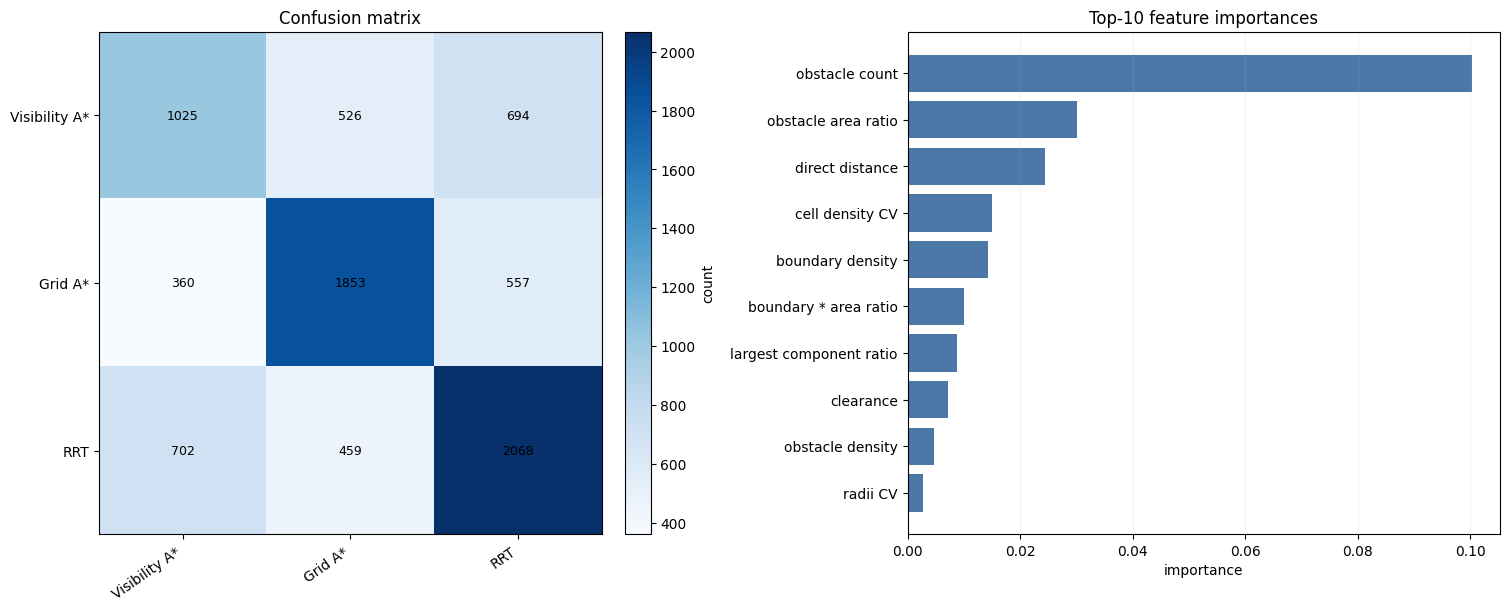

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

conf_image = axes[0].imshow(confusion_df.values, cmap='Blues')
axes[0].set_title('Confusion matrix')
axes[0].set_xticks(range(len(confusion_df.columns)))
axes[0].set_xticklabels(confusion_df.columns, rotation=35, ha='right')
axes[0].set_yticks(range(len(confusion_df.index)))
axes[0].set_yticklabels(confusion_df.index)
for row_index in range(len(confusion_df.index)):
    for col_index in range(len(confusion_df.columns)):
        axes[0].text(col_index, row_index, int(confusion_df.iloc[row_index, col_index]), ha='center', va='center', fontsize=9)
fig.colorbar(conf_image, ax=axes[0], fraction=0.046, pad=0.04, label='count')

plot_importance_df = feature_importance_df.iloc[:10].sort_values('importance', ascending=True)
axes[1].barh(plot_importance_df['feature_label'], plot_importance_df['importance'], color='#4c78a8')
axes[1].set_title('Top-10 feature importances')
axes[1].set_xlabel('importance')
axes[1].grid(axis='x', alpha=0.25, linewidth=0.5)

ml_figure_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_summary.png'
fig.savefig(ml_figure_path, dpi=180, bbox_inches='tight')

print('Selected candidate:', selected_candidate_name)
print('Selected score params:', {'beta': SCORE_BETA, 'gamma': SCORE_GAMMA, 'delta': SCORE_DELTA})
print('Feature set:', selected_feature_set, f"({len(split_bundle['feature_columns'])} features)")
print('Saved:', validation_results_path)
print('Saved:', selected_score_params_path)
print('Saved:', recommendation_scored_path)
print('Saved:', ml_scene_dataset_path)
print('Saved:', class_distribution_path)
print('Saved:', metrics_path)
print('Saved:', metrics_comparison_path)
print('Saved:', classification_report_path)
print('Saved:', per_class_metrics_path)
print('Saved:', confusion_path)
print('Saved:', feature_importance_path)
print('Saved:', test_prediction_path)
print('Saved:', ml_figure_path)

display(metrics_comparison_df.round(4))
display(per_class_metrics_df.round(4))
display(selected_score_params_df)
display(class_distribution_df.round(4))
display(validation_results_df.head(10).round(4))
display(metrics_df.round(4))
display(classification_report_df.round(4))
display(feature_importance_df.head(10).round(4))
display(test_prediction_df.head(10))

plt.show()

### Интерпретация ML-блока

После выполнения ML-раздела достаточно опираться на три группы артефактов:

- `*_metrics.csv` и `*_metrics_comparison.csv` — общая оценка модели и сравнение с `majority baseline`;
- `*_per_class_metrics.csv` и `*_confusion_matrix.csv` — качество по каждому алгоритму и основные направления путаницы;
- `*_feature_importance.csv` и `*_test_predictions.csv` — интерпретация признаков и покадровая диагностика ошибок.

Для краткого вывода в тексте обычно достаточно accuracy, balanced accuracy, macro F1 и метрик по каждому классу.



## Анализ времени построения и поиска у графовых алгоритмов

Этот раздел использует отдельный timing-срез для графовых методов. Цель здесь не сравнить алгоритмы по общему runtime, а понять, какая доля времени уходит на построение графа, какая — на поиск в графе, и как это зависит от сложности сцены.



In [106]:
from tools import experiment_dataset_parser as experiment_dataset_parser
experiment_dataset_parser = importlib.reload(experiment_dataset_parser)
load_or_build_experiment_dataset = experiment_dataset_parser.load_or_build_experiment_dataset

GRAPH_TIMING_EXPERIMENTS_DIR = Path(globals().get('GRAPH_TIMING_EXPERIMENTS_DIR_OVERRIDE', EXPERIMENTS_DIR))
GRAPH_TIMING_PREFIX = f'{DATASET_PREFIX}_graph_timing'
GRAPH_TIMING_FORCE_REBUILD = bool(globals().get('FORCE_REBUILD', False))

In [107]:
graph_timing_bundle, graph_timing_cache_info = load_or_build_experiment_dataset(
    GRAPH_TIMING_EXPERIMENTS_DIR,
    OUTPUT_DIR,
    prefix=GRAPH_TIMING_PREFIX,
    force_rebuild=GRAPH_TIMING_FORCE_REBUILD,
)

graph_timing_df = graph_timing_bundle.analysis_run_df.copy()
required_graph_timing_columns = {
    'is_graph_algorithm',
    'has_graph_timing',
    'algorithm_was_executed',
    'runtime_ms',
    'graph_build_time_ms',
    'graph_search_time_ms',
}
missing_graph_timing_columns = sorted(required_graph_timing_columns - set(graph_timing_df.columns))
if missing_graph_timing_columns:
    raise KeyError(
        'Graph timing dataset is missing expected columns: '
        f'{missing_graph_timing_columns}. Reload the parser or rebuild the dataset cache.'
    )

graph_timing_df = graph_timing_df[
    graph_timing_df['is_graph_algorithm']
    & graph_timing_df['has_graph_timing']
    & graph_timing_df['algorithm_was_executed']
].copy()

if graph_timing_df.empty:
    raise ValueError('No graph timing rows found.')

valid_runtime_mask = graph_timing_df['runtime_ms'] > 0
graph_timing_df['graph_build_share_percent'] = np.nan
graph_timing_df['graph_search_share_percent'] = np.nan
graph_timing_df.loc[valid_runtime_mask, 'graph_build_share_percent'] = (
    graph_timing_df.loc[valid_runtime_mask, 'graph_build_time_ms']
    / graph_timing_df.loc[valid_runtime_mask, 'runtime_ms']
    * 100.0
)
graph_timing_df.loc[valid_runtime_mask, 'graph_search_share_percent'] = (
    graph_timing_df.loc[valid_runtime_mask, 'graph_search_time_ms']
    / graph_timing_df.loc[valid_runtime_mask, 'runtime_ms']
    * 100.0
)

In [108]:
graph_timing_summary = (
    graph_timing_df
    .groupby('algorithm_id', dropna=False)
    .agg(
        runs=('algorithm_id', 'size'),
        success_rate=('path_found', 'mean'),
        runtime_ms_median=('runtime_ms', 'median'),
        runtime_ms_mean=('runtime_ms', 'mean'),
        build_ms_median=('graph_build_time_ms', 'median'),
        build_ms_mean=('graph_build_time_ms', 'mean'),
        search_ms_median=('graph_search_time_ms', 'median'),
        search_ms_mean=('graph_search_time_ms', 'mean'),
        build_share_percent_median=('graph_build_share_percent', 'median'),
        search_share_percent_median=('graph_search_share_percent', 'median'),
        nodes_median=('graph_node_count', 'median'),
        edges_median=('graph_edge_count', 'median'),
        expanded_nodes_median=('graph_expanded_nodes', 'median'),
    )
    .sort_values(['build_share_percent_median', 'runtime_ms_median'], ascending=[False, True])
    .reset_index()
)

graph_timing_by_config = (
    graph_timing_df
    .groupby(['config_index', 'config_name', 'algorithm_id'], dropna=False)
    .agg(
        runs=('algorithm_id', 'size'),
        runtime_ms_median=('runtime_ms', 'median'),
        build_ms_median=('graph_build_time_ms', 'median'),
        search_ms_median=('graph_search_time_ms', 'median'),
        build_share_percent_median=('graph_build_share_percent', 'median'),
        search_share_percent_median=('graph_search_share_percent', 'median'),
        obstacle_count_median=('scene_obstacle_count', 'median'),
        nodes_median=('graph_node_count', 'median'),
        edges_median=('graph_edge_count', 'median'),
    )
    .reset_index()
)

graph_timing_summary_path = OUTPUT_DIR / f'{GRAPH_TIMING_PREFIX}_summary_by_algorithm.csv'
graph_timing_by_config_path = OUTPUT_DIR / f'{GRAPH_TIMING_PREFIX}_summary_by_config.csv'
graph_timing_summary.to_csv(graph_timing_summary_path, index=False)
graph_timing_by_config.to_csv(graph_timing_by_config_path, index=False)

display(graph_timing_summary)
print(f'Saved: {graph_timing_summary_path}')
print(f'Saved: {graph_timing_by_config_path}')

,algorithm_id,runs,success_rate,runtime_ms_median,runtime_ms_mean,build_ms_median,build_ms_mean,search_ms_median,search_ms_mean,build_share_percent_median,search_share_percent_median,nodes_median,edges_median,expanded_nodes_median
0,visibility_astar,42337,0.973522,18.7110,201.809839,18.3282,201.238620,0.1058,0.200921,98.814719,0.496471,2496.0,7490.0,97.0
1,visibility_dijkstra,42337,0.973522,19.1881,202.733151,18.4466,201.538501,0.4208,0.887769,97.855580,1.604536,2496.0,7490.0,2396.0
2,grid_astar,42337,0.952099,4.3107,18.073822,3.5933,14.010449,0.4706,2.291238,82.028521,10.511933,5536.0,38048.0,1363.0
3,grid_dijkstra,42337,0.952099,4.5296,20.137008,3.6420,14.121190,0.6443,4.305761,79.758185,15.057377,5536.0,38048.0,5091.0


Saved: Q:\Diploma\python\analysis_outputs\final53_graph_timing_summary_by_algorithm.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_graph_timing_summary_by_config.csv


    Сводка по алгоритмам показывает устойчивое различие в структуре runtime. Для `Visibility A*` медианная доля построения графа составляет около `98.8%`, тогда как для `Grid A*` она ближе к `82.0%`, и вклад самого поиска там заметно выше.
    


### Scene-level таблицы для graph timing

Ниже готовятся две рабочие таблицы: одна строка на запуск алгоритма в сцене и отдельный агрегат на сцену. Такой разрез удобен и для ручного просмотра, и для последующих графиков.



In [109]:
graph_timing_scene_algorithm_columns = [
    'config_index', 'config_name', 'scene_id', 'scene_index', 'scene_seed',
    'algorithm_id', 'algorithm_status', 'path_found',
    'runtime_ms', 'graph_build_time_ms', 'graph_search_time_ms',
    'graph_path_extraction_time_ms', 'graph_timing_residual_ms',
    'graph_build_share_percent', 'graph_search_share_percent',
    'graph_node_count', 'graph_edge_count', 'graph_expanded_nodes',
    'scene_width', 'scene_height', 'scene_area', 'scene_aspect_ratio',
    'scene_obstacle_count', 'scene_direct_distance',
    'scene_metric_obstacle_area_ratio', 'scene_metric_boundary_density',
    'scene_metric_cell_density_cv', 'scene_metric_radii_cv',
    'scene_metric_clearance', 'scene_metric_largest_component_ratio',
]
graph_timing_scene_algorithm_columns = [
    column for column in graph_timing_scene_algorithm_columns
    if column in graph_timing_df.columns
]

graph_timing_scene_algorithm_df = graph_timing_df[graph_timing_scene_algorithm_columns].copy()
graph_timing_scene_algorithm_df['graph_edge_per_node'] = np.where(
    graph_timing_scene_algorithm_df['graph_node_count'] > 0,
    graph_timing_scene_algorithm_df['graph_edge_count'] / graph_timing_scene_algorithm_df['graph_node_count'],
    np.nan,
)
graph_timing_scene_algorithm_df['build_to_search_ratio'] = np.where(
    graph_timing_scene_algorithm_df['graph_search_time_ms'] > 0,
    graph_timing_scene_algorithm_df['graph_build_time_ms'] / graph_timing_scene_algorithm_df['graph_search_time_ms'],
    np.nan,
)
graph_timing_scene_algorithm_df = graph_timing_scene_algorithm_df.sort_values(
    ['config_index', 'scene_index', 'algorithm_id']
).reset_index(drop=True)

In [110]:
graph_timing_scene_df = (
    graph_timing_scene_algorithm_df
    .groupby(['config_index', 'config_name', 'scene_id', 'scene_index', 'scene_seed'], dropna=False)
    .agg(
        algorithm_count=('algorithm_id', 'nunique'),
        path_found_count=('path_found', 'sum'),
        runtime_ms_median=('runtime_ms', 'median'),
        runtime_ms_max=('runtime_ms', 'max'),
        build_ms_median=('graph_build_time_ms', 'median'),
        search_ms_median=('graph_search_time_ms', 'median'),
        build_share_percent_median=('graph_build_share_percent', 'median'),
        search_share_percent_median=('graph_search_share_percent', 'median'),
        nodes_median=('graph_node_count', 'median'),
        edges_median=('graph_edge_count', 'median'),
        expanded_nodes_median=('graph_expanded_nodes', 'median'),
        obstacle_count=('scene_obstacle_count', 'first'),
        scene_area=('scene_area', 'first'),
        aspect_ratio=('scene_aspect_ratio', 'first'),
        direct_distance=('scene_direct_distance', 'first'),
        obstacle_area_ratio=('scene_metric_obstacle_area_ratio', 'first'),
        boundary_density=('scene_metric_boundary_density', 'first'),
        clearance=('scene_metric_clearance', 'first'),
        largest_component_ratio=('scene_metric_largest_component_ratio', 'first'),
    )
    .reset_index()
)

graph_timing_scene_algorithm_path = OUTPUT_DIR / f'{GRAPH_TIMING_PREFIX}_scene_algorithm_rows.csv'
graph_timing_scene_summary_path = OUTPUT_DIR / f'{GRAPH_TIMING_PREFIX}_scene_summary.csv'
graph_timing_scene_algorithm_df.to_csv(graph_timing_scene_algorithm_path, index=False)
graph_timing_scene_df.to_csv(graph_timing_scene_summary_path, index=False)

display(graph_timing_scene_algorithm_df.head(10))
display(graph_timing_scene_df.head(10))
print(f'Saved: {graph_timing_scene_algorithm_path}')
print(f'Saved: {graph_timing_scene_summary_path}')

,config_index,config_name,scene_id,scene_index,scene_seed,algorithm_id,algorithm_status,path_found,runtime_ms,graph_build_time_ms,...,scene_obstacle_count,scene_direct_distance,scene_metric_obstacle_area_ratio,scene_metric_boundary_density,scene_metric_cell_density_cv,scene_metric_radii_cv,scene_metric_clearance,scene_metric_largest_component_ratio,graph_edge_per_node,build_to_search_ratio
0,1,final53_compact_uniform_micro_open,scene_1,1,92501,grid_astar,Success,True,0.6468,0.5299,...,46,68.126456,0.0313,0.045626,1.830641,0.225328,0.964286,1.0,7.154545,6.793590
1,1,final53_compact_uniform_micro_open,scene_1,1,92501,grid_dijkstra,Success,True,0.5843,0.4774,...,46,68.126456,0.0313,0.045626,1.830641,0.225328,0.964286,1.0,7.154545,5.643026
2,1,final53_compact_uniform_micro_open,scene_1,1,92501,visibility_astar,Success,True,19.5119,18.9500,...,46,68.126456,0.0313,0.045626,1.830641,0.225328,0.964286,1.0,3.017892,103.551913
3,1,final53_compact_uniform_micro_open,scene_1,1,92501,visibility_dijkstra,Success,True,23.2532,21.4127,...,46,68.126456,0.0313,0.045626,1.830641,0.225328,0.964286,1.0,3.017892,14.517085
4,1,final53_compact_uniform_micro_open,scene_2,2,92502,grid_astar,Success,True,0.6092,0.5278,...,44,91.411125,0.0321,0.044950,1.891669,0.203071,0.964286,1.0,7.141123,14.867606
5,1,final53_compact_uniform_micro_open,scene_2,2,92502,grid_dijkstra,Success,True,0.6856,0.5470,...,44,91.411125,0.0321,0.044950,1.891669,0.203071,0.964286,1.0,7.141123,5.727749
6,1,final53_compact_uniform_micro_open,scene_2,2,92502,visibility_astar,Success,True,17.7058,17.1653,...,44,91.411125,0.0321,0.044950,1.891669,0.203071,0.964286,1.0,3.017130,106.024089
7,1,final53_compact_uniform_micro_open,scene_2,2,92502,visibility_dijkstra,Success,True,18.0188,16.7258,...,44,91.411125,0.0321,0.044950,1.891669,0.203071,0.964286,1.0,3.017130,16.447832
8,1,final53_compact_uniform_micro_open,scene_3,3,92503,grid_astar,Success,True,0.5418,0.4802,...,40,92.202402,0.0296,0.042639,1.777596,0.206689,0.964286,1.0,7.169184,14.685015
9,1,final53_compact_uniform_micro_open,scene_3,3,92503,grid_dijkstra,Success,True,0.7299,0.6180,...,40,92.202402,0.0296,0.042639,1.777596,0.206689,0.964286,1.0,7.169184,8.741160


,config_index,config_name,scene_id,scene_index,scene_seed,algorithm_count,path_found_count,runtime_ms_median,runtime_ms_max,build_ms_median,...,edges_median,expanded_nodes_median,obstacle_count,scene_area,aspect_ratio,direct_distance,obstacle_area_ratio,boundary_density,clearance,largest_component_ratio
0,1,final53_compact_uniform_micro_open,scene_1,1,92501,4,4,10.07935,23.2532,9.73995,...,9361.0,251.5,46,8100.0,1.0,68.126456,0.0313,0.045626,0.964286,1.000000
1,1,final53_compact_uniform_micro_open,scene_10,10,92510,4,4,8.67625,17.9889,7.72525,...,8001.0,343.5,40,8100.0,1.0,92.051945,0.0292,0.040409,0.964286,1.000000
2,1,final53_compact_uniform_micro_open,scene_100,100,92600,4,4,9.83860,27.4612,9.21635,...,8526.0,313.0,43,8100.0,1.0,87.324821,0.0328,0.043596,0.964286,1.000000
3,1,final53_compact_uniform_micro_open,scene_101,101,92601,4,4,6.15795,12.8338,5.83170,...,7189.0,301.0,36,8100.0,1.0,88.857574,0.0257,0.035077,0.964286,0.999948
4,1,final53_compact_uniform_micro_open,scene_102,102,92602,4,4,8.26305,37.7198,7.93580,...,8522.0,343.0,41,8100.0,1.0,80.734169,0.0259,0.041437,0.964286,1.000000
5,1,final53_compact_uniform_micro_open,scene_103,103,92603,4,4,10.60590,22.7395,9.49175,...,8459.0,300.5,46,8100.0,1.0,79.208189,0.0336,0.046324,0.964286,1.000000
6,1,final53_compact_uniform_micro_open,scene_104,104,92604,4,4,9.58985,19.6720,9.36905,...,8230.0,320.5,40,8100.0,1.0,90.222568,0.0249,0.039128,0.964286,1.000000
7,1,final53_compact_uniform_micro_open,scene_105,105,92605,4,4,6.97435,15.9777,6.48910,...,7397.0,321.0,37,8100.0,1.0,96.835113,0.0231,0.035986,0.964286,1.000000
8,1,final53_compact_uniform_micro_open,scene_106,106,92606,4,4,11.40525,21.7478,10.33020,...,8895.0,346.0,45,8100.0,1.0,84.834006,0.0292,0.043482,0.964286,1.000000
9,1,final53_compact_uniform_micro_open,scene_107,107,92607,4,4,11.12225,22.9104,10.45390,...,9465.0,295.0,47,8100.0,1.0,82.595545,0.0348,0.048055,0.964286,0.999894


Saved: Q:\Diploma\python\analysis_outputs\final53_graph_timing_scene_algorithm_rows.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_graph_timing_scene_summary.csv


    Scene-level таблицы удобны тем, что позволяют перейти от средних по алгоритму к анализу конкретных сцен. Именно на этом уровне становятся видны крайние случаи, где построение графа почти полностью доминирует в общем runtime.
    


### Распределения времени построения и поиска

Сначала строится минимальный визуальный срез: boxplot долей build/search времени по алгоритмам и гистограммы абсолютных времен. Это дает быстрый ответ, где именно возникают основные затраты.



C:\Users\USER\AppData\Local\Temp\ipykernel_1532\1228107518.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot(box_data, labels=timing_algorithms, showfliers=False)
C:\Users\USER\AppData\Local\Temp\ipykernel_1532\1228107518.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(box_data, labels=timing_algorithms, showfliers=False)


Saved: Q:\Diploma\python\analysis_outputs\final53_graph_timing_time_distributions.png


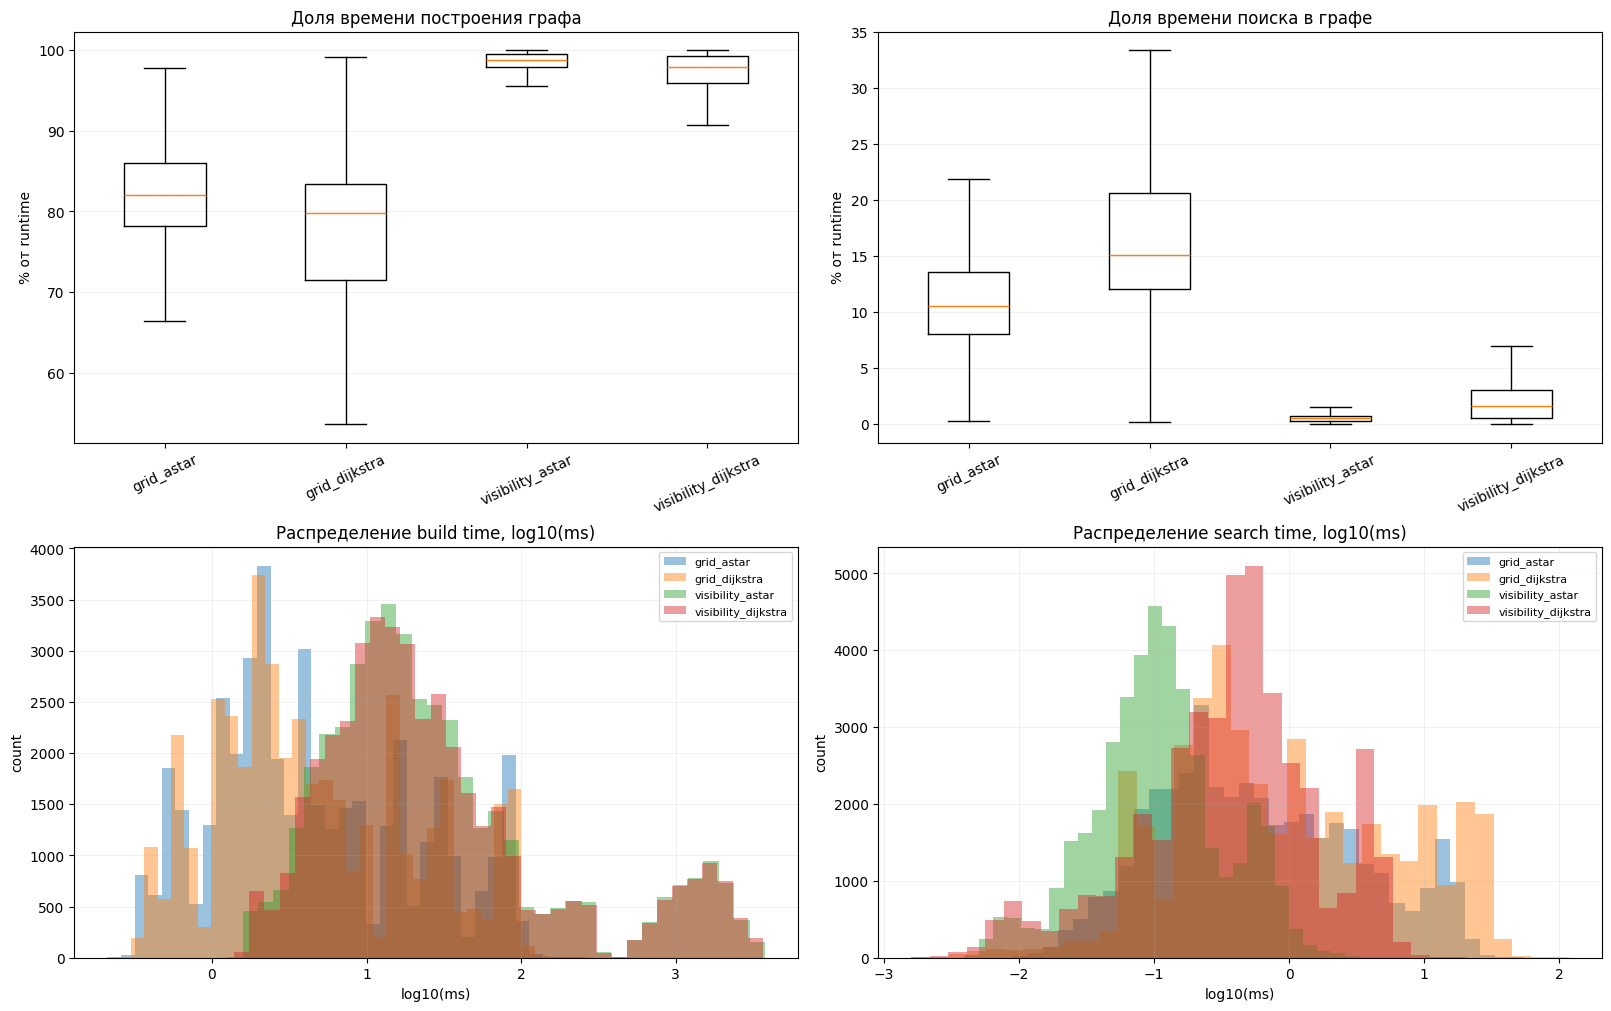

In [111]:
timing_algorithms = sorted(graph_timing_df['algorithm_id'].dropna().unique())
distribution_figure_path = OUTPUT_DIR / f'{GRAPH_TIMING_PREFIX}_time_distributions.png'

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

box_data = [
    graph_timing_df.loc[graph_timing_df['algorithm_id'] == algorithm, 'graph_build_share_percent'].dropna()
    for algorithm in timing_algorithms
]
axes[0, 0].boxplot(box_data, labels=timing_algorithms, showfliers=False)
axes[0, 0].set_title('Доля времени построения графа')
axes[0, 0].set_ylabel('% от runtime')
axes[0, 0].tick_params(axis='x', rotation=25)
axes[0, 0].grid(axis='y', alpha=0.25, linewidth=0.5)

box_data = [
    graph_timing_df.loc[graph_timing_df['algorithm_id'] == algorithm, 'graph_search_share_percent'].dropna()
    for algorithm in timing_algorithms
]
axes[0, 1].boxplot(box_data, labels=timing_algorithms, showfliers=False)
axes[0, 1].set_title('Доля времени поиска в графе')
axes[0, 1].set_ylabel('% от runtime')
axes[0, 1].tick_params(axis='x', rotation=25)
axes[0, 1].grid(axis='y', alpha=0.25, linewidth=0.5)

for algorithm in timing_algorithms:
    data = graph_timing_df.loc[graph_timing_df['algorithm_id'] == algorithm, 'graph_build_time_ms']
    data = data[data > 0]
    axes[1, 0].hist(np.log10(data), bins=35, alpha=0.45, label=algorithm)
axes[1, 0].set_title('Распределение build time, log10(ms)')
axes[1, 0].set_xlabel('log10(ms)')
axes[1, 0].set_ylabel('count')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.25, linewidth=0.5)

for algorithm in timing_algorithms:
    data = graph_timing_df.loc[graph_timing_df['algorithm_id'] == algorithm, 'graph_search_time_ms']
    data = data[data > 0]
    axes[1, 1].hist(np.log10(data), bins=35, alpha=0.45, label=algorithm)
axes[1, 1].set_title('Распределение search time, log10(ms)')
axes[1, 1].set_xlabel('log10(ms)')
axes[1, 1].set_ylabel('count')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.25, linewidth=0.5)

fig.savefig(distribution_figure_path, dpi=180, bbox_inches='tight')
print(f'Saved: {distribution_figure_path}')
plt.show()

### Корреляции долей времени с параметрами сцены и графа

Затем проверяется, какие характеристики среды и графа сильнее всего связаны с ростом доли build/search времени. Это помогает отделить геометрические факторы от чисто алгоритмических.



Saved: Q:\Diploma\python\analysis_outputs\final53_graph_timing_percentage_correlations.csv
Saved: Q:\Diploma\python\analysis_outputs\final53_graph_timing_percentage_correlation_heatmap.png


,algorithm_id,target,feature,spearman_corr,abs_spearman_corr,pair_count
0,grid_astar,graph_build_share_percent,graph_expanded_nodes,-0.7321,0.7321,42337
1,grid_astar,graph_build_share_percent,scene_metric_clearance,-0.6497,0.6497,42337
2,grid_astar,graph_build_share_percent,graph_edge_count,-0.6401,0.6401,42337
3,grid_astar,graph_build_share_percent,graph_node_count,-0.6349,0.6349,42337
4,grid_astar,graph_build_share_percent,scene_direct_distance,-0.6342,0.6342,42337
...,...,...,...,...,...,...
101,visibility_dijkstra,graph_search_share_percent,scene_metric_cell_density_cv,0.6307,0.6307,42337
102,visibility_dijkstra,graph_search_share_percent,scene_obstacle_count,-0.5892,0.5892,42337
103,visibility_dijkstra,graph_search_share_percent,scene_metric_boundary_density,-0.5283,0.5283,42337
104,visibility_dijkstra,graph_search_share_percent,scene_area,-0.1751,0.1751,42337


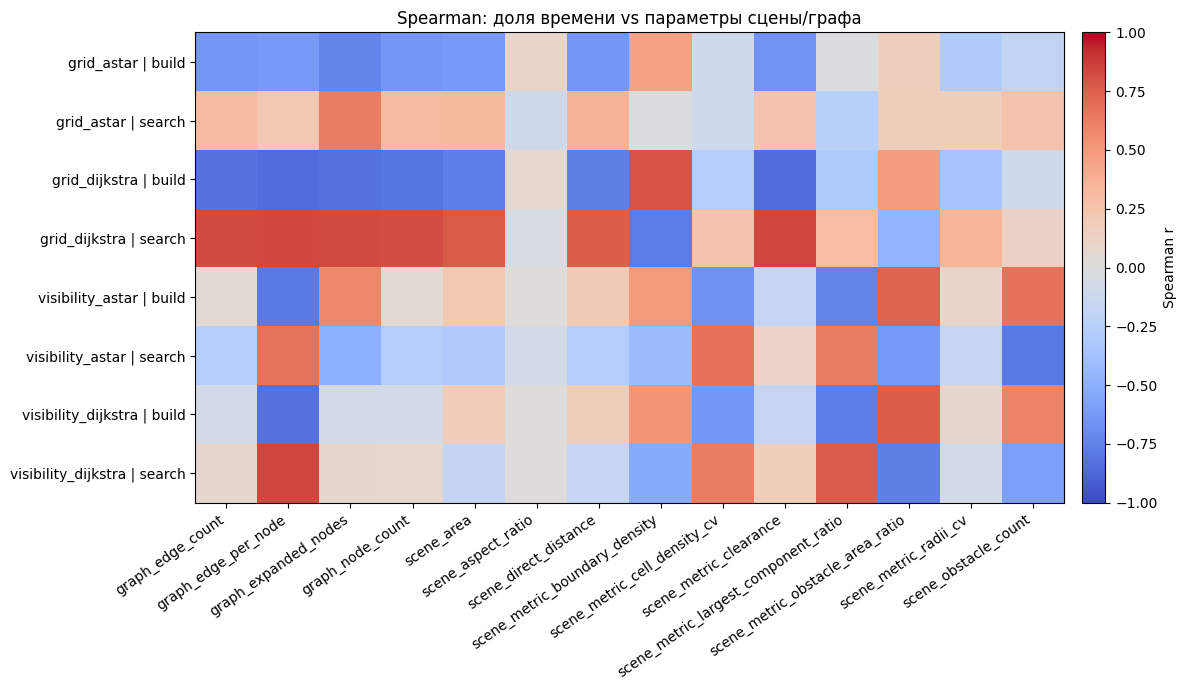

In [112]:
correlation_feature_candidates = [
    'scene_obstacle_count', 'scene_area', 'scene_aspect_ratio', 'scene_direct_distance',
    'scene_metric_obstacle_area_ratio', 'scene_metric_boundary_density',
    'scene_metric_cell_density_cv', 'scene_metric_radii_cv',
    'scene_metric_clearance', 'scene_metric_largest_component_ratio',
    'graph_node_count', 'graph_edge_count', 'graph_expanded_nodes', 'graph_edge_per_node',
]
correlation_features = [
    column for column in correlation_feature_candidates
    if column in graph_timing_scene_algorithm_df.columns
]
correlation_targets = ['graph_build_share_percent', 'graph_search_share_percent']

corr_input_df = graph_timing_scene_algorithm_df[
    ['algorithm_id', *correlation_targets, *correlation_features]
].replace([np.inf, -np.inf], np.nan).copy()

correlation_rows = []
for algorithm_id, algorithm_df in corr_input_df.groupby('algorithm_id'):
    for target in correlation_targets:
        for feature in correlation_features:
            pair_df = algorithm_df[[target, feature]].dropna()
            if len(pair_df) < 8 or pair_df[target].nunique() < 2 or pair_df[feature].nunique() < 2:
                corr_value = np.nan
            else:
                corr_value = pair_df[target].corr(pair_df[feature], method='spearman')
            correlation_rows.append({
                'algorithm_id': algorithm_id,
                'target': target,
                'feature': feature,
                'spearman_corr': corr_value,
                'abs_spearman_corr': abs(corr_value) if pd.notna(corr_value) else np.nan,
                'pair_count': len(pair_df),
            })

graph_timing_correlation_df = pd.DataFrame(correlation_rows).sort_values(
    ['target', 'algorithm_id', 'abs_spearman_corr'], ascending=[True, True, False]
).reset_index(drop=True)
correlation_path = OUTPUT_DIR / f'{GRAPH_TIMING_PREFIX}_percentage_correlations.csv'
graph_timing_correlation_df.to_csv(correlation_path, index=False)

top_correlation_df = (
    graph_timing_correlation_df
    .dropna(subset=['spearman_corr'])
    .groupby(['algorithm_id', 'target'], group_keys=False)
    .head(8)
)

heatmap_df = graph_timing_correlation_df.pivot_table(
    index=['algorithm_id', 'target'],
    columns='feature',
    values='spearman_corr',
)
heatmap_path = OUTPUT_DIR / f'{GRAPH_TIMING_PREFIX}_percentage_correlation_heatmap.png'
fig, ax = plt.subplots(figsize=(max(12, len(correlation_features) * 0.75), 7))
image = ax.imshow(heatmap_df.fillna(0.0).values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax.set_title('Spearman: доля времени vs параметры сцены/графа')
ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=35, ha='right')
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels([f'{idx[0]} | {idx[1].replace("graph_", "").replace("_share_percent", "")}' for idx in heatmap_df.index])
fig.colorbar(image, ax=ax, fraction=0.03, pad=0.02, label='Spearman r')
fig.tight_layout()
fig.savefig(heatmap_path, dpi=180, bbox_inches='tight')

print(f'Saved: {correlation_path}')
print(f'Saved: {heatmap_path}')
display(top_correlation_df.round(4))
plt.show()

    Корреляционный блок нужен не сам по себе, а как объяснение механизма замедления. Он показывает, какие свойства сцены и графа сильнее всего связаны с ростом доли времени на построение и на поиск.
    


### Простая сводка: куда уходит время graph-алгоритмов

В этой части формируется самый прямой итог: средняя и медианная доля времени на построение графа, поиск в графе и прочие накладные расходы.



In [113]:
simple_timing_df = graph_timing_df.copy()
simple_timing_df['other_time_ms'] = (
    simple_timing_df['runtime_ms']
    - simple_timing_df['graph_build_time_ms'].fillna(0.0)
    - simple_timing_df['graph_search_time_ms'].fillna(0.0)
)
simple_timing_df['other_time_ms'] = simple_timing_df['other_time_ms'].clip(lower=0.0)

valid_runtime_mask = simple_timing_df['runtime_ms'] > 0
simple_timing_df['build_percent'] = np.nan
simple_timing_df['search_percent'] = np.nan
simple_timing_df['other_percent'] = np.nan
simple_timing_df.loc[valid_runtime_mask, 'build_percent'] = (
    simple_timing_df.loc[valid_runtime_mask, 'graph_build_time_ms']
    / simple_timing_df.loc[valid_runtime_mask, 'runtime_ms']
    * 100.0
)
simple_timing_df.loc[valid_runtime_mask, 'search_percent'] = (
    simple_timing_df.loc[valid_runtime_mask, 'graph_search_time_ms']
    / simple_timing_df.loc[valid_runtime_mask, 'runtime_ms']
    * 100.0
)
simple_timing_df.loc[valid_runtime_mask, 'other_percent'] = (
    simple_timing_df.loc[valid_runtime_mask, 'other_time_ms']
    / simple_timing_df.loc[valid_runtime_mask, 'runtime_ms']
    * 100.0
)

In [114]:
simple_algorithm_summary = (
    simple_timing_df
    .groupby('algorithm_id', dropna=False)
    .agg(
        runs=('algorithm_id', 'size'),
        success_rate=('path_found', 'mean'),
        avg_runtime_ms=('runtime_ms', 'mean'),
        median_runtime_ms=('runtime_ms', 'median'),
        avg_build_ms=('graph_build_time_ms', 'mean'),
        avg_search_ms=('graph_search_time_ms', 'mean'),
        avg_other_ms=('other_time_ms', 'mean'),
        avg_build_percent=('build_percent', 'mean'),
        avg_search_percent=('search_percent', 'mean'),
        avg_other_percent=('other_percent', 'mean'),
        median_build_percent=('build_percent', 'median'),
        median_search_percent=('search_percent', 'median'),
        median_other_percent=('other_percent', 'median'),
        p90_build_percent=('build_percent', lambda values: values.quantile(0.90)),
        p90_search_percent=('search_percent', lambda values: values.quantile(0.90)),
        median_nodes=('graph_node_count', 'median'),
        median_edges=('graph_edge_count', 'median'),
        median_expanded_nodes=('graph_expanded_nodes', 'median'),
    )
    .reset_index()
)

percent_columns = ['avg_build_percent', 'avg_search_percent', 'avg_other_percent']
percent_sum = simple_algorithm_summary[percent_columns].sum(axis=1).replace(0.0, np.nan)
for column in percent_columns:
    simple_algorithm_summary[column] = simple_algorithm_summary[column] / percent_sum * 100.0

simple_summary_path = OUTPUT_DIR / f'{GRAPH_TIMING_PREFIX}_simple_algorithm_summary.csv'
simple_algorithm_summary.to_csv(simple_summary_path, index=False)
display(simple_algorithm_summary.round(3))
print(f'Saved: {simple_summary_path}')

,algorithm_id,runs,success_rate,avg_runtime_ms,median_runtime_ms,avg_build_ms,avg_search_ms,avg_other_ms,avg_build_percent,avg_search_percent,avg_other_percent,median_build_percent,median_search_percent,median_other_percent,p90_build_percent,p90_search_percent,median_nodes,median_edges,median_expanded_nodes
0,grid_astar,42337,0.952,18.074,4.311,14.010,2.291,1.772,81.468,11.275,7.257,82.029,10.512,6.004,88.518,16.901,5536.0,38048.0,1363.0
1,grid_dijkstra,42337,0.952,20.137,4.530,14.121,4.306,1.710,77.685,16.216,6.099,79.758,15.057,5.013,86.592,23.881,5536.0,38048.0,5091.0
2,visibility_astar,42337,0.974,201.810,18.711,201.239,0.201,0.370,98.546,0.556,0.898,98.815,0.496,0.631,99.805,0.983,2496.0,7490.0,97.0
3,visibility_dijkstra,42337,0.974,202.733,19.188,201.539,0.888,0.307,97.301,2.007,0.692,97.856,1.605,0.500,99.668,4.074,2496.0,7490.0,2396.0


Saved: Q:\Diploma\python\analysis_outputs\final53_graph_timing_simple_algorithm_summary.csv


    Простая сводка переводит timing-анализ в максимально прикладной формат. По ней легко увидеть, доминирует ли у алгоритма построение графа, сам поиск или какие-то прочие накладные расходы.
    


Saved: Q:\Diploma\python\analysis_outputs\final53_graph_timing_simple_time_percent_stacked.png


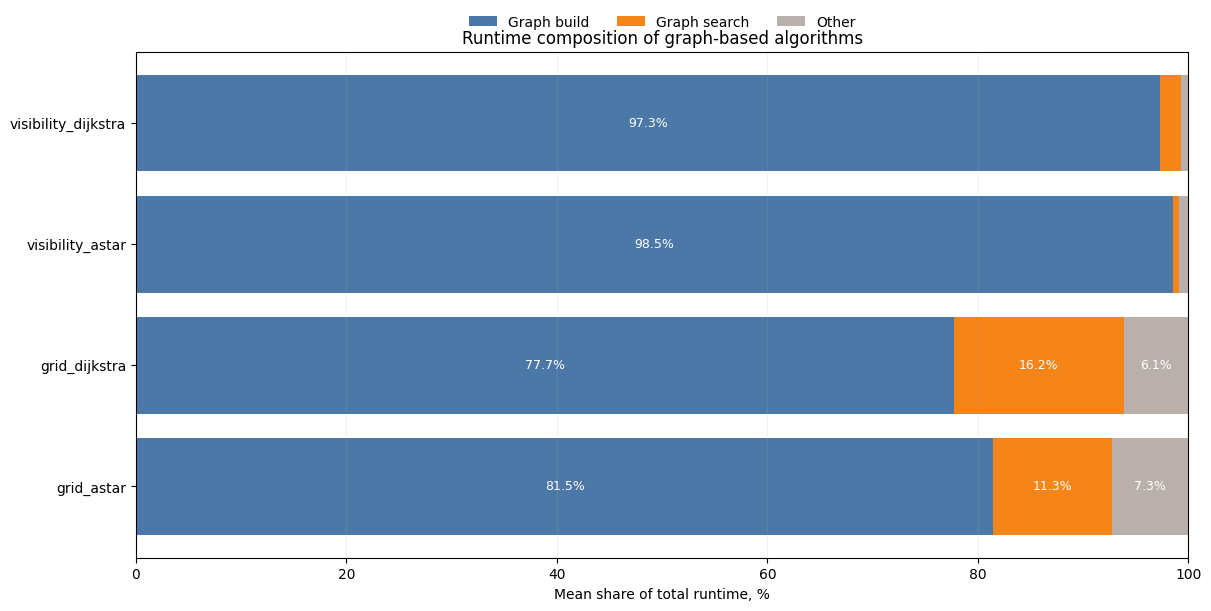

In [115]:
simple_percent_figure_path = OUTPUT_DIR / f'{GRAPH_TIMING_PREFIX}_simple_time_percent_stacked.png'
plot_df = simple_algorithm_summary.set_index('algorithm_id')[
    ['avg_build_percent', 'avg_search_percent', 'avg_other_percent']
].copy()
plot_df = plot_df.rename(columns={
    'avg_build_percent': 'Graph build',
    'avg_search_percent': 'Graph search',
    'avg_other_percent': 'Other',
})

fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
colors = ['#4c78a8', '#f58518', '#bab0ab']
left = np.zeros(len(plot_df))
y_positions = np.arange(len(plot_df))

for color, column in zip(colors, plot_df.columns):
    values = plot_df[column].to_numpy()
    ax.barh(y_positions, values, left=left, color=color, label=column)
    for y, x_left, value in zip(y_positions, left, values):
        if value >= 3.0:
            ax.text(x_left + value / 2.0, y, f'{value:.1f}%', ha='center', va='center', fontsize=9, color='white')
    left += values

ax.set_yticks(y_positions)
ax.set_yticklabels(plot_df.index)
ax.set_xlim(0, 100)
ax.set_xlabel('Mean share of total runtime, %')
ax.set_title('Runtime composition of graph-based algorithms')
ax.grid(axis='x', alpha=0.25, linewidth=0.5)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False)

fig.savefig(simple_percent_figure_path, dpi=180, bbox_inches='tight')
print(f'Saved: {simple_percent_figure_path}')
plt.show()

    В среднем картина оказывается очень неоднородной: у visibility-графов почти всё время уходит на построение графа, а у grid-графов build тоже доминирует, но поиск занимает уже заметную долю. Именно поэтому общий runtime графовых методов нельзя интерпретировать без разложения на составные части.
    


### Простое распределение по сценам

Наконец, агрегирование переносится с уровня алгоритма на уровень сцены. Это позволяет увидеть, доминирует ли построение графа почти всегда или только на отдельных тяжелых сценах.



In [116]:
scene_percent_df = simple_timing_df.copy()
scene_percent_df['scene_key'] = (
    scene_percent_df['config_index'].astype(str) + ' / ' + scene_percent_df['scene_id'].astype(str)
)

scene_percent_summary_df = (
    scene_percent_df
    .groupby(['config_index', 'config_name', 'scene_id', 'scene_index', 'scene_seed'], dropna=False)
    .agg(
        algorithm_count=('algorithm_id', 'nunique'),
        path_found_count=('path_found', 'sum'),
        median_runtime_ms=('runtime_ms', 'median'),
        max_runtime_ms=('runtime_ms', 'max'),
        median_build_percent=('build_percent', 'median'),
        median_search_percent=('search_percent', 'median'),
        max_build_percent=('build_percent', 'max'),
        max_search_percent=('search_percent', 'max'),
        median_build_ms=('graph_build_time_ms', 'median'),
        median_search_ms=('graph_search_time_ms', 'median'),
        median_nodes=('graph_node_count', 'median'),
        median_edges=('graph_edge_count', 'median'),
        median_expanded_nodes=('graph_expanded_nodes', 'median'),
        obstacle_count=('scene_obstacle_count', 'first'),
        scene_area=('scene_area', 'first'),
        clearance=('scene_metric_clearance', 'first'),
        obstacle_area_ratio=('scene_metric_obstacle_area_ratio', 'first'),
        boundary_density=('scene_metric_boundary_density', 'first'),
        largest_component_ratio=('scene_metric_largest_component_ratio', 'first'),
    )
    .reset_index()
)
scene_percent_summary_df['build_dominates_95'] = scene_percent_summary_df['median_build_percent'] >= 95.0
scene_percent_summary_df['build_dominates_99'] = scene_percent_summary_df['median_build_percent'] >= 99.0

scene_percent_summary_path = OUTPUT_DIR / f'{GRAPH_TIMING_PREFIX}_simple_scene_percent_summary.csv'
scene_percent_summary_df.to_csv(scene_percent_summary_path, index=False)

In [117]:
scene_distribution_note = {
    'scene_count': int(len(scene_percent_summary_df)),
    'median_build_percent_over_scenes': float(scene_percent_summary_df['median_build_percent'].median()),
    'median_search_percent_over_scenes': float(scene_percent_summary_df['median_search_percent'].median()),
    'scenes_with_build_ge_95_percent': int(scene_percent_summary_df['build_dominates_95'].sum()),
    'scenes_with_build_ge_99_percent': int(scene_percent_summary_df['build_dominates_99'].sum()),
}

display(scene_distribution_note)
display(scene_percent_summary_df.sort_values('median_build_percent', ascending=False).head(10).round(3))
print(f'Saved: {scene_percent_summary_path}')

{'scene_count': 42337,
 'median_build_percent_over_scenes': 90.32076706454754,
 'median_search_percent_over_scenes': 6.0035789139162885,
 'scenes_with_build_ge_95_percent': 1540,
 'scenes_with_build_ge_99_percent': 6}

,config_index,config_name,scene_id,scene_index,scene_seed,algorithm_count,path_found_count,median_runtime_ms,max_runtime_ms,median_build_percent,...,median_edges,median_expanded_nodes,obstacle_count,scene_area,clearance,obstacle_area_ratio,boundary_density,largest_component_ratio,build_dominates_95,build_dominates_99
26099,33,final53_medium_multi_cluster_passages,scene_604,604,93236,4,4,14.308,40.324,99.380,...,9047.0,731.5,48,44100.0,1.340,0.345,0.084,0.998,True,True
24744,32,final53_medium_boulder_field_heavy,scene_104,104,92735,4,4,40.064,100.778,99.308,...,6173.0,700.0,68,32400.0,0.473,0.507,0.102,0.982,True,True
20210,26,final53_compact_boulder_field_heavy,scene_3,3,92628,4,0,2.529,4.711,99.254,...,1227.0,23.0,48,12100.0,0.596,0.652,0.205,0.794,True,True
24745,32,final53_medium_boulder_field_heavy,scene_105,105,92736,4,4,36.268,103.583,99.052,...,6426.0,793.0,54,32400.0,0.597,0.484,0.086,0.998,True,True
20463,26,final53_compact_boulder_field_heavy,scene_545,545,93170,4,0,2.652,4.353,99.042,...,1213.0,20.0,53,12100.0,0.445,0.641,0.237,0.536,True,True
20077,26,final53_compact_boulder_field_heavy,scene_170,170,92795,4,0,2.987,4.205,99.037,...,1234.0,39.0,52,12100.0,0.574,0.643,0.215,0.687,True,True
24862,32,final53_medium_boulder_field_heavy,scene_210,210,92841,4,4,27.198,40.089,98.912,...,6716.0,874.0,61,32400.0,0.579,0.459,0.094,0.998,True,False
27175,35,final53_medium_vertical_broken_mass,scene_132,132,92766,4,4,7.743,26.712,98.907,...,9616.0,454.5,53,35200.0,1.714,0.178,0.064,0.993,True,False
20443,26,final53_compact_boulder_field_heavy,scene_525,525,93150,4,0,3.368,6.676,98.698,...,1330.0,54.5,53,12100.0,0.511,0.608,0.205,0.566,True,False
27176,35,final53_medium_vertical_broken_mass,scene_133,133,92767,4,4,7.317,27.032,98.689,...,9816.0,502.0,52,35200.0,1.667,0.172,0.062,1.000,True,False


Saved: Q:\Diploma\python\analysis_outputs\final53_graph_timing_simple_scene_percent_summary.csv


Saved: Q:\Diploma\python\analysis_outputs\final53_graph_timing_simple_scene_percent_distributions.png


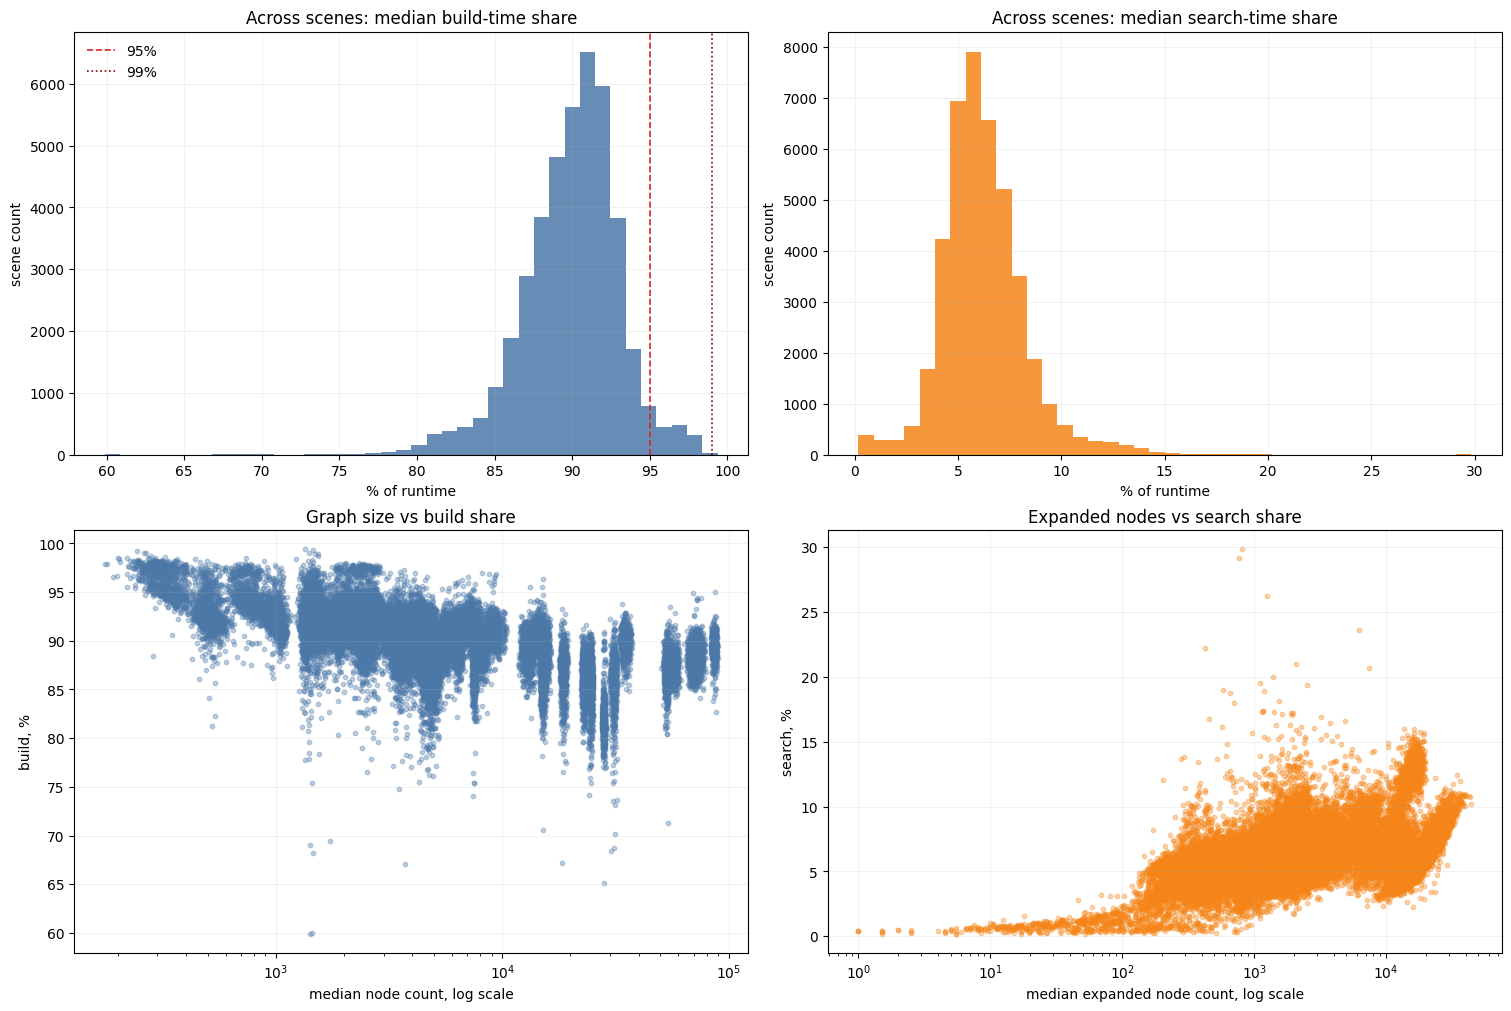

In [118]:
scene_percent_distribution_path = OUTPUT_DIR / f'{GRAPH_TIMING_PREFIX}_simple_scene_percent_distributions.png'

fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

axes[0, 0].hist(scene_percent_summary_df['median_build_percent'].dropna(), bins=40, color='#4c78a8', alpha=0.85)
axes[0, 0].axvline(95.0, color='#d62728', linestyle='--', linewidth=1.2, label='95%')
axes[0, 0].axvline(99.0, color='#7f0000', linestyle=':', linewidth=1.2, label='99%')
axes[0, 0].set_title('Across scenes: median build-time share')
axes[0, 0].set_xlabel('% of runtime')
axes[0, 0].set_ylabel('scene count')
axes[0, 0].legend(frameon=False)
axes[0, 0].grid(alpha=0.25, linewidth=0.5)

axes[0, 1].hist(scene_percent_summary_df['median_search_percent'].dropna(), bins=40, color='#f58518', alpha=0.85)
axes[0, 1].set_title('Across scenes: median search-time share')
axes[0, 1].set_xlabel('% of runtime')
axes[0, 1].set_ylabel('scene count')
axes[0, 1].grid(alpha=0.25, linewidth=0.5)

axes[1, 0].scatter(
    scene_percent_summary_df['median_nodes'],
    scene_percent_summary_df['median_build_percent'],
    s=10, alpha=0.35, color='#4c78a8'
)
axes[1, 0].set_xscale('log')
axes[1, 0].set_title('Graph size vs build share')
axes[1, 0].set_xlabel('median node count, log scale')
axes[1, 0].set_ylabel('build, %')
axes[1, 0].grid(alpha=0.25, linewidth=0.5)

axes[1, 1].scatter(
    scene_percent_summary_df['median_expanded_nodes'],
    scene_percent_summary_df['median_search_percent'],
    s=10, alpha=0.35, color='#f58518'
)
axes[1, 1].set_xscale('log')
axes[1, 1].set_title('Expanded nodes vs search share')
axes[1, 1].set_xlabel('median expanded node count, log scale')
axes[1, 1].set_ylabel('search, %')
axes[1, 1].grid(alpha=0.25, linewidth=0.5)

fig.savefig(scene_percent_distribution_path, dpi=180, bbox_inches='tight')
print(f'Saved: {scene_percent_distribution_path}')
plt.show()

In [119]:
scene_extreme_path = OUTPUT_DIR / f'{GRAPH_TIMING_PREFIX}_simple_scene_extremes.csv'
top_build_scenes = scene_percent_summary_df.sort_values('median_build_percent', ascending=False).head(15).copy()
top_search_scenes = scene_percent_summary_df.sort_values('median_search_percent', ascending=False).head(15).copy()
top_runtime_scenes = scene_percent_summary_df.sort_values('median_runtime_ms', ascending=False).head(15).copy()

scene_extreme_df = pd.concat(
    [
        top_build_scenes.assign(extreme_type='highest_build_percent'),
        top_search_scenes.assign(extreme_type='highest_search_percent'),
        top_runtime_scenes.assign(extreme_type='highest_median_runtime'),
    ],
    ignore_index=True,
)
scene_extreme_df.to_csv(scene_extreme_path, index=False)

display_columns = [
    'extreme_type', 'config_index', 'config_name', 'scene_id', 'scene_index',
    'median_runtime_ms', 'median_build_percent', 'median_search_percent',
    'median_nodes', 'median_edges', 'median_expanded_nodes',
    'obstacle_count', 'clearance', 'obstacle_area_ratio',
]
display(scene_extreme_df[display_columns].round(3))
print(f'Saved: {scene_extreme_path}')

,extreme_type,config_index,config_name,scene_id,scene_index,median_runtime_ms,median_build_percent,median_search_percent,median_nodes,median_edges,median_expanded_nodes,obstacle_count,clearance,obstacle_area_ratio
0,highest_build_percent,33,final53_medium_multi_cluster_passages,scene_604,604,14.308,99.380,0.432,1343.5,9047.0,731.5,48,1.340,0.345
1,highest_build_percent,32,final53_medium_boulder_field_heavy,scene_104,104,40.064,99.308,0.306,1466.0,6173.0,700.0,68,0.473,0.507
2,highest_build_percent,26,final53_compact_boulder_field_heavy,scene_3,3,2.529,99.254,0.376,243.5,1227.0,23.0,48,0.596,0.652
3,highest_build_percent,32,final53_medium_boulder_field_heavy,scene_105,105,36.268,99.052,0.594,1395.5,6426.0,793.0,54,0.597,0.484
4,highest_build_percent,26,final53_compact_boulder_field_heavy,scene_545,545,2.652,99.042,0.435,261.0,1213.0,20.0,53,0.445,0.641
5,highest_build_percent,26,final53_compact_boulder_field_heavy,scene_170,170,2.987,99.037,0.637,266.0,1234.0,39.0,52,0.574,0.643
6,highest_build_percent,32,final53_medium_boulder_field_heavy,scene_210,210,27.198,98.912,0.736,1531.5,6716.0,874.0,61,0.579,0.459
7,highest_build_percent,35,final53_medium_vertical_broken_mass,scene_132,132,7.743,98.907,0.764,1493.0,9616.0,454.5,53,1.714,0.178
8,highest_build_percent,26,final53_compact_boulder_field_heavy,scene_525,525,3.368,98.698,0.883,282.0,1330.0,54.5,53,0.511,0.608
9,highest_build_percent,35,final53_medium_vertical_broken_mass,scene_133,133,7.317,98.689,0.970,1537.0,9816.0,502.0,52,1.667,0.172


Saved: Q:\Diploma\python\analysis_outputs\final53_graph_timing_simple_scene_extremes.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_1532\578176921.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(build_data, labels=timing_algorithms, showfliers=False)
C:\Users\USER\AppData\Local\Temp\ipykernel_1532\578176921.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(search_data, labels=timing_algorithms, showfliers=False)


Saved: Q:\Diploma\python\analysis_outputs\final53_graph_timing_simple_scene_algorithm_boxplots.png


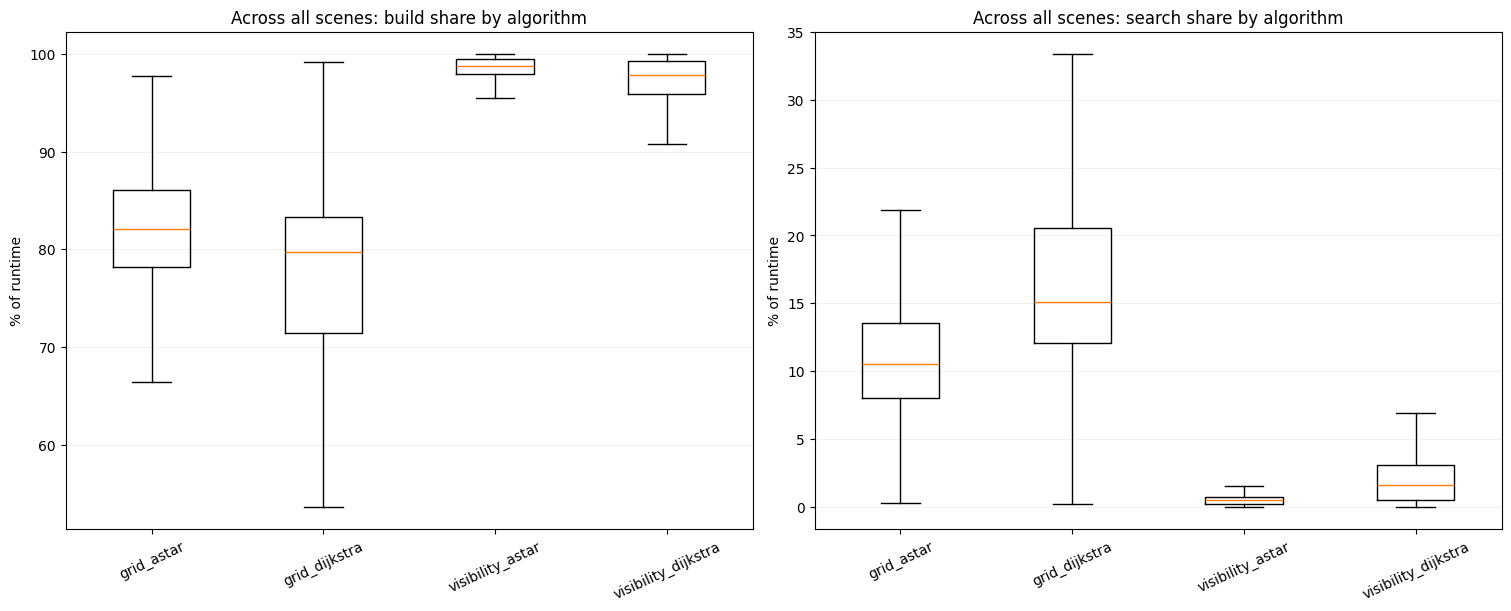

In [120]:
scene_build_search_boxplot_path = OUTPUT_DIR / f'{GRAPH_TIMING_PREFIX}_simple_scene_algorithm_boxplots.png'
timing_algorithms = sorted(simple_timing_df['algorithm_id'].dropna().unique())

fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
build_data = [
    simple_timing_df.loc[simple_timing_df['algorithm_id'] == algorithm, 'build_percent'].dropna()
    for algorithm in timing_algorithms
]
search_data = [
    simple_timing_df.loc[simple_timing_df['algorithm_id'] == algorithm, 'search_percent'].dropna()
    for algorithm in timing_algorithms
]
axes[0].boxplot(build_data, labels=timing_algorithms, showfliers=False)
axes[0].set_title('Across all scenes: build share by algorithm')
axes[0].set_ylabel('% of runtime')
axes[0].tick_params(axis='x', rotation=25)
axes[0].grid(axis='y', alpha=0.25, linewidth=0.5)

axes[1].boxplot(search_data, labels=timing_algorithms, showfliers=False)
axes[1].set_title('Across all scenes: search share by algorithm')
axes[1].set_ylabel('% of runtime')
axes[1].tick_params(axis='x', rotation=25)
axes[1].grid(axis='y', alpha=0.25, linewidth=0.5)

fig.savefig(scene_build_search_boxplot_path, dpi=180, bbox_inches='tight')
print(f'Saved: {scene_build_search_boxplot_path}')
plt.show()


На текущем прогоне медианная доля `build time` по сценам составляет около `90.3%` общего runtime, а для `1540` сцен она превышает `95%`. Это означает, что для графовых методов ключевой вычислительный узкий участок находится не в поиске как таковом, а прежде всего в предварительном построении графа.
